# Loading the Dataset

In [ ]:
!pip install scikit-learn pandas numpy shap fairlearn lime xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 18.9 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5dce55d1355054bca52cca91e6d4aae44f88a3964028ecc446a95890234ee077
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
!pip install --upgrade scikit-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
!wget https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv -P /usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/

--2025-10-07 03:25:53--  https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2546489 (2.4M) [text/plain]
Saving to: ‘/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv’

compas-scores-two-y 100%[===================>]   2.43M  --.-KB/s    in 0.09s   

2025-10-07 03:25:54 (26.2 MB/s) - ‘/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv’ saved [2546489/2546489]



In [ ]:
ls -lh /usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/

total 2.5M
-rw-r--r-- 1 root root 2.5M Oct  7 03:25 compas-scores-two-years.csv


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [ ]:
# Define the file path
file_path = "/usr/local/lib/python3.11/dist-packages/aif360/data/raw/compas/compas-scores-two-years.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [ ]:
df.shape

(7214, 53)

In [ ]:
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [ ]:
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


# Preprocessing

In [ ]:
df["two_year_recid"].value_counts()
# recid rate 45.1%

,count
two_year_recid,
0,3963
1,3251


In [ ]:
df["is_recid"].value_counts()

,count
is_recid,
0,3743
1,3471


In [ ]:
(df['two_year_recid']==df['is_recid']).value_counts()

,count
True,6994
False,220


### **Identifiers & Personal Information:**
1. **'id'** – Unique identifier for each individual in the dataset.  
2. **'name'** – Full name of the individual.  
3. **'first'** – First name of the individual.  
4. **'last'** – Last name of the individual.  
5. **'dob'** – Date of birth.  
6. **'sex'** – Gender of the individual (Male/Female).  
7. **'race'** – Ethnicity of the individual (e.g., African-American, Caucasian, etc.).  

In [ ]:
df = pd.get_dummies(df, columns=['race'], drop_first=False, dtype=int)

In [ ]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=int)

In [ ]:
columns_to_drop = ['id','name','first','last','dob']

### **Demographic & Age Information:**
8. **'age'** – Age of the individual at the time of assessment.  
9. **'age_cat'** – Categorized age groups (e.g., 18-25, 26-45, 46+).  

In [ ]:
df['age_cat'].value_counts()

,count
age_cat,
25 - 45,4109
Greater than 45,1576
Less than 25,1529


In [ ]:
# Define age bins and labels
bins = [18, 25, 35, 45, float('inf')]  # 46+ uses infinity
labels = ['18-25', '26-35', '36-45', '46+']

# Create categorical age groups
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

In [ ]:
df['age_group'].value_counts()

,count
age_group,
26-35,2581
18-25,1858
46+,1463
36-45,1309


In [ ]:
# Convert to one-hot encoding with prefix "age_"
df = pd.get_dummies(df, columns=['age_group'], prefix='age', dtype=int)

In [ ]:
df

,id,name,first,last,compas_screening_date,dob,age,age_cat,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,sex_Male,age_18-25,age_26-35,age_36-45,age_46+
0,1,miguel hernandez,miguel,hernandez,2013-08-14,1947-04-18,69,Greater than 45,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0,0,0,0,0,0,1,1,0,0,0,1
1,3,kevon dixon,kevon,dixon,2013-01-27,1982-01-22,34,25 - 45,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1,1,0,0,0,0,0,1,0,1,0,0
2,4,ed philo,ed,philo,2013-04-14,1991-05-14,24,Less than 25,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1,1,0,0,0,0,0,1,1,0,0,0
3,5,marcu brown,marcu,brown,2013-01-13,1993-01-21,23,Less than 25,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0,1,0,0,0,0,0,1,1,0,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,1973-01-22,43,25 - 45,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0,0,0,0,0,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,1992-07-17,23,Less than 25,0,7,0,0,0,-1.0,2013-11-22 05:18:27,2013-11-24 02:59:20,13016249CF10A,2013-11-22,NaN,1.0,F,Deliver Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,7,Medium,2013-11-23,Risk of Violence,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0,1,0,0,0,0,0,1,1,0,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,1993-03-25,23,Less than 25,0,3,0,0,0,-1.0,2014-01-31 07:13:54,2014-02-02 04:03:52,14001422CF10A,2014-01-31,NaN,1.0,F,Leaving the Scene of Accident,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,3,Low,2014-02-01,Risk of Violence,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0,1,0,0,0,0,0,1,1,0,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,1958-10-01,57,Greater than 45,0,1,0,0,0,-1.0,2014-01-13 05:48:01,2014-01-14 07:49:46,14000581CF10A,2014-01-13,NaN,1.0,F,Aggravated Battery / Pregnant,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-01-14,Risk of Violence,1,Low,2014-01-14,2014-01-

In [ ]:
columns_to_drop += ['age', 'age_cat']

### **Criminal History & Prior Records:**
10. **'juv_fel_count'** – Number of juvenile felony convictions.  
11. **'juv_misd_count'** – Number of juvenile misdemeanor convictions.  
12. **'juv_other_count'** – Number of other juvenile offenses.  
13. **'priors_count'** – Total number of prior adult convictions.  

In [ ]:
# columns_to_drop += ['juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']

### **Current Case Information:**
14. **'compas_screening_date'** – Date when the COMPAS risk assessment was conducted.  
15. **'c_case_number'** – Unique identifier for the individual's criminal case.  
16. **'c_offense_date'** – Date of the current offense.  
17. **'c_arrest_date'** – Date of the arrest for the current charge.  
18. **'c_charge_degree'** – Severity of the current charge (M = Misdemeanor, F = Felony).  
19. **'c_charge_desc'** – Description of the current charge (e.g., 'Grand Theft', 'Drug Possession').  
20. **'c_days_from_compas'** – Number of days between COMPAS assessment and the current case.  

In [ ]:
columns_to_drop += ['compas_screening_date','c_arrest_date','c_days_from_compas', 'c_case_number','c_offense_date', 'c_charge_desc']

In [ ]:
df['c_charge_desc'].value_counts()

,count
c_charge_desc,
Battery,1156
arrest case no charge,1137
Possession of Cocaine,474
Grand Theft in the 3rd Degree,425
Driving While License Revoked,200
...,...
Poss Pyrrolidinobutiophenone,1
Conspiracy Dealing Stolen Prop,1
Felony DUI - Enhanced,1


### Was testing to see if we could one hot encode c_charge_desc. Conclusion: Too unpredictable as a feature to predict recidivism. c_charge_degree is a good enough feature to keep


In [ ]:
# # Count total occurrences of each charge type
# charge_counts = df['c_charge_desc'].value_counts()

# # Filter out charge descriptions with fewer than 10 total cases
# valid_charges = charge_counts[charge_counts >= 10].index
# df_filtered = df[df['c_charge_desc'].isin(valid_charges)]

# # Recalculate total and recidivism cases for the filtered data
# charge_counts_filtered = df_filtered.groupby('c_charge_desc')['two_year_recid'].count()
# recid_counts_filtered = df_filtered.groupby('c_charge_desc')['two_year_recid'].sum()

# # Calculate recidivism percentage
# recid_percentage_filtered = (recid_counts_filtered / charge_counts_filtered) * 100

# # Get top 10 charge types with the highest recidivism percentage
# top_10_recid_filtered = recid_percentage_filtered.nlargest(10)

# # Display the result
# print(top_10_recid_filtered)

In [ ]:
# # Get top 30 most common charge descriptions
# top_30 = df['c_charge_desc'].value_counts().nlargest(30).index

# # Create binary columns with "c_charge_" prefix
# for charge in top_30:
#     df[f'c_charge_{charge}'] = (df['c_charge_desc'] == charge).astype(int)

# # Create "Other" column
# df['c_charge_Other'] = (~df['c_charge_desc'].isin(top_30)).astype(int)

# # Drop the original column
# df = df.drop(columns=['c_charge_desc'])

In [ ]:
df.groupby('two_year_recid')['c_charge_degree'].value_counts()

two_year_recid  c_charge_degree
0               F                  2384
                M                  1579
1               F                  2282
                M                   969
Name: count, dtype: int64

In [ ]:
df = pd.get_dummies(df, columns=['c_charge_degree'], drop_first=True, dtype=int)

### **Jail Custody Information:**
21. **'c_jail_in'** – Date the individual was jailed for the current offense.  
22. **'c_jail_out'** – Date the individual was released from jail for the current offense.

In [ ]:
# df = df.dropna(subset=['c_jail_in', 'c_jail_out'])

In [ ]:
columns_to_drop += ['c_jail_in','c_jail_out']

### **Recidivism (Reoffense) Information:**
23. **'is_recid'** – 1 if the individual reoffended, 0 otherwise.  
24. **'two_year_recid'** – 1 if the individual reoffended within two years, 0 otherwise.  


In [ ]:
# columns_to_drop += ['is_recid']
# columns_to_drop += ['two_year_recid']

### **Reoffense Case Details:**
25. **'r_case_number'** – Case number for the recidivism offense.  
26. **'r_offense_date'** – Date of the reoffense.  
27. **'r_arrest_date'** – Date of arrest for the reoffense.  
28. **'r_days_from_arrest'** – Days between the original offense and the reoffense.  
29. **'r_charge_degree'** – Severity of the reoffense (M = Misdemeanor, F = Felony).  
30. **'r_charge_desc'** – Description of the reoffense charge.  
31. **'r_jail_in'** – Jail entry date for the reoffense.  
32. **'r_jail_out'** – Jail exit date for the reoffense.  

In [ ]:
columns_to_drop += ['r_case_number', 'r_offense_date', 'r_days_from_arrest', 'r_charge_degree', 'r_charge_desc', 'r_jail_in', 'r_jail_out']

### **Violent Recidivism Information:**
33. **'violent_recid'** – Number of times the individual has committed a violent reoffense.  
34. **'is_violent_recid'** – 1 if the individual committed a violent reoffense, 0 otherwise.  
35. **'vr_case_number'** – Case number for violent recidivism.  
36. **'vr_offense_date'** – Date of the violent reoffense.  
37. **'vr_charge_degree'** – Severity of the violent reoffense (M = Misdemeanor, F = Felony).  
38. **'vr_charge_desc'** – Description of the violent reoffense charge.  

In [ ]:
df['is_violent_recid'].value_counts()

,count
is_violent_recid,
0,6395
1,819


In [ ]:
df['vr_charge_degree'].value_counts()

,count
vr_charge_degree,
(M1),344
(F3),228
(F2),162
(F1),38
(M2),19
(F7),18
(MO3),5
(F6),4
(F5),1


In [ ]:
columns_to_drop += ['violent_recid', 'vr_case_number', 'vr_offense_date', 'vr_charge_degree', 'vr_charge_desc']

### **COMPAS Risk Assessment Scores:**
39. **'type_of_assessment'** – Type of risk assessment (e.g., General Recidivism, Violent Recidivism).  
40. **'decile_score'** – Risk score (1-10) predicting likelihood of recidivism.  
41. **'score_text'** – Categorical risk level based on 'decile_score' (Low, Medium, High).  
42. **'decile_score.1'** – Duplicate of 'decile_score'.  

In [ ]:
columns_to_drop += ['type_of_assessment','decile_score', 'score_text', 'decile_score.1']

### **Violent Recidivism Risk Scores:**
43. **'v_type_of_assessment'** – Type of assessment for violent recidivism.  
44. **'v_decile_score'** – Risk score (1-10) predicting violent reoffense.  
45. **'v_score_text'** – Categorical risk level for violent recidivism (Low, Medium, High).  
46. **'v_screening_date'** – Date of the violent recidivism assessment.  

In [ ]:
columns_to_drop += ['v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date']

### **Additional Features & Redundant Columns:**
47. **'days_b_screening_arrest'** – Days between arrest and COMPAS screening.  
48. **'priors_count.1'** – Duplicate of 'priors_count'.  
49. **'in_custody'** – Date when the person entered custody.  
50. **'out_custody'** – Date when the person left custody.  
51. **'start'** – Beginning of a time-based event (not clearly defined).  
52. **'end'** – End of a time-based event (not clearly defined).  
53. **'event'** – An unspecified event indicator.  


In [ ]:
df.groupby('two_year_recid')['event'].value_counts()

two_year_recid  event
0               0        3817
                1         146
1               1        2616
                0         635
Name: count, dtype: int64

In [ ]:
# df['total_prior_convictions'] = df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count'] + df['priors_count']

In [ ]:
columns_to_drop += ['days_b_screening_arrest', 'priors_count.1','in_custody','out_custody','start','end','event']

In [ ]:
columns_to_drop

['id',
 'name',
 'first',
 'last',
 'dob',
 'age',
 'age_cat',
 'compas_screening_date',
 'c_arrest_date',
 'c_days_from_compas',
 'c_case_number',
 'c_offense_date',
 'c_charge_desc',
 'c_jail_in',
 'c_jail_out',
 'r_case_number',
 'r_offense_date',
 'r_days_from_arrest',
 'r_charge_degree',
 'r_charge_desc',
 'r_jail_in',
 'r_jail_out',
 'violent_recid',
 'vr_case_number',
 'vr_offense_date',
 'vr_charge_degree',
 'vr_charge_desc',
 'type_of_assessment',
 'decile_score',
 'score_text',
 'decile_score.1',
 'v_type_of_assessment',
 'v_decile_score',
 'v_score_text',
 'v_screening_date',
 'days_b_screening_arrest',
 'priors_count.1',
 'in_custody',
 'out_custody',
 'start',
 'end',
 'event']

In [ ]:
df = df.drop(columns=columns_to_drop,axis=1)

In [ ]:
df = df.drop(columns = ['screening_date'])

In [ ]:
df.columns

Index(['juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count',
       'is_recid', 'is_violent_recid', 'two_year_recid',
       'race_African-American', 'race_Asian', 'race_Caucasian',
       'race_Hispanic', 'race_Native American', 'race_Other', 'sex_Male',
       'age_18-25', 'age_26-35', 'age_36-45', 'age_46+', 'c_charge_degree_M'],
      dtype='object')

In [ ]:
df.head()

,juv_fel_count,juv_misd_count,juv_other_count,priors_count,is_recid,is_violent_recid,two_year_recid,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,sex_Male,age_18-25,age_26-35,age_36-45,age_46+,c_charge_degree_M
0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0
1,0,0,0,0,1,1,1,1,0,0,0,0,0,1,0,1,0,0,0
2,0,0,1,4,1,0,1,1,0,0,0,0,0,1,1,0,0,0,0
3,0,1,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0
4,0,0,0,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0


In [ ]:
df.shape

(7214, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   juv_fel_count          7214 non-null   int64
 1   juv_misd_count         7214 non-null   int64
 2   juv_other_count        7214 non-null   int64
 3   priors_count           7214 non-null   int64
 4   is_recid               7214 non-null   int64
 5   is_violent_recid       7214 non-null   int64
 6   two_year_recid         7214 non-null   int64
 7   race_African-American  7214 non-null   int64
 8   race_Asian             7214 non-null   int64
 9   race_Caucasian         7214 non-null   int64
 10  race_Hispanic          7214 non-null   int64
 11  race_Native American   7214 non-null   int64
 12  race_Other             7214 non-null   int64
 13  sex_Male               7214 non-null   int64
 14  age_18-25              7214 non-null   int64
 15  age_26-35              7214 non-null  

### Visualizing overlap between features and targets

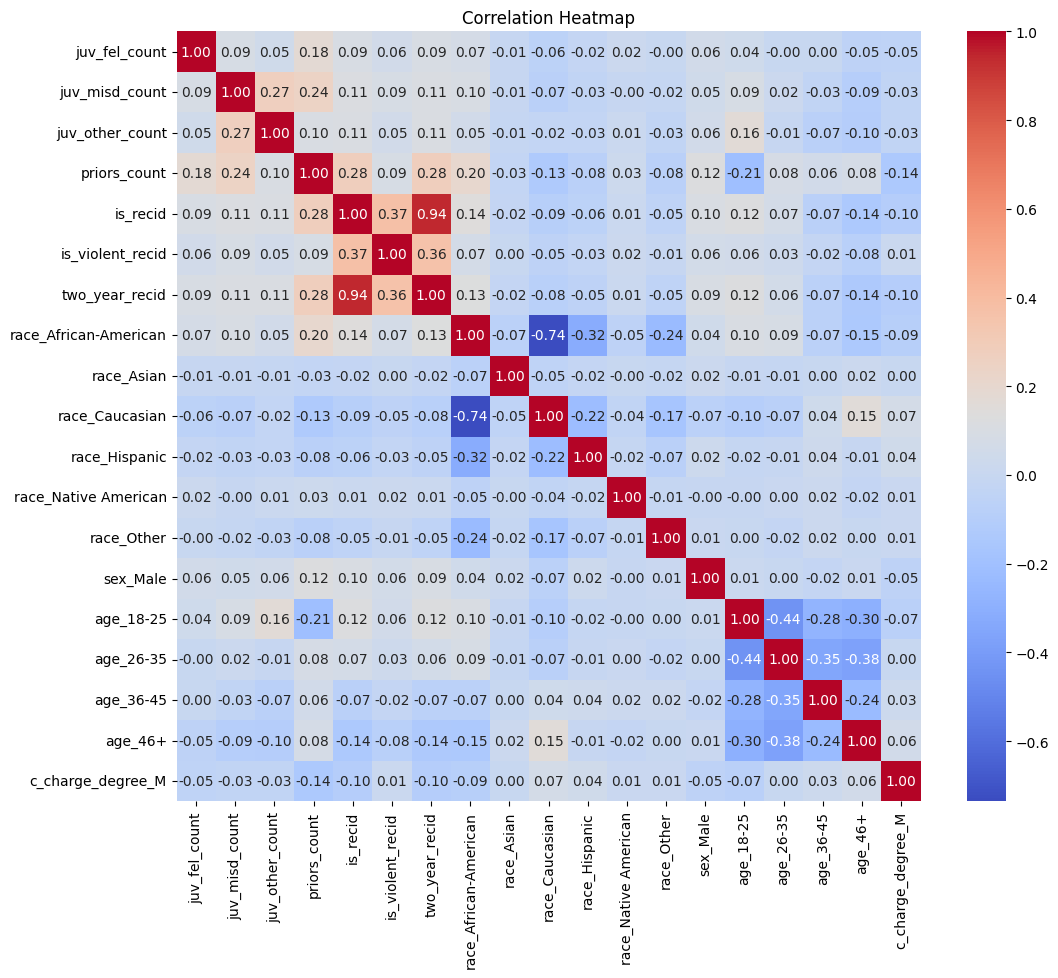

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Baseline models

## Train Test Split

In [ ]:
X = df.drop(columns=['two_year_recid', 'is_recid', 'is_violent_recid'],axis=1)

In [ ]:
y = df['two_year_recid']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5771, 16), (1443, 16), (5771,), (1443,))

### XGB

In [ ]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
model_1 = xgb.XGBClassifier(random_state=42)
model_1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred_1 = model_1.predict(X_test)

Accuracy: 0.6763686763686764
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.78      0.73       823
           1       0.65      0.54      0.59       620

    accuracy                           0.68      1443
   macro avg       0.67      0.66      0.66      1443
weighted avg       0.67      0.68      0.67      1443

Confusion Matrix:
 [[642 181]
 [286 334]]


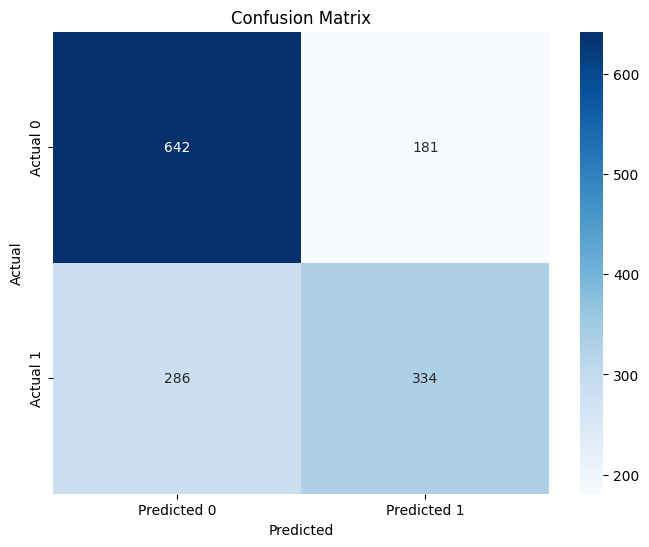

In [ ]:
accuracy_1 = accuracy_score(y_test, y_pred_1)
print(f"Accuracy: {accuracy_1}")

class_report_1 = classification_report(y_test, y_pred_1)
print("Classification Report:\n", class_report_1)

conf_matrix_1 = confusion_matrix(y_test, y_pred_1)
print("Confusion Matrix:\n", conf_matrix_1)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_1, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### SVC

In [ ]:
from sklearn.svm import SVC
model_2 = SVC(random_state=42)
model_2.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
y_pred_2 = model_2.predict(X_test)

Accuracy: 0.6923076923076923
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.81      0.75       823
           1       0.68      0.53      0.60       620

    accuracy                           0.69      1443
   macro avg       0.69      0.67      0.67      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[668 155]
 [289 331]]


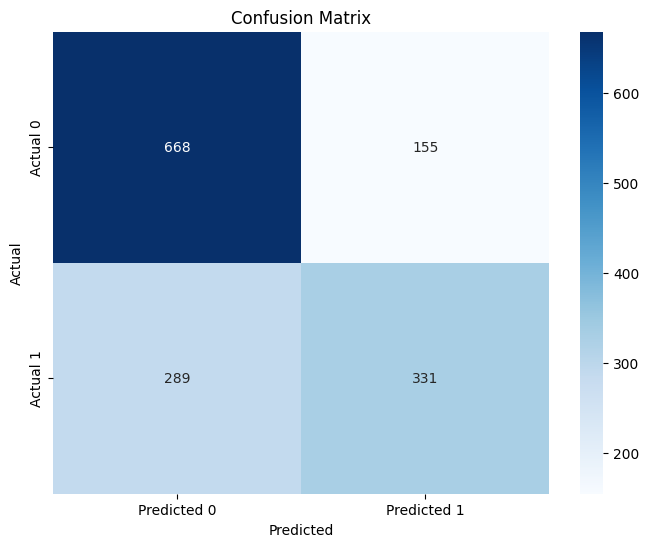

In [ ]:
accuracy_2 = accuracy_score(y_test, y_pred_2)
print(f"Accuracy: {accuracy_2}")

class_report_2 = classification_report(y_test, y_pred_2)
print("Classification Report:\n", class_report_2)

conf_matrix_2 = confusion_matrix(y_test, y_pred_2)
print("Confusion Matrix:\n", conf_matrix_2)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_2, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic

In [ ]:
from sklearn.linear_model import LogisticRegression
model_3 = LogisticRegression(random_state=42)
model_3.fit(X_train, y_train)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


LogisticRegression(random_state=42)

In [ ]:
y_pred_3 = model_3.predict(X_test)

Accuracy: 0.6812196812196812
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.75      0.73       823
           1       0.64      0.59      0.61       620

    accuracy                           0.68      1443
   macro avg       0.67      0.67      0.67      1443
weighted avg       0.68      0.68      0.68      1443

Confusion Matrix:
 [[617 206]
 [254 366]]


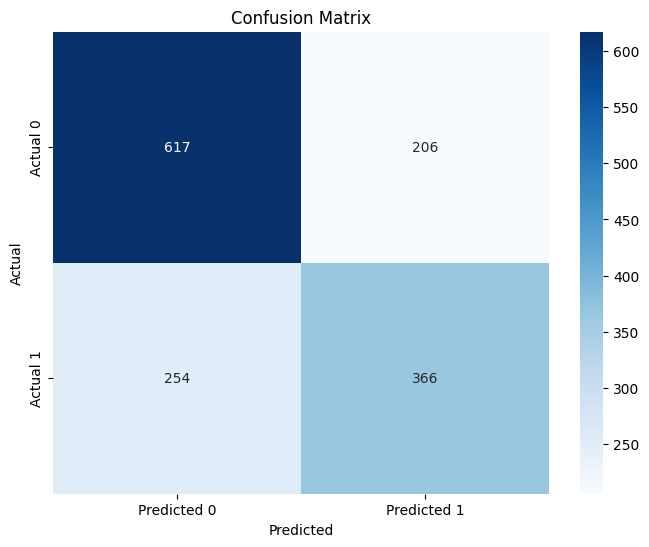

In [ ]:
accuracy_3 = accuracy_score(y_test, y_pred_3)
print(f"Accuracy: {accuracy_3}")

class_report_3 = classification_report(y_test, y_pred_3)
print("Classification Report:\n", class_report_3)

conf_matrix_3 = confusion_matrix(y_test, y_pred_3)
print("Confusion Matrix:\n", conf_matrix_3)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_3, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### GBDT

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_4 = GradientBoostingClassifier(random_state=42)
model_4.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_4 = model_4.predict(X_test)

Accuracy: 0.6909216909216909
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74       823
           1       0.65      0.60      0.63       620

    accuracy                           0.69      1443
   macro avg       0.68      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[625 198]
 [248 372]]


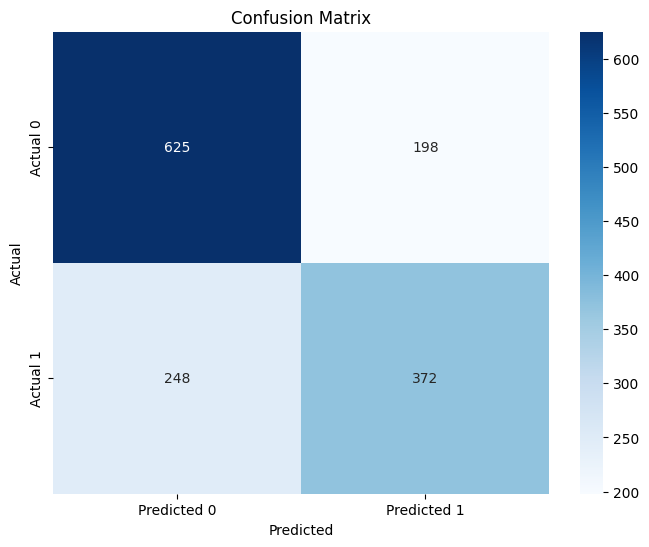

In [ ]:
accuracy_4 = accuracy_score(y_test, y_pred_4)
print(f"Accuracy: {accuracy_4}")

class_report_4 = classification_report(y_test, y_pred_4)
print("Classification Report:\n", class_report_4)

conf_matrix_4 = confusion_matrix(y_test, y_pred_4)
print("Confusion Matrix:\n", conf_matrix_4)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_4, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### RFC

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_5 = RandomForestClassifier(random_state=42)
model_5.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_5 = model_5.predict(X_test)

Accuracy: 0.6507276507276507
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.76      0.71       823
           1       0.61      0.51      0.56       620

    accuracy                           0.65      1443
   macro avg       0.64      0.63      0.63      1443
weighted avg       0.65      0.65      0.65      1443

Confusion Matrix:
 [[623 200]
 [304 316]]


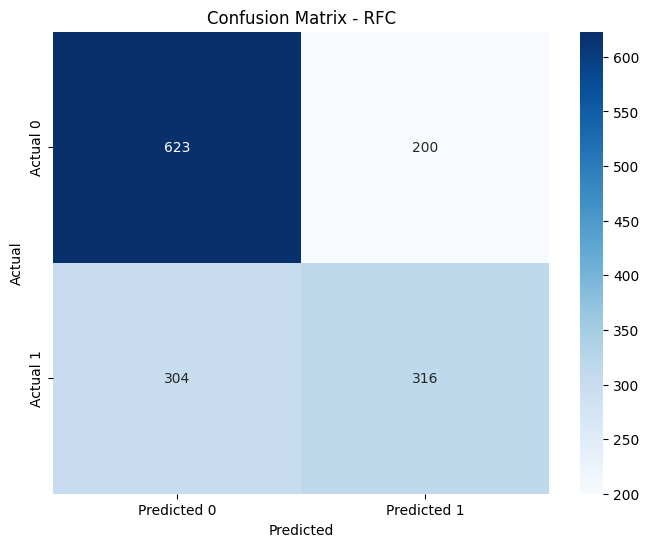

In [ ]:
accuracy_5 = accuracy_score(y_test, y_pred_5)
print(f"Accuracy: {accuracy_5}")

class_report_5 = classification_report(y_test, y_pred_5)
print("Classification Report:\n", class_report_5)

conf_matrix_5 = confusion_matrix(y_test, y_pred_5)
print("Confusion Matrix:\n", conf_matrix_5)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_5, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - RFC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### NN (MLPClassifier)

In [ ]:
from sklearn.neural_network import MLPClassifier

model_6 = MLPClassifier(random_state=42, max_iter=500)
model_6.fit(X_train, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [ ]:
y_pred_6 = model_6.predict(X_test)

Accuracy: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.67      0.55      0.60       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443

Confusion Matrix:
 [[656 167]
 [282 338]]


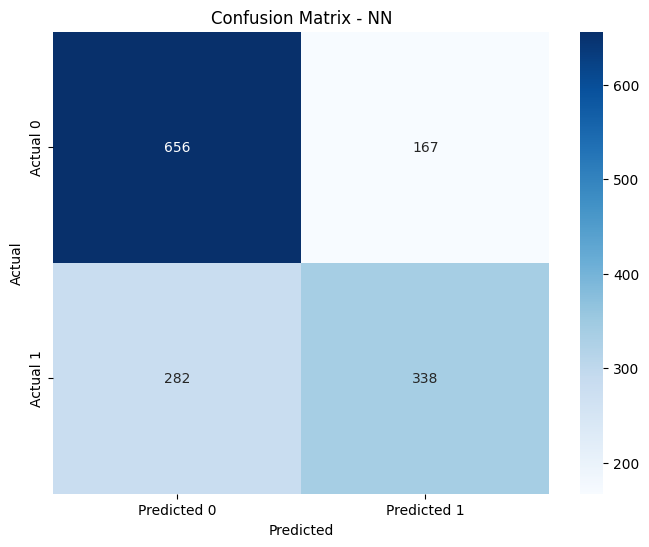

In [ ]:
accuracy_6 = accuracy_score(y_test, y_pred_6)
print(f"Accuracy: {accuracy_6}")

class_report_6 = classification_report(y_test, y_pred_6)
print("Classification Report:\n", class_report_6)

conf_matrix_6 = confusion_matrix(y_test, y_pred_6)
print("Confusion Matrix:\n", conf_matrix_6)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_6, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - NN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# RandomizedSearchCV Hyperparameter Tuning

### XGB

Best XGBoost Parameters: {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Accuracy with Best XGBoost Parameters: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.76      0.74       823
           1       0.65      0.60      0.62       620

    accuracy                           0.69      1443
   macro avg       0.68      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443

Confusion Matrix:
 [[625 198]
 [251 369]]


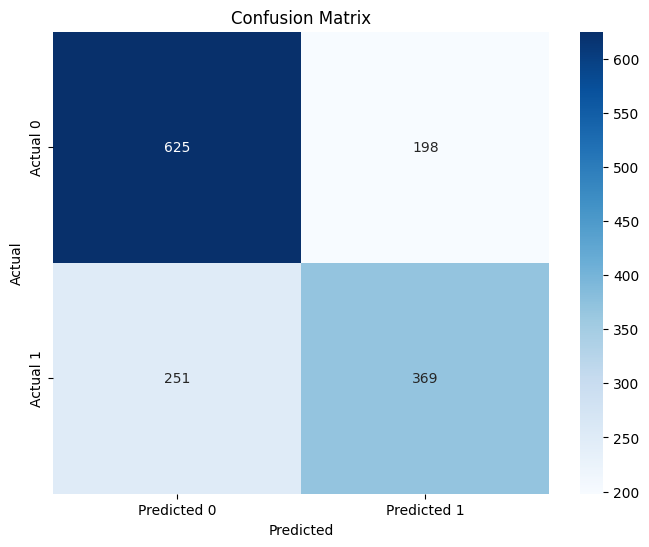

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(model_1, xgb_param_grid, scoring='accuracy', n_iter=100, cv=5, n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy with Best XGBoost Parameters: {accuracy_xgb}")

class_report_xgb = classification_report(y_test, y_pred_xgb)
print("Classification Report:\n", class_report_xgb)

conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", conf_matrix_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### SVC

Best SVM Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 50}
Accuracy with Best SVM Parameters: 0.6909216909216909
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.68      0.54      0.60       620

    accuracy                           0.69      1443
   macro avg       0.69      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443

Confusion Matrix:
 [[662 161]
 [285 335]]


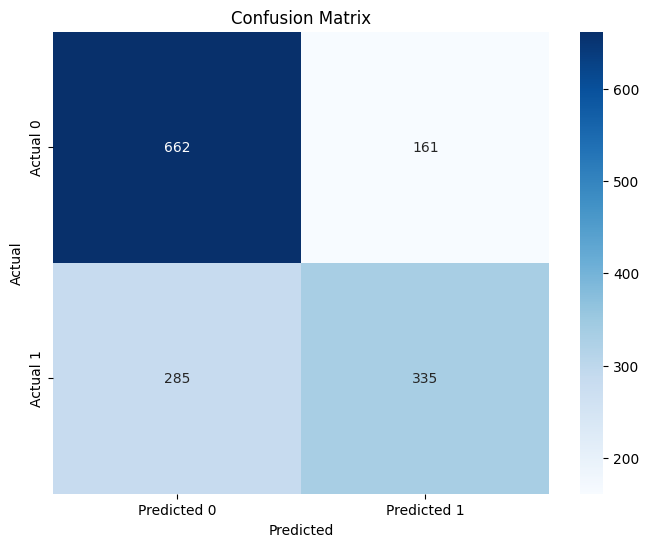

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

svm_param_dist = {
    'C': [0.1, 1, 10, 50],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [0.001, 0.01, 0.1, 1]
}

svm_search = RandomizedSearchCV(model_2, svm_param_dist, n_iter=20, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

svm_search.fit(X_train, y_train)

print("Best SVM Parameters:", svm_search.best_params_)
best_svc = svm_search.best_estimator_
y_pred_svm = best_svc.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy with Best SVM Parameters: {accuracy_svm}")

class_report_svm = classification_report(y_test, y_pred_svm)
print("Classification Report:\n", class_report_svm)

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", conf_matrix_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Logistic

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 5000, 'C': 0.01}
Test Accuracy: 0.6888426888426888
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.67      0.55      0.60       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.69      0.69      0.68      1443



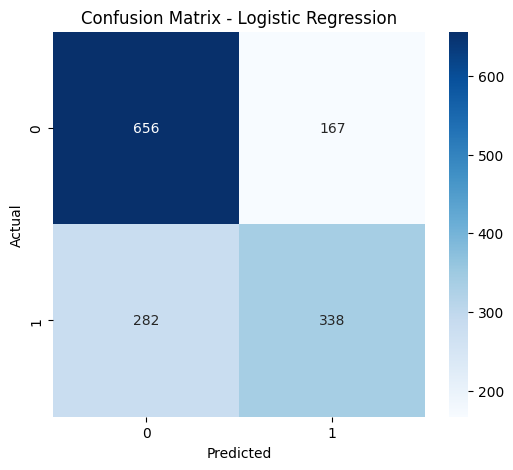

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

logistic_param_dist = {
    'C': np.logspace(-3, 3, 7),
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [3000, 4000, 5000]
}

model = LogisticRegression(random_state=42)

logreg_search = RandomizedSearchCV(model_3, logistic_param_dist, n_iter=40, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

logreg_search.fit(X_train, y_train)

best_logreg = logreg_search.best_estimator_

y_pred_lr = best_logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_lr)

print("Best Parameters:", logreg_search.best_params_)
print(f"Test Accuracy: {accuracy}")
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### GBDT

Best Gradient Boosting Parameters: {'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.01}
Accuracy with Best Gradient Boosting Parameters: 0.6874566874566874
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74       823
           1       0.65      0.58      0.62       620

    accuracy                           0.69      1443
   macro avg       0.68      0.67      0.68      1443
weighted avg       0.68      0.69      0.68      1443

Confusion Matrix:
 [[630 193]
 [258 362]]


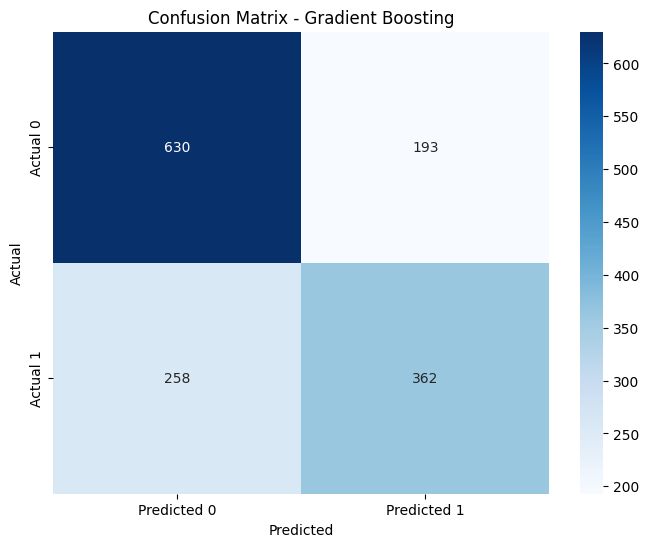

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

gbdt_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.8, 1.0]
}

gbdt_search = RandomizedSearchCV(model_4, gbdt_param_dist, n_iter=100, scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

gbdt_search.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gbdt_search.best_params_)
best_gbdt = gbdt_search.best_estimator_

y_pred_gbdt = best_gbdt.predict(X_test)
accuracy_gbdt = accuracy_score(y_test, y_pred_gbdt)
print(f"Accuracy with Best Gradient Boosting Parameters: {accuracy_gbdt}")

class_report_gbdt = classification_report(y_test, y_pred_gbdt)
print("Classification Report:\n", class_report_gbdt)

conf_matrix_gbdt = confusion_matrix(y_test, y_pred_gbdt)
print("Confusion Matrix:\n", conf_matrix_gbdt)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gbdt, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### RFC

Best Parameters (RFC): {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7}
Test Accuracy (RFC): 0.6826056826056826
Classification Report (RFC):
               precision    recall  f1-score   support

           0       0.70      0.77      0.73       823
           1       0.65      0.57      0.61       620

    accuracy                           0.68      1443
   macro avg       0.68      0.67      0.67      1443
weighted avg       0.68      0.68      0.68      1443



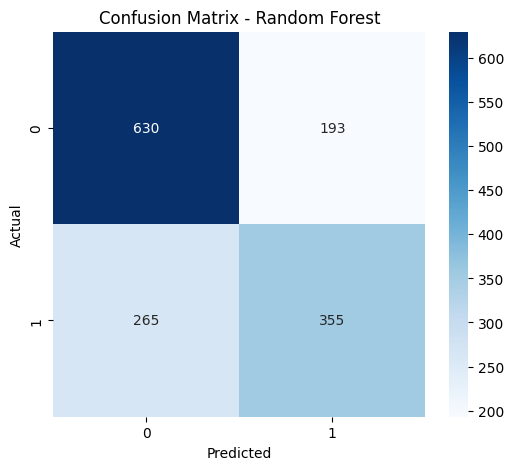

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc_param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_model = RandomForestClassifier(random_state=42)

rfc_search = RandomizedSearchCV(
    rfc_model,
    param_distributions=rfc_param_dist,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
)

rfc_search.fit(X_train, y_train)

best_rfc = rfc_search.best_estimator_
y_pred_rfc = best_rfc.predict(X_test)
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)

print("Best Parameters (RFC):", rfc_search.best_params_)
print(f"Test Accuracy (RFC): {accuracy_rfc}")
print("Classification Report (RFC):\n", classification_report(y_test, y_pred_rfc))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rfc), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### NN (MLPClassifier)

Best Parameters (NN): {'solver': 'adam', 'max_iter': 500, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100,), 'alpha': 0.001, 'activation': 'tanh'}
Test Accuracy (NN): 0.693000693000693
Classification Report (NN):
               precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.68      0.55      0.61       620

    accuracy                           0.69      1443
   macro avg       0.69      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443



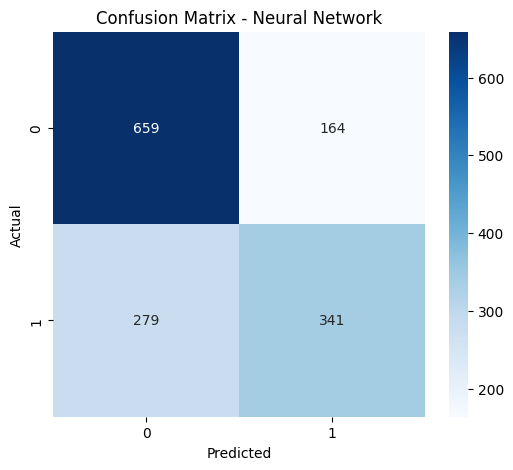

In [ ]:
from sklearn.neural_network import MLPClassifier

nn_param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [500, 1000, 1500]
}

nn_model = MLPClassifier(random_state=42)

nn_search = RandomizedSearchCV(
    nn_model,
    param_distributions=nn_param_dist,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
)

nn_search.fit(X_train, y_train)

best_nn = nn_search.best_estimator_
y_pred_nn = best_nn.predict(X_test)
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print("Best Parameters (NN):", nn_search.best_params_)
print(f"Test Accuracy (NN): {accuracy_nn}")
print("Classification Report (NN):\n", classification_report(y_test, y_pred_nn))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Neural Network")
plt.show()


# SHAP

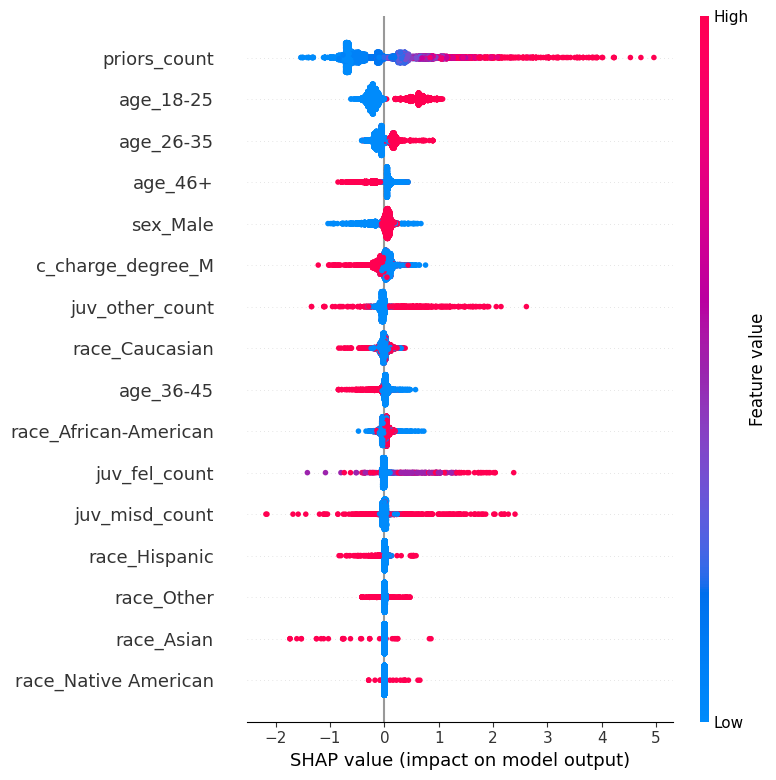

In [ ]:
# Two year XGB
import shap

explainer = shap.TreeExplainer(model_1)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

  0%|          | 0/200 [00:00<?, ?it/s]

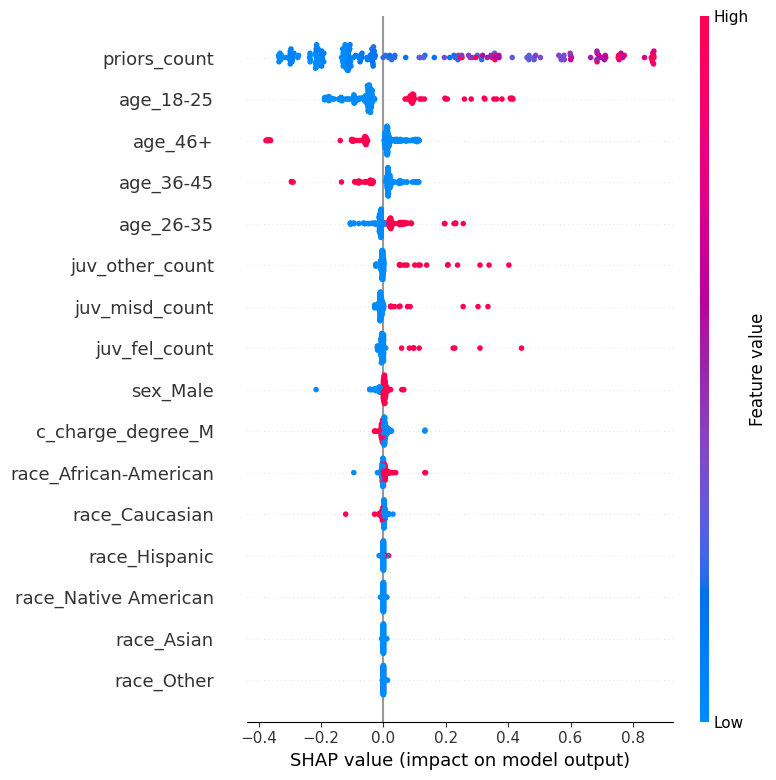

In [ ]:
# Two year recid SVC
import shap

explainer = shap.KernelExplainer(model_2.predict, shap.sample(X_train, 100))
shap_values = explainer.shap_values(X[:200])

shap.summary_plot(shap_values, X[:200])

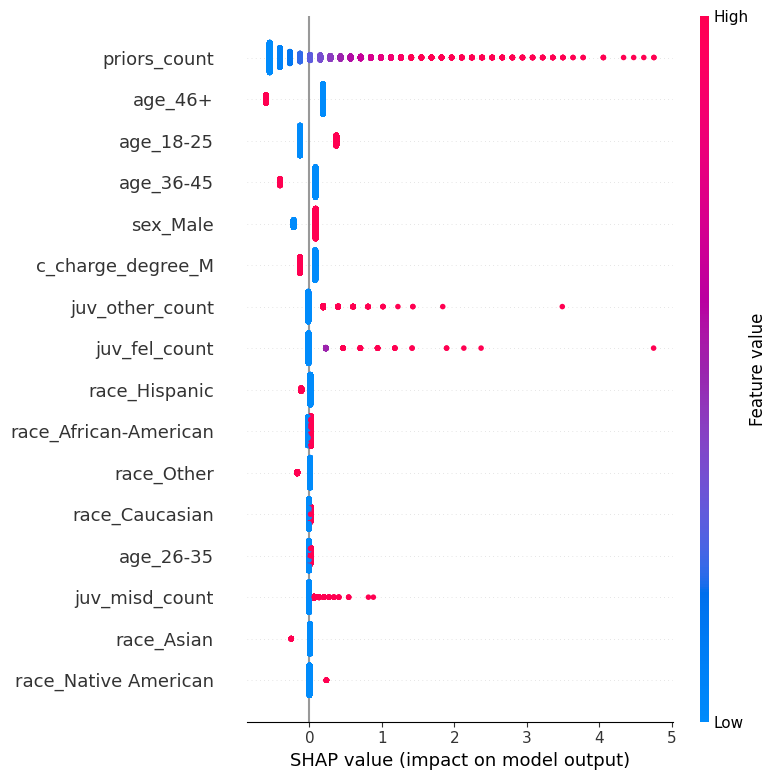

In [ ]:
# Two year recid LogReg
import shap

explainer = shap.LinearExplainer(model_3, X_train)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

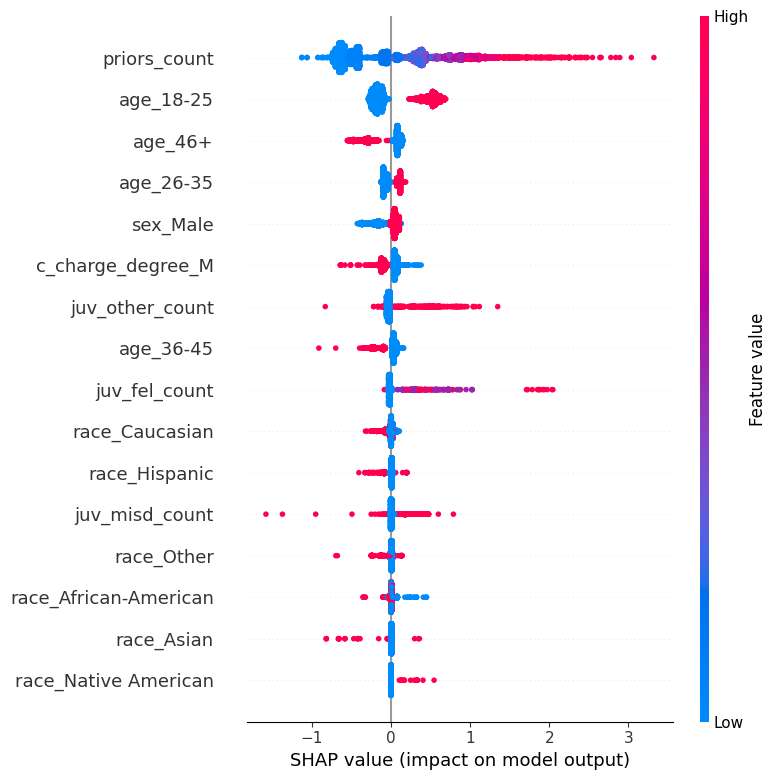

In [ ]:
# Two year GBDT
import shap

explainer = shap.Explainer(model_4)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

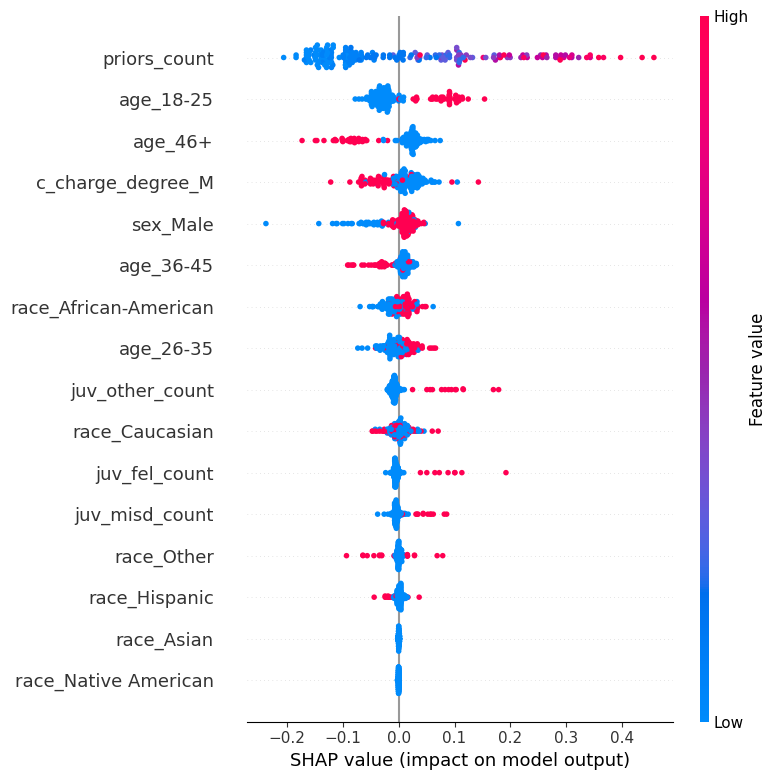

In [ ]:
# Two year RFC
import shap

X_sample = X[:200]

explainer = shap.TreeExplainer(model_5)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values[1], X_sample)


  0%|          | 0/200 [00:00<?, ?it/s]

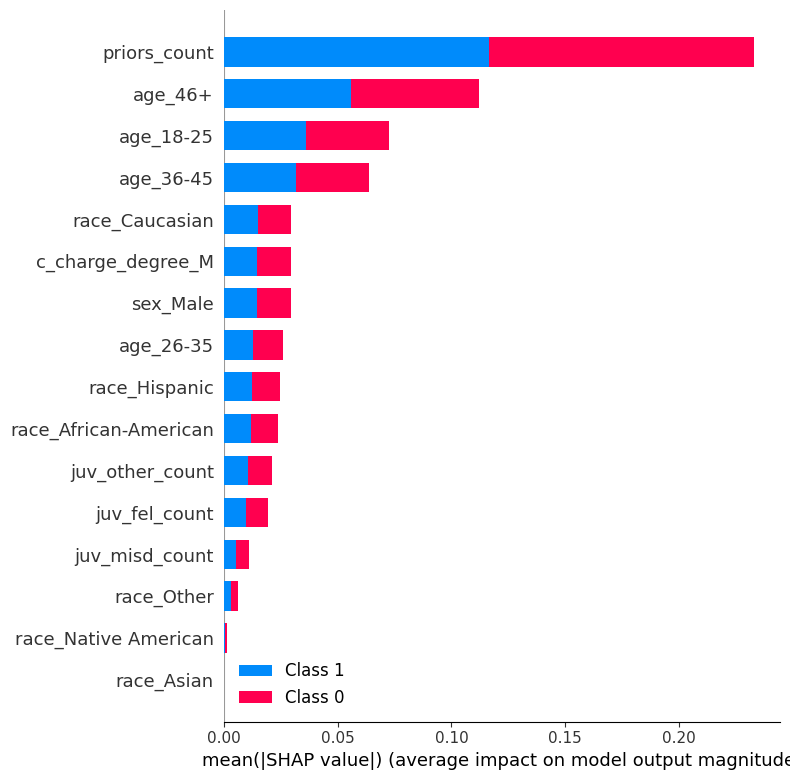

In [ ]:
# Two year nn
import shap

X_sample = shap.sample(X, 200, random_state=42)

explainer = shap.KernelExplainer(model_6.predict_proba, X_sample)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

# Fairlearn

### Sex

In [ ]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

sensitive_attr = X_test['sex_Male']

model_predictions = {
    "XGB": y_pred_xgb,
    "SVC": y_pred_svm,
    "LR": y_pred_lr,
    "GBDT": y_pred_gbdt,
    "RFC": y_pred_rfc,
    "NN": y_pred_nn
}

for model_name, y_pred in model_predictions.items():
    metrics = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_attr)
    print(f"{model_name} Overall Accuracy: {metrics.overall}")
    print(f"{model_name} Accuracy by Group:\n{metrics.by_group}\n")


XGB Overall Accuracy: 0.6888426888426888
XGB Accuracy by Group:
sex_Male
0    0.716000
1    0.683152
Name: accuracy_score, dtype: float64

SVC Overall Accuracy: 0.6909216909216909
SVC Accuracy by Group:
sex_Male
0    0.732000
1    0.682313
Name: accuracy_score, dtype: float64

LR Overall Accuracy: 0.6888426888426888
LR Accuracy by Group:
sex_Male
0    0.716000
1    0.683152
Name: accuracy_score, dtype: float64

GBDT Overall Accuracy: 0.6874566874566874
GBDT Accuracy by Group:
sex_Male
0    0.712000
1    0.682313
Name: accuracy_score, dtype: float64

RFC Overall Accuracy: 0.6826056826056826
RFC Accuracy by Group:
sex_Male
0    0.712000
1    0.676446
Name: accuracy_score, dtype: float64

NN Overall Accuracy: 0.693000693000693
NN Accuracy by Group:
sex_Male
0    0.728000
1    0.685666
Name: accuracy_score, dtype: float64



### Race

In [ ]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

sensitive_attr = X_test['race_African-American']

model_predictions = {
    "XGB": y_pred_xgb,
    "SVC": y_pred_svm,
    "LR": y_pred_lr,
    "GBDT": y_pred_gbdt,
    "RFC": y_pred_rfc,
    "NN": y_pred_nn
}

for model_name, y_pred in model_predictions.items():
    metrics = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_attr)
    print(f"{model_name} Overall Accuracy: {metrics.overall}")
    print(f"{model_name} Accuracy by Group:\n{metrics.by_group}\n")


XGB Overall Accuracy: 0.6888426888426888
XGB Accuracy by Group:
race_African-American
0    0.685393
1    0.692202
Name: accuracy_score, dtype: float64

SVC Overall Accuracy: 0.6909216909216909
SVC Accuracy by Group:
race_African-American
0    0.692416
1    0.689466
Name: accuracy_score, dtype: float64

LR Overall Accuracy: 0.6888426888426888
LR Accuracy by Group:
race_African-American
0    0.692416
1    0.685363
Name: accuracy_score, dtype: float64

GBDT Overall Accuracy: 0.6874566874566874
GBDT Accuracy by Group:
race_African-American
0    0.686798
1    0.688098
Name: accuracy_score, dtype: float64

RFC Overall Accuracy: 0.6826056826056826
RFC Accuracy by Group:
race_African-American
0    0.681180
1    0.683995
Name: accuracy_score, dtype: float64

NN Overall Accuracy: 0.693000693000693
NN Accuracy by Group:
race_African-American
0    0.693820
1    0.692202
Name: accuracy_score, dtype: float64



# LIME (Only useful for explaining individual row predictions)

In [ ]:
import lime
import lime.lime_tabular

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    class_names=['No', 'Yes'],
    mode='classification'
)

# Explain an instance (e.g., first row)
exp = explainer.explain_instance(X.iloc[0].values, model_1.predict_proba)
exp.show_in_notebook()

# In processing and post processing

In [ ]:
!pip install scikit-posthocs aif360 xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 5.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from aif360.metrics import ClassificationMetric
from aif360.algorithms.postprocessing import RejectOptionClassification, CalibratedEqOddsPostprocessing, EqOddsPostprocessing
from aif360.algorithms.inprocessing import AdversarialDebiasing
import tensorflow as tf
from aif360.datasets import BinaryLabelDataset
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

pip install 'aif360[inFairness]'


In [ ]:
tf.compat.v1.disable_eager_execution()

def run_fairness_pipeline(model_name, X, y, protected_attr):
    # ----------------------------
    # Define branches and results storage
    # ----------------------------
    branches = ["Initial", "Adversarial", "ROC", "CEO", "EO", "ROC+Adv", "EO+Adv"]
    results = {m: {"accuracy": [], "di": [], "eod": [], "fpr_diff": []} for m in branches}

    privileged_groups = [{protected_attr: 1}]
    unprivileged_groups = [{protected_attr: 0}]

    # ----------------------------
    # Metrics function
    # ----------------------------
    def compute_metrics(dataset_true, dataset_pred):
        metric = ClassificationMetric(dataset_true, dataset_pred, unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
        accuracy = accuracy_score(dataset_true.labels.ravel(), dataset_pred.labels.ravel())
        di = metric.disparate_impact()
        eod = metric.equal_opportunity_difference()
        fpr_diff = metric.false_positive_rate_difference()
        return accuracy, di, eod, fpr_diff

    # ----------------------------
    # Cross-validation
    # ----------------------------
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        df_train = pd.concat([X_train, y_train], axis=1)
        dataset_train = BinaryLabelDataset(df=df_train, label_names=[y.name], protected_attribute_names=[protected_attr])

        df_test = pd.concat([X_test, y_test], axis=1)
        dataset_test = BinaryLabelDataset(df=df_test, label_names=[y.name], protected_attribute_names=[protected_attr])

        # ----------------------------
        # Train the base model
        # ----------------------------
        if model_name == "xgb":
            import xgboost as xgb
            clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42, subsample=0.6, n_estimators=100, max_depth=3, learning_rate=0.05, colsample_bytree=0.8)
        elif model_name == "svc":
            from sklearn.svm import SVC
            clf = SVC(kernel='rbf', gamma=0.01, C=50, probability=True, random_state=42)
        elif model_name == "lr":
            from sklearn.linear_model import LogisticRegression
            clf = LogisticRegression(solver='liblinear', penalty='l2', max_iter=5000, C=0.01, random_state=42)
        elif model_name == "gbc":
            from sklearn.ensemble import GradientBoostingClassifier
            clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=4, min_samples_split=10, min_samples_leaf=4, subsample=0.6, random_state=42)
        elif model_name == "rfc":
            from sklearn.ensemble import RandomForestClassifier
            clf = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_split=10, min_samples_leaf=4, max_features='log2', random_state=42)
        elif model_name == "nn":
            from sklearn.neural_network import MLPClassifier
            clf = MLPClassifier(solver='adam', max_iter=500, learning_rate='adaptive', hidden_layer_sizes=(100,), alpha=0.001, activation='tanh', random_state=42)
        else:
            raise ValueError("Unsupported model. Choose from xgb, svc, lr, gbc, rfc, nn")

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        df_pred = pd.concat([X_test, pd.Series(y_pred, name=y.name, index=X_test.index)], axis=1)
        dataset_pred = BinaryLabelDataset(df=df_pred, label_names=[y.name], protected_attribute_names=[protected_attr])

        acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_pred)
        for k, v in zip(["accuracy", "di", "eod", "fpr_diff"], [acc, di, eod, fpr_diff]):
            results["Initial"][k].append(v)

        tf.compat.v1.reset_default_graph()
        with tf.compat.v1.Session() as sess:
            adv = AdversarialDebiasing(privileged_groups, unprivileged_groups, scope_name=f"adv_fold_{i}", debias=True, sess=sess)
            adv.fit(dataset_train)
            dataset_adv_pred = adv.predict(dataset_test)

        acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_adv_pred)
        for k, v in zip(["accuracy", "di", "eod", "fpr_diff"], [acc, di, eod, fpr_diff]):
            results["Adversarial"][k].append(v)

        # Post-processing
        dataset_pred_with_probs = dataset_test.copy(deepcopy=True)
        if hasattr(clf, "predict_proba"):
            y_pred_probs = clf.predict_proba(X_test)[:, 1]
            dataset_pred_with_probs.scores = y_pred_probs.reshape(-1, 1)
        else:
            dataset_pred_with_probs.scores = dataset_pred.labels

        roc = RejectOptionClassification(unprivileged_groups, privileged_groups)
        ceo = CalibratedEqOddsPostprocessing(unprivileged_groups, privileged_groups, seed=42)
        eo = EqOddsPostprocessing(unprivileged_groups, privileged_groups)

        datasets_for_post = [dataset_pred, dataset_pred_with_probs, dataset_pred]
        for name, post, pred_data in zip(["ROC", "CEO", "EO"], [roc, ceo, eo], datasets_for_post):
            post.fit(dataset_test, pred_data)
            dataset_post = post.predict(pred_data)
            acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_post)
            for k, v in zip(["accuracy", "di", "eod", "fpr_diff"], [acc, di, eod, fpr_diff]):
                results[name][k].append(v)

        for name, post, pred in zip(["ROC+Adv", "EO+Adv"], [roc, eo], [dataset_adv_pred]*2):
            post.fit(dataset_test, pred)
            dataset_post = post.predict(pred)
            acc, di, eod, fpr_diff = compute_metrics(dataset_test, dataset_post)
            for k, v in zip(["accuracy", "di", "eod", "fpr_diff"], [acc, di, eod, fpr_diff]):
                results[name][k].append(v)

    # ----------------------------
    # Bootstrap confidence intervals (Original non-robust version)
    # ----------------------------
    def bootstrap_ci(data, n_bootstrap=1000, ci=95):
        if not data: return (np.nan, np.nan)
        boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
        lower = np.percentile(boot_means, (100 - ci) / 2)
        upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
        return lower, upper

    print("\n--- Mean Metrics with 95% Confidence Intervals ---")
    for m in branches:
        if not results[m]["accuracy"]: continue
        acc_ci = bootstrap_ci(results[m]["accuracy"])
        di_ci = bootstrap_ci(results[m]["di"])
        eod_ci = bootstrap_ci(results[m]["eod"])
        fpr_ci = bootstrap_ci(results[m]["fpr_diff"])
        print(f"\n{m}:")
        print(f"  Accuracy: {np.mean(results[m]['accuracy']):.3f} (95% CI: {acc_ci[0]:.3f}-{acc_ci[1]:.3f})")
        print(f"  DI:       {np.mean(results[m]['di']):.3f} (95% CI: {di_ci[0]:.3f}-{di_ci[1]:.3f})")
        print(f"  EOD:      {np.mean(results[m]['eod']):.3f} (95% CI: {eod_ci[0]:.3f}-{eod_ci[1]:.3f})")
        print(f"  FPR Diff: {np.mean(results[m]['fpr_diff']):.3f} (95% CI: {fpr_ci[0]:.3f}-{fpr_ci[1]:.3f})")

    # ----------------------------
    # Friedman & Nemenyi Tests (Original non-robust version)
    # ----------------------------
    metrics_to_test = ["accuracy", "di", "eod", "fpr_diff"]
    for metric in metrics_to_test:
        df_for_test = pd.DataFrame({m: results[m][metric] for m in branches})

        friedman_res = friedmanchisquare(*[df_for_test[col] for col in df_for_test.columns])
        print(f"\nFriedman Test ({metric.upper()}):", friedman_res)

        if friedman_res.pvalue < 0.05:
            nemenyi_res = sp.posthoc_nemenyi_friedman(df_for_test)
            alpha = 0.05
            significant_mask = nemenyi_res < alpha

            plt.figure(figsize=(10, 8))
            sns.heatmap(
                significant_mask, annot=nemenyi_res, fmt=".3f", cmap='Reds',
                cbar=True, linewidths=.5, linecolor='black'
            )
            plt.title(f"Nemenyi P-Values Heatmap ({metric.upper()})\nRed = Significant (p<{alpha})", fontsize=14)
            plt.xticks(rotation=45, ha="right")
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

    return results

## For sex


### XGB

epoch 0; iter: 0; batch classifier loss: 0.692177; batch adversarial loss: 0.583161
epoch 1; iter: 0; batch classifier loss: 0.752682; batch adversarial loss: 0.640484
epoch 2; iter: 0; batch classifier loss: 0.646516; batch adversarial loss: 0.640148
epoch 3; iter: 0; batch classifier loss: 0.789776; batch adversarial loss: 0.710467
epoch 4; iter: 0; batch classifier loss: 0.855784; batch adversarial loss: 0.725817
epoch 5; iter: 0; batch classifier loss: 0.933772; batch adversarial loss: 0.758066
epoch 6; iter: 0; batch classifier loss: 0.785829; batch adversarial loss: 0.675315
epoch 7; iter: 0; batch classifier loss: 0.958128; batch adversarial loss: 0.670194
epoch 8; iter: 0; batch classifier loss: 0.920840; batch adversarial loss: 0.627484
epoch 9; iter: 0; batch classifier loss: 0.923381; batch adversarial loss: 0.604687
epoch 10; iter: 0; batch classifier loss: 0.918976; batch adversarial loss: 0.622434
epoch 11; iter: 0; batch classifier loss: 0.819518; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.693150; batch adversarial loss: 0.751908
epoch 1; iter: 0; batch classifier loss: 0.700907; batch adversarial loss: 0.720198
epoch 2; iter: 0; batch classifier loss: 0.691118; batch adversarial loss: 0.717036
epoch 3; iter: 0; batch classifier loss: 0.610168; batch adversarial loss: 0.632894
epoch 4; iter: 0; batch classifier loss: 0.692330; batch adversarial loss: 0.641704
epoch 5; iter: 0; batch classifier loss: 0.629917; batch adversarial loss: 0.600715
epoch 6; iter: 0; batch classifier loss: 0.608600; batch adversarial loss: 0.604164
epoch 7; iter: 0; batch classifier loss: 0.633671; batch adversarial loss: 0.615507
epoch 8; iter: 0; batch classifier loss: 0.613284; batch adversarial loss: 0.556488
epoch 9; iter: 0; batch classifier loss: 0.615137; batch adversarial loss: 0.609947
epoch 10; iter: 0; batch classifier loss: 0.643849; batch adversarial loss: 0.596704
epoch 11; iter: 0; batch classifier loss: 0.608142; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.753063; batch adversarial loss: 0.599414
epoch 1; iter: 0; batch classifier loss: 0.679492; batch adversarial loss: 0.637222
epoch 2; iter: 0; batch classifier loss: 0.629681; batch adversarial loss: 0.647714
epoch 3; iter: 0; batch classifier loss: 0.676571; batch adversarial loss: 0.654698
epoch 4; iter: 0; batch classifier loss: 0.762125; batch adversarial loss: 0.694055
epoch 5; iter: 0; batch classifier loss: 0.935106; batch adversarial loss: 0.683678
epoch 6; iter: 0; batch classifier loss: 0.912636; batch adversarial loss: 0.686208
epoch 7; iter: 0; batch classifier loss: 0.853450; batch adversarial loss: 0.660677
epoch 8; iter: 0; batch classifier loss: 0.814703; batch adversarial loss: 0.628643
epoch 9; iter: 0; batch classifier loss: 0.817992; batch adversarial loss: 0.603044
epoch 10; iter: 0; batch classifier loss: 0.921624; batch adversarial loss: 0.578023
epoch 11; iter: 0; batch classifier loss: 0.814800; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.757010; batch adversarial loss: 0.602354
epoch 1; iter: 0; batch classifier loss: 0.635618; batch adversarial loss: 0.655714
epoch 2; iter: 0; batch classifier loss: 0.691444; batch adversarial loss: 0.652248
epoch 3; iter: 0; batch classifier loss: 0.708830; batch adversarial loss: 0.658024
epoch 4; iter: 0; batch classifier loss: 0.898788; batch adversarial loss: 0.661786
epoch 5; iter: 0; batch classifier loss: 0.853121; batch adversarial loss: 0.697291
epoch 6; iter: 0; batch classifier loss: 0.899150; batch adversarial loss: 0.627620
epoch 7; iter: 0; batch classifier loss: 0.942164; batch adversarial loss: 0.648629
epoch 8; iter: 0; batch classifier loss: 0.906727; batch adversarial loss: 0.625806
epoch 9; iter: 0; batch classifier loss: 0.860503; batch adversarial loss: 0.612284
epoch 10; iter: 0; batch classifier loss: 0.824770; batch adversarial loss: 0.566394
epoch 11; iter: 0; batch classifier loss: 0.814262; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.722306; batch adversarial loss: 0.612850
epoch 1; iter: 0; batch classifier loss: 0.611124; batch adversarial loss: 0.602866
epoch 2; iter: 0; batch classifier loss: 0.599158; batch adversarial loss: 0.602301
epoch 3; iter: 0; batch classifier loss: 0.595539; batch adversarial loss: 0.584665
epoch 4; iter: 0; batch classifier loss: 0.614957; batch adversarial loss: 0.610186
epoch 5; iter: 0; batch classifier loss: 0.643595; batch adversarial loss: 0.644005
epoch 6; iter: 0; batch classifier loss: 0.559516; batch adversarial loss: 0.613861
epoch 7; iter: 0; batch classifier loss: 0.551761; batch adversarial loss: 0.580985
epoch 8; iter: 0; batch classifier loss: 0.668102; batch adversarial loss: 0.603093
epoch 9; iter: 0; batch classifier loss: 0.566958; batch adversarial loss: 0.601840
epoch 10; iter: 0; batch classifier loss: 0.585687; batch adversarial loss: 0.518791
epoch 11; iter: 0; batch classifier loss: 0.584797; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.673 (95% CI: 0.661-0.686)
  DI:       0.514 (95% CI: 0.461-0.584)
  EOD:      -0.205 (95% CI: -0.243--0.154)
  FPR Diff: -0.149 (95% CI: -0.192--0.105)

Adversarial:
  Accuracy: 0.668 (95% CI: 0.658-0.676)
  DI:       1.059 (95% CI: 0.974-1.151)
  EOD:      0.061 (95% CI: 0.023-0.097)
  FPR Diff: 0.053 (95% CI: 0.030-0.076)

ROC:
  Accuracy: 0.673 (95% CI: 0.661-0.688)
  DI:       0.514 (95% CI: 0.460-0.589)
  EOD:      -0.205 (95% CI: -0.243--0.155)
  FPR Diff: -0.149 (95% CI: -0.193--0.100)

CEO:
  Accuracy: 0.667 (95% CI: 0.657-0.680)
  DI:       0.263 (95% CI: 0.115-0.383)
  EOD:      -0.407 (95% CI: -0.509--0.325)
  FPR Diff: -0.207 (95% CI: -0.253--0.159)

EO:
  Accuracy: 0.638 (95% CI: 0.622-0.661)
  DI:       0.903 (95% CI: 0.868-0.934)
  EOD:      -0.004 (95% CI: -0.012-0.005)
  FPR Diff: -0.001 (95% CI: -0.009-0.006)

ROC+Adv:
  Accuracy: 0.672 (95% CI: 0.664-0.680)
  DI:       1.033 (95% CI: 0.971-1.

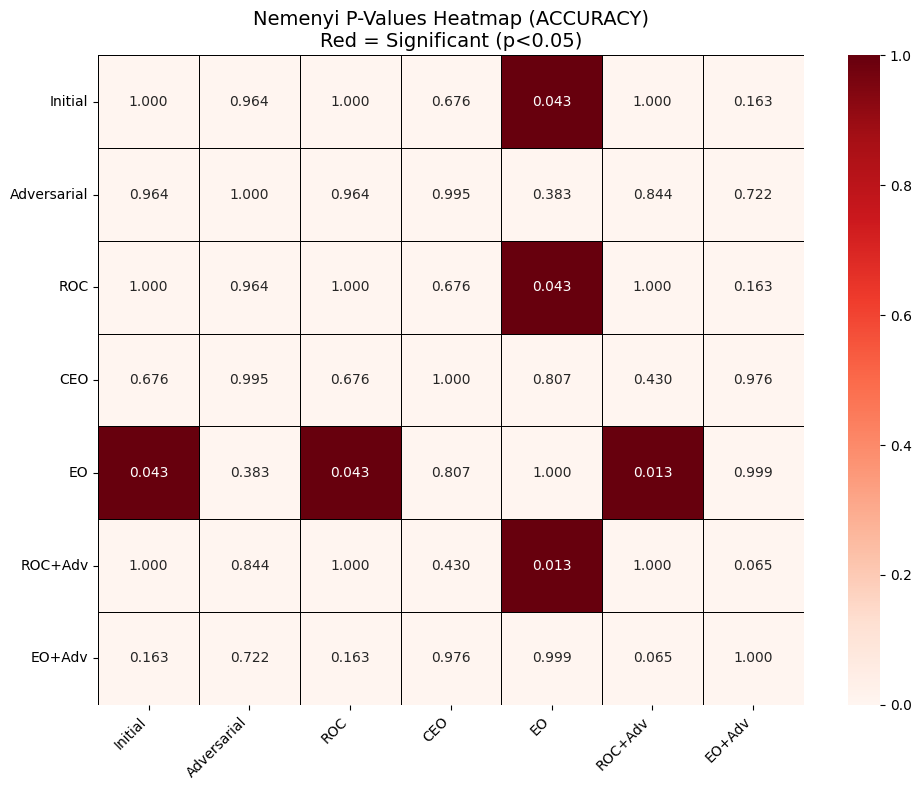


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(29.127272727272732), pvalue=np.float64(5.755386316475225e-05))


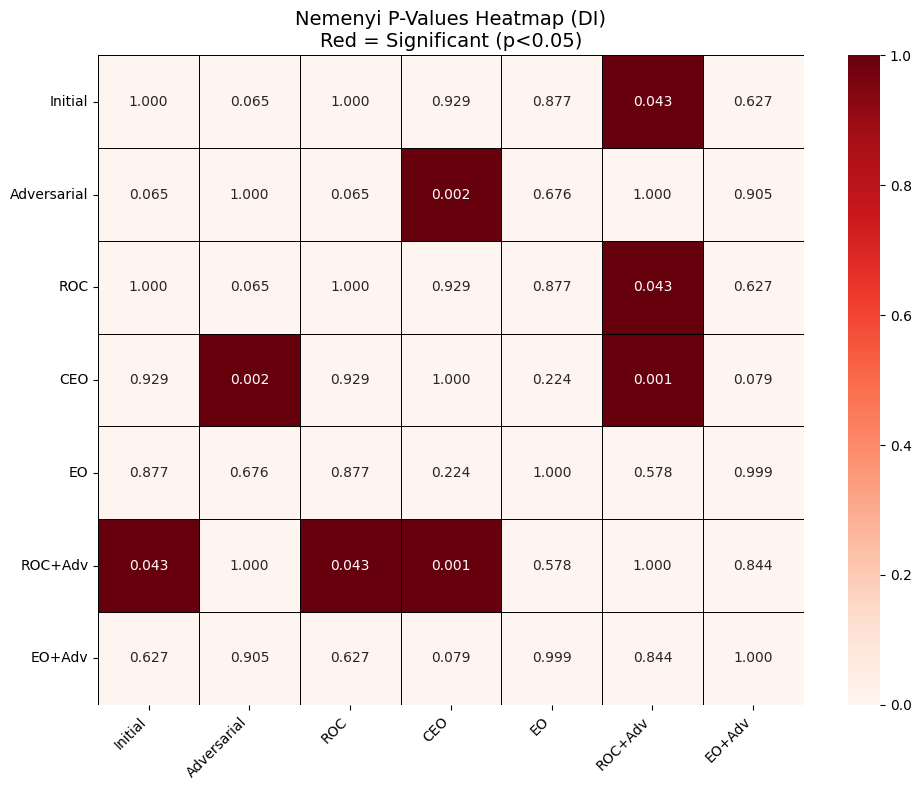


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(28.952727272727273), pvalue=np.float64(6.210297975086575e-05))


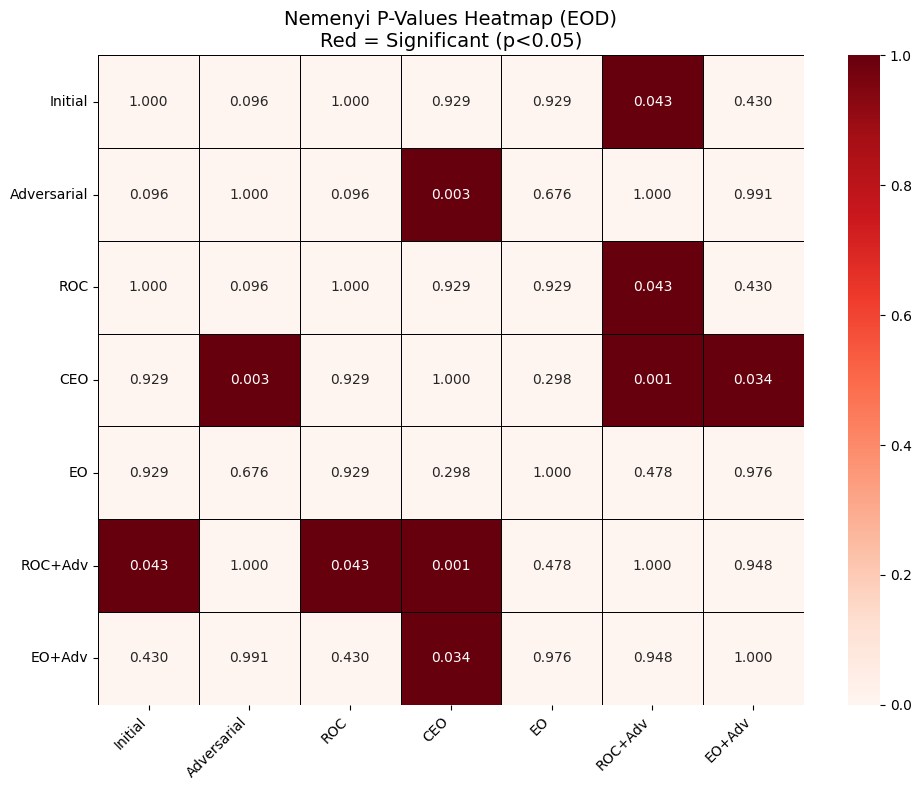


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(29.127272727272732), pvalue=np.float64(5.755386316475225e-05))


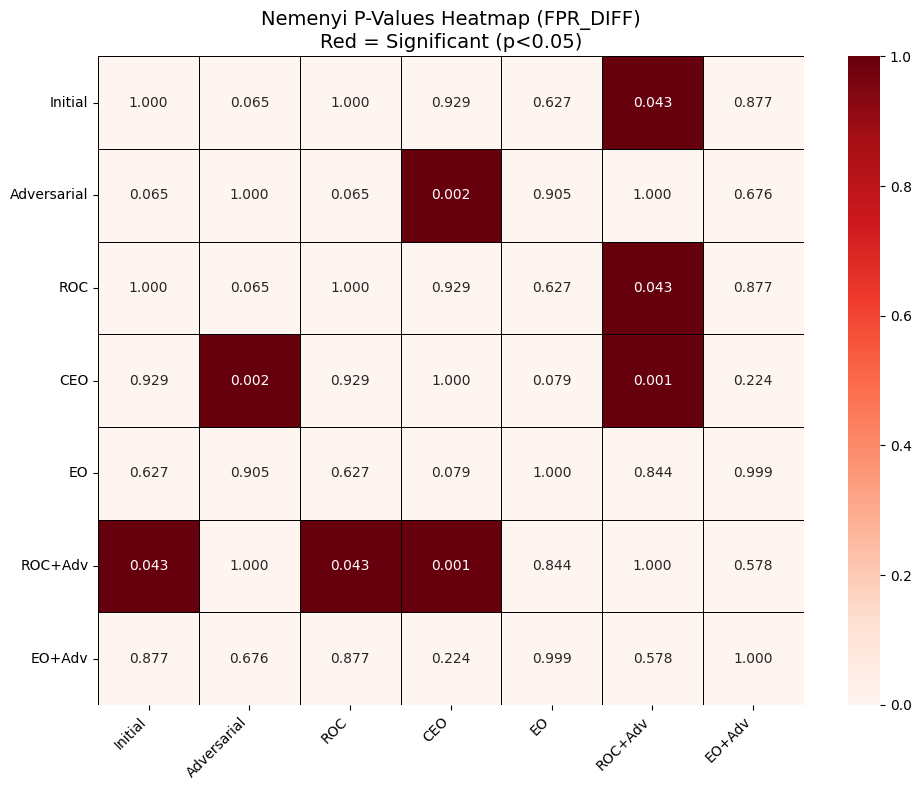

In [ ]:
res_xgb_sex = run_fairness_pipeline("xgb", X, y, "sex_Male")

In [ ]:
res_xgb_sex

{'Initial': {'accuracy': [0.6999306999306999,
   0.6701316701316701,
   0.6548856548856549,
   0.6618156618156619,
   0.6775312066574203],
  'di': [np.float64(0.658917061273617),
   np.float64(0.521505376344086),
   np.float64(0.4464150943396227),
   np.float64(0.46829930319235136),
   np.float64(0.47686510713805996)],
  'eod': [np.float64(-0.112268022294359),
   np.float64(-0.25766080482965625),
   np.float64(-0.2202750665483585),
   np.float64(-0.24613463939306635),
   np.float64(-0.18833833527286087)],
  'fpr_diff': [np.float64(-0.057498036695937726),
   np.float64(-0.1284864507600793),
   np.float64(-0.22436461818395256),
   np.float64(-0.17081260364842454),
   np.float64(-0.1654166666666667)]},
 'Adversarial': {'accuracy': [0.6742896742896742,
   0.6805266805266805,
   0.647955647955648,
   0.6638946638946639,
   0.673370319001387],
  'di': [np.float64(1.0758018027941474),
   np.float64(1.0150956230541819),
   np.float64(1.2213157894736841),
   np.float64(1.0721880792117842),
   n

### SVC

epoch 0; iter: 0; batch classifier loss: 0.747481; batch adversarial loss: 0.801656
epoch 1; iter: 0; batch classifier loss: 0.631718; batch adversarial loss: 0.887494
epoch 2; iter: 0; batch classifier loss: 0.716496; batch adversarial loss: 0.831624
epoch 3; iter: 0; batch classifier loss: 0.684718; batch adversarial loss: 0.769852
epoch 4; iter: 0; batch classifier loss: 0.608889; batch adversarial loss: 0.770925
epoch 5; iter: 0; batch classifier loss: 0.570931; batch adversarial loss: 0.727530
epoch 6; iter: 0; batch classifier loss: 0.621275; batch adversarial loss: 0.704208
epoch 7; iter: 0; batch classifier loss: 0.637249; batch adversarial loss: 0.650868
epoch 8; iter: 0; batch classifier loss: 0.656508; batch adversarial loss: 0.634277
epoch 9; iter: 0; batch classifier loss: 0.585381; batch adversarial loss: 0.633504
epoch 10; iter: 0; batch classifier loss: 0.639050; batch adversarial loss: 0.630054
epoch 11; iter: 0; batch classifier loss: 0.575421; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.693150; batch adversarial loss: 0.751908
epoch 1; iter: 0; batch classifier loss: 0.700907; batch adversarial loss: 0.720198
epoch 2; iter: 0; batch classifier loss: 0.691118; batch adversarial loss: 0.717036
epoch 3; iter: 0; batch classifier loss: 0.610168; batch adversarial loss: 0.632894
epoch 4; iter: 0; batch classifier loss: 0.692330; batch adversarial loss: 0.641704
epoch 5; iter: 0; batch classifier loss: 0.629917; batch adversarial loss: 0.600715
epoch 6; iter: 0; batch classifier loss: 0.608600; batch adversarial loss: 0.604164
epoch 7; iter: 0; batch classifier loss: 0.633671; batch adversarial loss: 0.615507
epoch 8; iter: 0; batch classifier loss: 0.613284; batch adversarial loss: 0.556488
epoch 9; iter: 0; batch classifier loss: 0.615137; batch adversarial loss: 0.609947
epoch 10; iter: 0; batch classifier loss: 0.643849; batch adversarial loss: 0.596704
epoch 11; iter: 0; batch classifier loss: 0.608142; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.753063; batch adversarial loss: 0.599414
epoch 1; iter: 0; batch classifier loss: 0.679492; batch adversarial loss: 0.637222
epoch 2; iter: 0; batch classifier loss: 0.629681; batch adversarial loss: 0.647714
epoch 3; iter: 0; batch classifier loss: 0.676571; batch adversarial loss: 0.654698
epoch 4; iter: 0; batch classifier loss: 0.762125; batch adversarial loss: 0.694055
epoch 5; iter: 0; batch classifier loss: 0.935106; batch adversarial loss: 0.683678
epoch 6; iter: 0; batch classifier loss: 0.912636; batch adversarial loss: 0.686208
epoch 7; iter: 0; batch classifier loss: 0.853450; batch adversarial loss: 0.660677
epoch 8; iter: 0; batch classifier loss: 0.814703; batch adversarial loss: 0.628643
epoch 9; iter: 0; batch classifier loss: 0.817992; batch adversarial loss: 0.603044
epoch 10; iter: 0; batch classifier loss: 0.921624; batch adversarial loss: 0.578023
epoch 11; iter: 0; batch classifier loss: 0.814800; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.757010; batch adversarial loss: 0.602354
epoch 1; iter: 0; batch classifier loss: 0.635618; batch adversarial loss: 0.655714
epoch 2; iter: 0; batch classifier loss: 0.691444; batch adversarial loss: 0.652248
epoch 3; iter: 0; batch classifier loss: 0.708830; batch adversarial loss: 0.658024
epoch 4; iter: 0; batch classifier loss: 0.898788; batch adversarial loss: 0.661786
epoch 5; iter: 0; batch classifier loss: 0.853121; batch adversarial loss: 0.697291
epoch 6; iter: 0; batch classifier loss: 0.899150; batch adversarial loss: 0.627620
epoch 7; iter: 0; batch classifier loss: 0.942164; batch adversarial loss: 0.648629
epoch 8; iter: 0; batch classifier loss: 0.906727; batch adversarial loss: 0.625806
epoch 9; iter: 0; batch classifier loss: 0.860503; batch adversarial loss: 0.612284
epoch 10; iter: 0; batch classifier loss: 0.824770; batch adversarial loss: 0.566394
epoch 11; iter: 0; batch classifier loss: 0.814262; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.722306; batch adversarial loss: 0.612850
epoch 1; iter: 0; batch classifier loss: 0.611124; batch adversarial loss: 0.602866
epoch 2; iter: 0; batch classifier loss: 0.599158; batch adversarial loss: 0.602301
epoch 3; iter: 0; batch classifier loss: 0.595539; batch adversarial loss: 0.584665
epoch 4; iter: 0; batch classifier loss: 0.614957; batch adversarial loss: 0.610186
epoch 5; iter: 0; batch classifier loss: 0.643595; batch adversarial loss: 0.644005
epoch 6; iter: 0; batch classifier loss: 0.559516; batch adversarial loss: 0.613861
epoch 7; iter: 0; batch classifier loss: 0.551761; batch adversarial loss: 0.580985
epoch 8; iter: 0; batch classifier loss: 0.668102; batch adversarial loss: 0.603093
epoch 9; iter: 0; batch classifier loss: 0.566958; batch adversarial loss: 0.601840
epoch 10; iter: 0; batch classifier loss: 0.585687; batch adversarial loss: 0.518791
epoch 11; iter: 0; batch classifier loss: 0.584797; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.670 (95% CI: 0.660-0.682)
  DI:       0.528 (95% CI: 0.486-0.591)
  EOD:      -0.170 (95% CI: -0.222--0.119)
  FPR Diff: -0.122 (95% CI: -0.147--0.094)

Adversarial:
  Accuracy: 0.655 (95% CI: 0.630-0.673)
  DI:       1.538 (95% CI: 0.984-2.508)
  EOD:      0.159 (95% CI: 0.023-0.358)
  FPR Diff: 0.199 (95% CI: 0.030-0.513)

ROC:
  Accuracy: 0.670 (95% CI: 0.660-0.682)
  DI:       0.528 (95% CI: 0.486-0.591)
  EOD:      -0.170 (95% CI: -0.220--0.119)
  FPR Diff: -0.122 (95% CI: -0.150--0.090)

CEO:
  Accuracy: 0.667 (95% CI: 0.660-0.676)
  DI:       0.287 (95% CI: 0.147-0.434)
  EOD:      -0.363 (95% CI: -0.471--0.263)
  FPR Diff: -0.175 (95% CI: -0.214--0.133)

EO:
  Accuracy: 0.642 (95% CI: 0.628-0.657)
  DI:       0.893 (95% CI: 0.860-0.925)
  EOD:      -0.005 (95% CI: -0.018-0.002)
  FPR Diff: -0.001 (95% CI: -0.007-0.008)

ROC+Adv:
  Accuracy: 0.631 (95% CI: 0.552-0.676)
  DI:       1.046 (95% CI: 0.984-1.

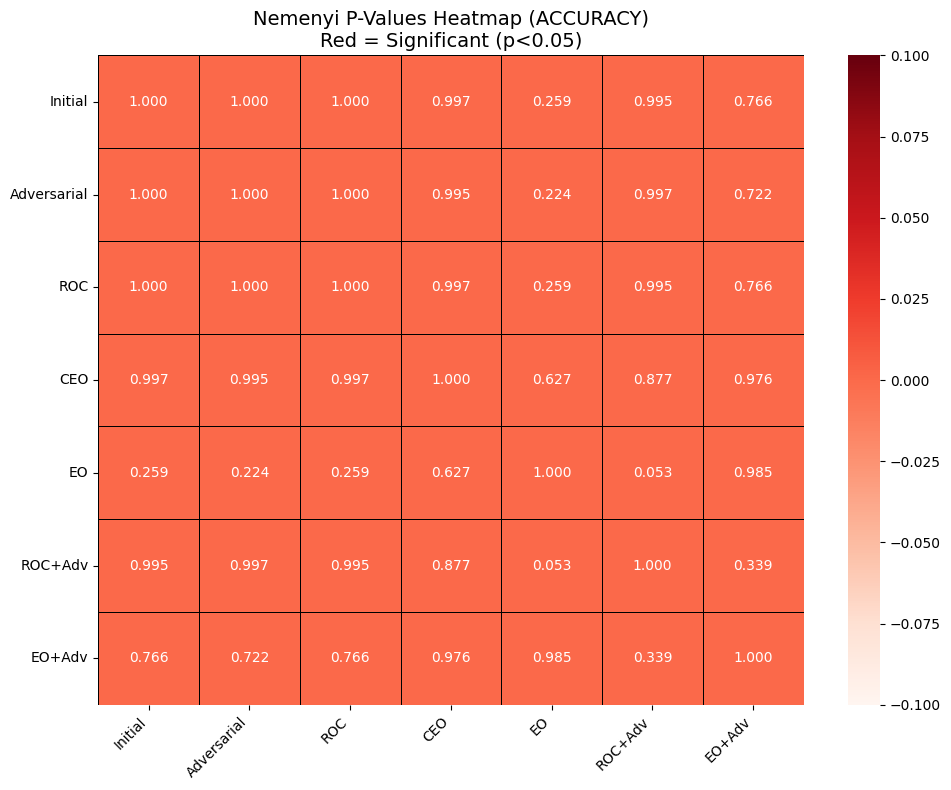


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(28.429090909090917), pvalue=np.float64(7.799404032316512e-05))


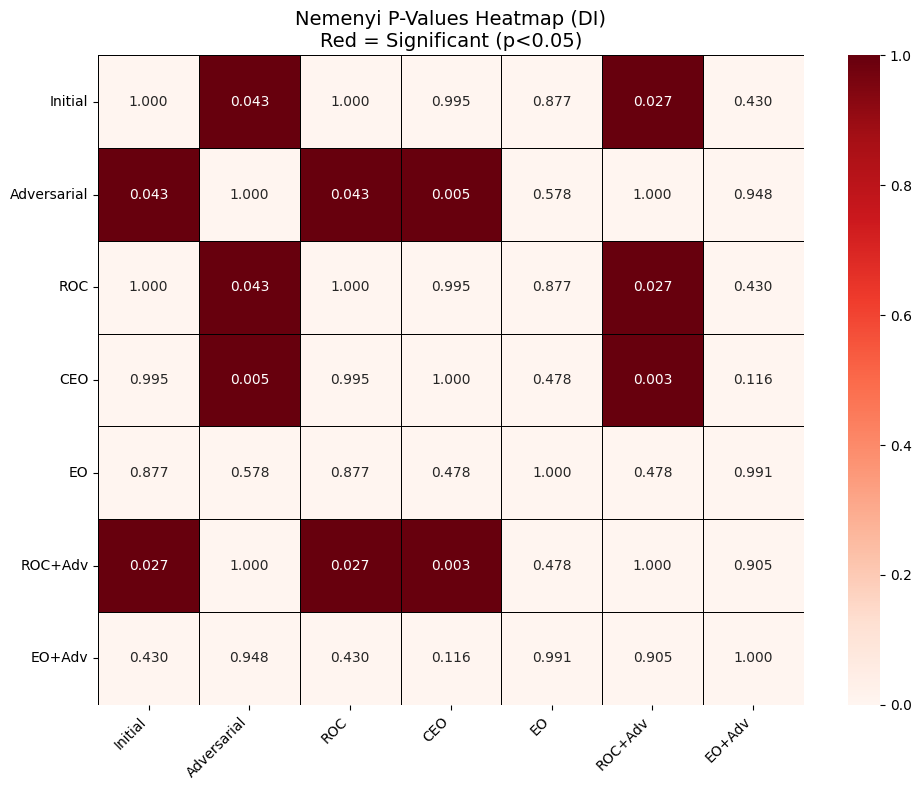


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(26.5090909090909), pvalue=np.float64(0.0001789093001474687))


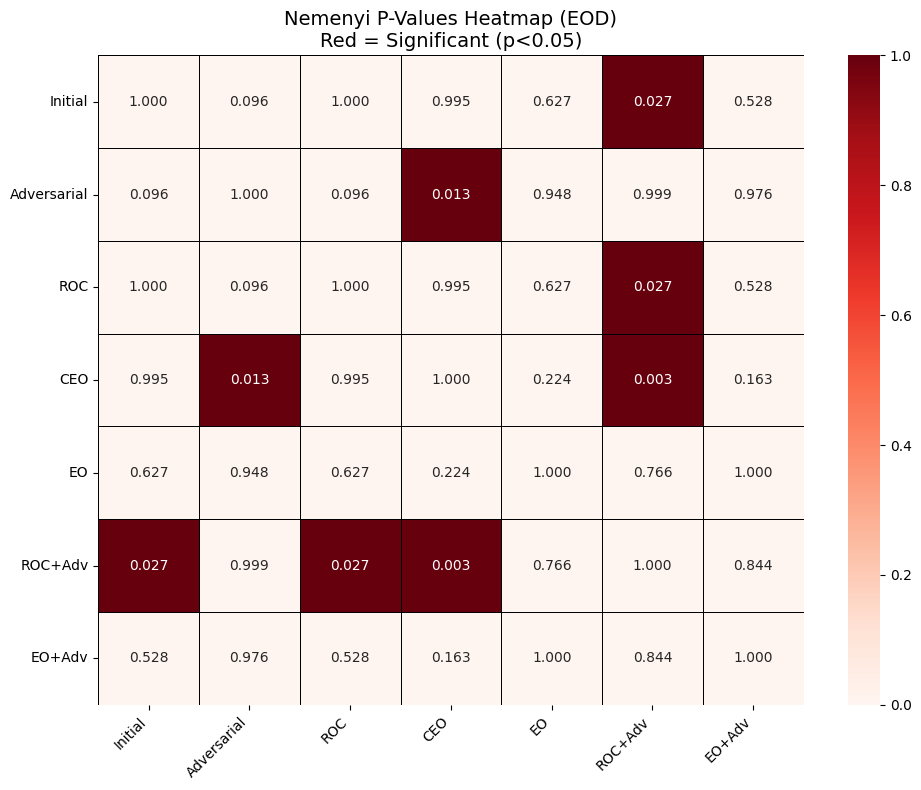


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(28.335766423357665), pvalue=np.float64(8.122132549336719e-05))


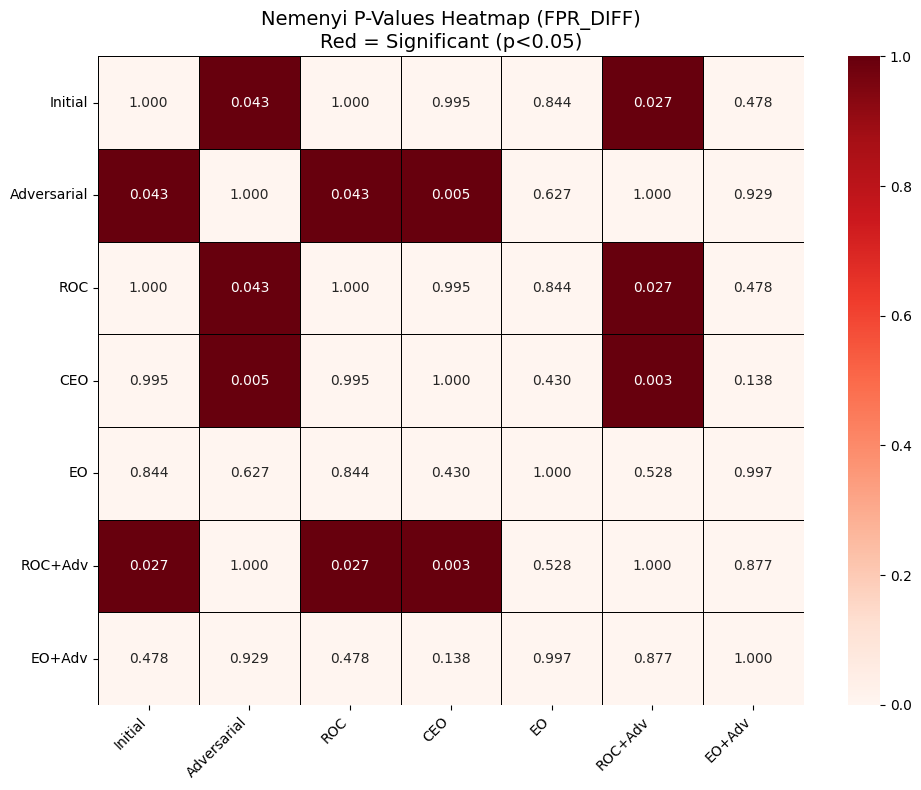

In [ ]:
res_svc_sex = run_fairness_pipeline("svc", X, y, "sex_Male")

In [ ]:
res_svc_sex

{'Initial': {'accuracy': [0.6909216909216909,
   0.6777546777546778,
   0.6548856548856549,
   0.6604296604296604,
   0.6678224687933426],
  'di': [np.float64(0.6487084870848709),
   np.float64(0.5046099537843425),
   np.float64(0.5101830663615561),
   np.float64(0.47211072664359865),
   np.float64(0.5046560267992745)],
  'eod': [np.float64(-0.09973254935587272),
   np.float64(-0.2538282826569892),
   np.float64(-0.14533422064477958),
   np.float64(-0.22414289830020162),
   np.float64(-0.12513015250811543)],
  'fpr_diff': [np.float64(-0.06395016777325624),
   np.float64(-0.11830799735624586),
   np.float64(-0.16381013871769287),
   np.float64(-0.13859275053304904),
   np.float64(-0.12645833333333334)]},
 'Adversarial': {'accuracy': [0.6077616077616078,
   0.6805266805266805,
   0.647955647955648,
   0.6638946638946639,
   0.673370319001387],
  'di': [np.float64(3.47045692679149),
   np.float64(1.0150956230541819),
   np.float64(1.2213157894736841),
   np.float64(1.0721880792117842),
  

### Logistic Regression

epoch 0; iter: 0; batch classifier loss: 0.690874; batch adversarial loss: 0.914845
epoch 1; iter: 0; batch classifier loss: 0.773146; batch adversarial loss: 0.923926
epoch 2; iter: 0; batch classifier loss: 0.665107; batch adversarial loss: 0.974763
epoch 3; iter: 0; batch classifier loss: 0.710694; batch adversarial loss: 0.877219
epoch 4; iter: 0; batch classifier loss: 0.782344; batch adversarial loss: 0.822398
epoch 5; iter: 0; batch classifier loss: 0.677511; batch adversarial loss: 0.798576
epoch 6; iter: 0; batch classifier loss: 0.661586; batch adversarial loss: 0.760184
epoch 7; iter: 0; batch classifier loss: 0.613467; batch adversarial loss: 0.712394
epoch 8; iter: 0; batch classifier loss: 0.586314; batch adversarial loss: 0.688123
epoch 9; iter: 0; batch classifier loss: 0.618258; batch adversarial loss: 0.654896
epoch 10; iter: 0; batch classifier loss: 0.596310; batch adversarial loss: 0.641669
epoch 11; iter: 0; batch classifier loss: 0.593158; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.787866; batch adversarial loss: 0.614251
epoch 1; iter: 0; batch classifier loss: 0.671780; batch adversarial loss: 0.647202
epoch 2; iter: 0; batch classifier loss: 0.623872; batch adversarial loss: 0.631107
epoch 3; iter: 0; batch classifier loss: 0.739613; batch adversarial loss: 0.651029
epoch 4; iter: 0; batch classifier loss: 0.712336; batch adversarial loss: 0.668689
epoch 5; iter: 0; batch classifier loss: 0.883804; batch adversarial loss: 0.664832
epoch 6; iter: 0; batch classifier loss: 0.839914; batch adversarial loss: 0.679153
epoch 7; iter: 0; batch classifier loss: 0.894552; batch adversarial loss: 0.684634
epoch 8; iter: 0; batch classifier loss: 0.901363; batch adversarial loss: 0.627944
epoch 9; iter: 0; batch classifier loss: 0.935796; batch adversarial loss: 0.655409
epoch 10; iter: 0; batch classifier loss: 0.837636; batch adversarial loss: 0.610030
epoch 11; iter: 0; batch classifier loss: 0.823766; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.753063; batch adversarial loss: 0.599414
epoch 1; iter: 0; batch classifier loss: 0.679492; batch adversarial loss: 0.637222
epoch 2; iter: 0; batch classifier loss: 0.629681; batch adversarial loss: 0.647714
epoch 3; iter: 0; batch classifier loss: 0.676571; batch adversarial loss: 0.654698
epoch 4; iter: 0; batch classifier loss: 0.762125; batch adversarial loss: 0.694055
epoch 5; iter: 0; batch classifier loss: 0.935106; batch adversarial loss: 0.683678
epoch 6; iter: 0; batch classifier loss: 0.912636; batch adversarial loss: 0.686208
epoch 7; iter: 0; batch classifier loss: 0.853450; batch adversarial loss: 0.660677
epoch 8; iter: 0; batch classifier loss: 0.814703; batch adversarial loss: 0.628643
epoch 9; iter: 0; batch classifier loss: 0.817992; batch adversarial loss: 0.603044
epoch 10; iter: 0; batch classifier loss: 0.921624; batch adversarial loss: 0.578023
epoch 11; iter: 0; batch classifier loss: 0.814800; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.757010; batch adversarial loss: 0.602354
epoch 1; iter: 0; batch classifier loss: 0.635618; batch adversarial loss: 0.655714
epoch 2; iter: 0; batch classifier loss: 0.691444; batch adversarial loss: 0.652248
epoch 3; iter: 0; batch classifier loss: 0.708830; batch adversarial loss: 0.658024
epoch 4; iter: 0; batch classifier loss: 0.898788; batch adversarial loss: 0.661786
epoch 5; iter: 0; batch classifier loss: 0.853121; batch adversarial loss: 0.697291
epoch 6; iter: 0; batch classifier loss: 0.899150; batch adversarial loss: 0.627620
epoch 7; iter: 0; batch classifier loss: 0.942164; batch adversarial loss: 0.648629
epoch 8; iter: 0; batch classifier loss: 0.906727; batch adversarial loss: 0.625806
epoch 9; iter: 0; batch classifier loss: 0.860503; batch adversarial loss: 0.612284
epoch 10; iter: 0; batch classifier loss: 0.824770; batch adversarial loss: 0.566394
epoch 11; iter: 0; batch classifier loss: 0.814262; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.722306; batch adversarial loss: 0.612850
epoch 1; iter: 0; batch classifier loss: 0.611124; batch adversarial loss: 0.602866
epoch 2; iter: 0; batch classifier loss: 0.599158; batch adversarial loss: 0.602301
epoch 3; iter: 0; batch classifier loss: 0.595539; batch adversarial loss: 0.584665
epoch 4; iter: 0; batch classifier loss: 0.614957; batch adversarial loss: 0.610186
epoch 5; iter: 0; batch classifier loss: 0.643595; batch adversarial loss: 0.644005
epoch 6; iter: 0; batch classifier loss: 0.559516; batch adversarial loss: 0.613861
epoch 7; iter: 0; batch classifier loss: 0.551761; batch adversarial loss: 0.580985
epoch 8; iter: 0; batch classifier loss: 0.668102; batch adversarial loss: 0.603093
epoch 9; iter: 0; batch classifier loss: 0.566958; batch adversarial loss: 0.601840
epoch 10; iter: 0; batch classifier loss: 0.585687; batch adversarial loss: 0.518791
epoch 11; iter: 0; batch classifier loss: 0.584797; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.675 (95% CI: 0.665-0.686)
  DI:       0.533 (95% CI: 0.496-0.586)
  EOD:      -0.173 (95% CI: -0.226--0.120)
  FPR Diff: -0.112 (95% CI: -0.130--0.092)

Adversarial:
  Accuracy: 0.665 (95% CI: 0.656-0.672)
  DI:       1.220 (95% CI: 1.007-1.497)
  EOD:      0.118 (95% CI: 0.056-0.206)
  FPR Diff: 0.097 (95% CI: 0.034-0.189)

ROC:
  Accuracy: 0.675 (95% CI: 0.665-0.686)
  DI:       0.533 (95% CI: 0.496-0.586)
  EOD:      -0.173 (95% CI: -0.221--0.118)
  FPR Diff: -0.112 (95% CI: -0.131--0.090)

CEO:
  Accuracy: 0.666 (95% CI: 0.658-0.674)
  DI:       0.316 (95% CI: 0.105-0.509)
  EOD:      -0.336 (95% CI: -0.468--0.206)
  FPR Diff: -0.148 (95% CI: -0.188--0.109)

EO:
  Accuracy: 0.644 (95% CI: 0.630-0.660)
  DI:       0.890 (95% CI: 0.856-0.922)
  EOD:      0.000 (95% CI: -0.013-0.012)
  FPR Diff: -0.003 (95% CI: -0.012-0.007)

ROC+Adv:
  Accuracy: 0.649 (95% CI: 0.612-0.673)
  DI:       1.344 (95% CI: 0.991-1.9

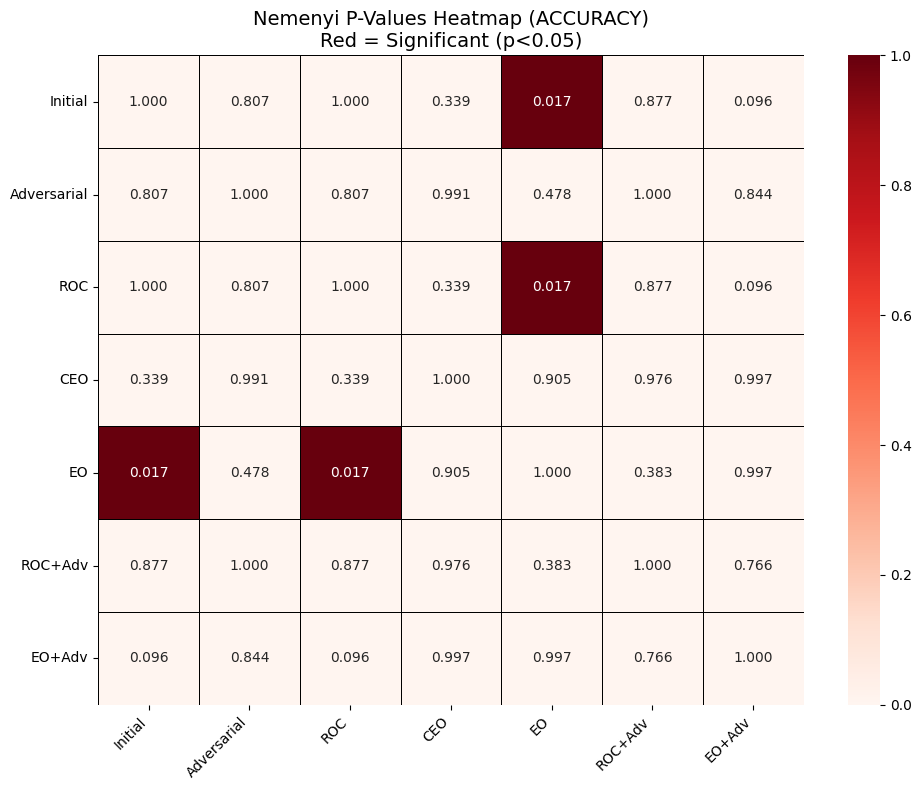


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(27.905454545454564), pvalue=np.float64(9.789408630050595e-05))


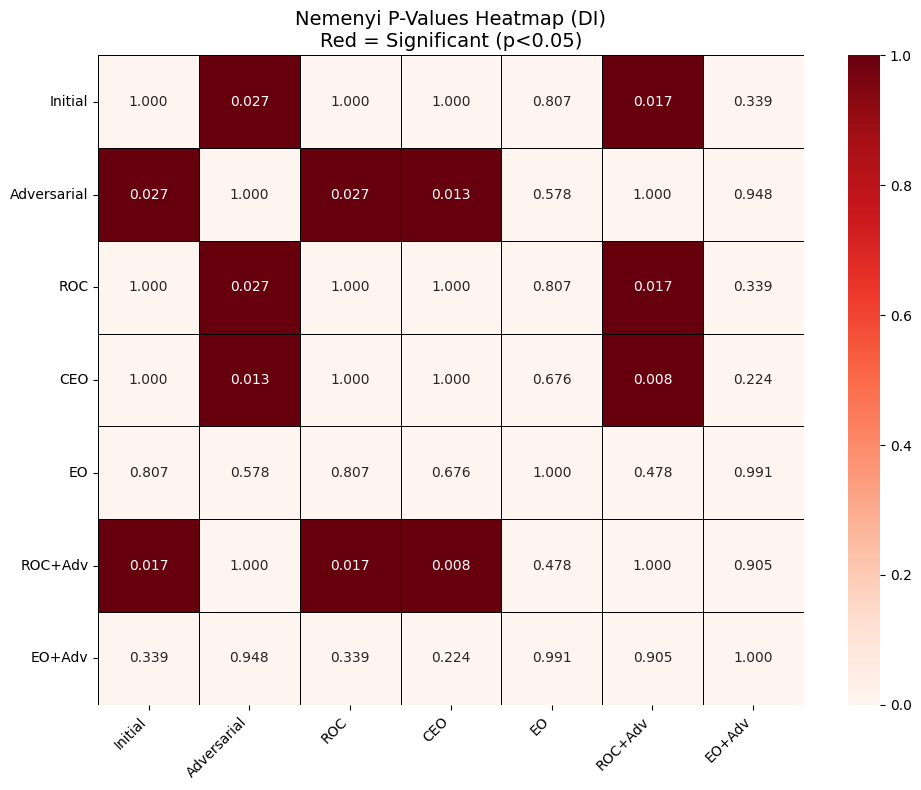


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(27.38181818181818), pvalue=np.float64(0.00012279726731402002))


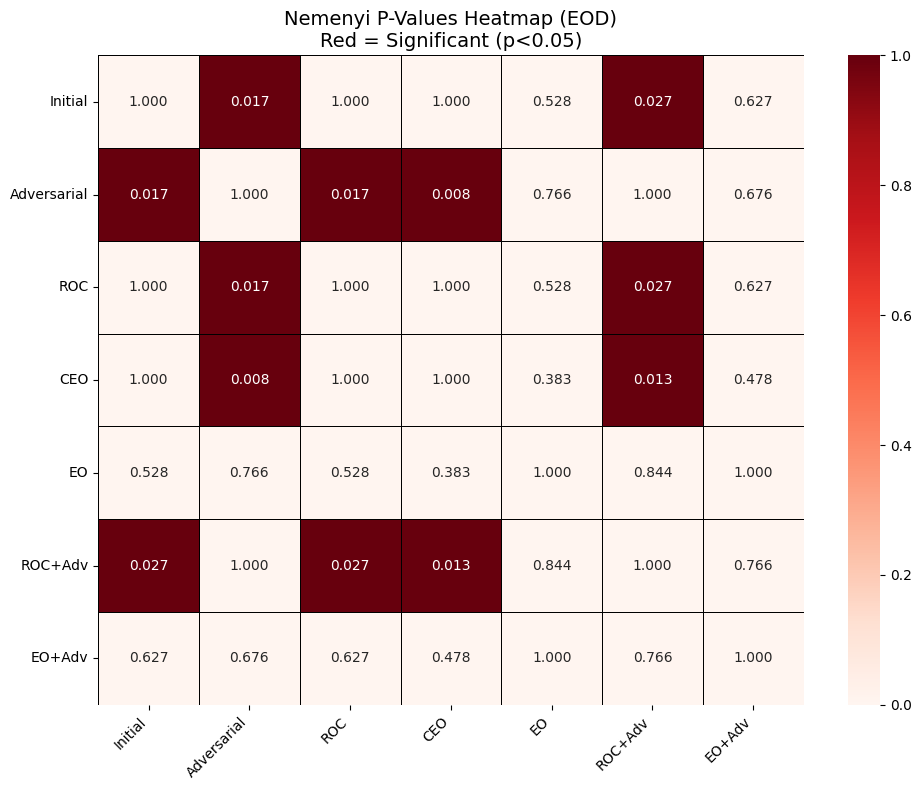


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(26.683636363636364), pvalue=np.float64(0.00016596126037480535))


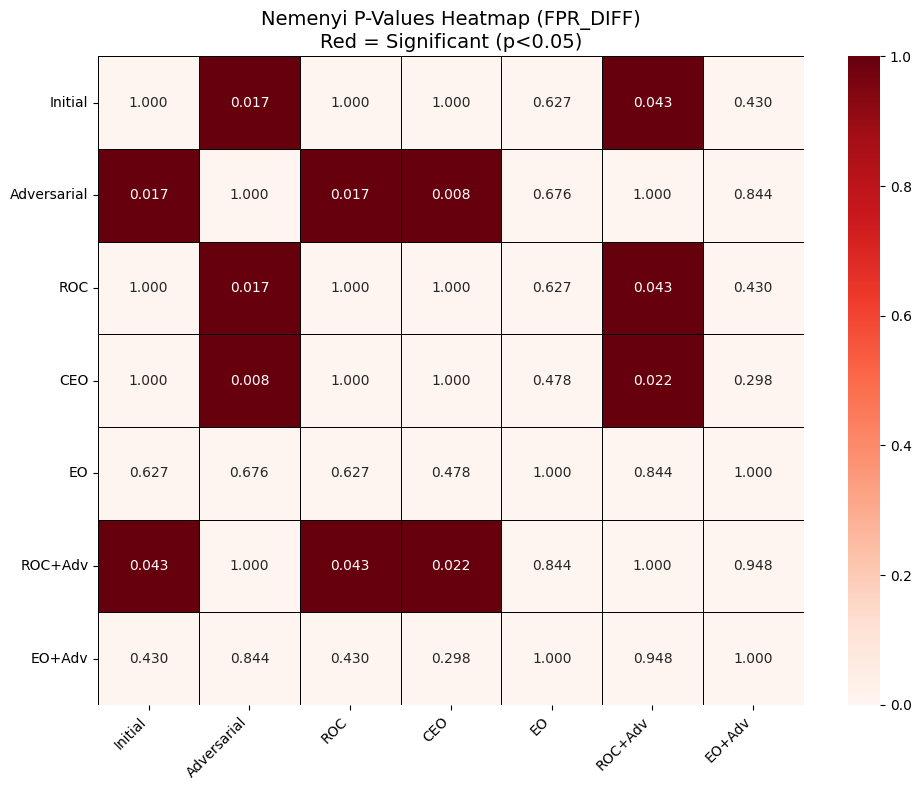

In [ ]:
res_lr_sex = run_fairness_pipeline("lr", X, y, "sex_Male")

In [ ]:
res_lr_sex

{'Initial': {'accuracy': [0.6916146916146916,
   0.6812196812196812,
   0.6618156618156619,
   0.6611226611226612,
   0.680998613037448],
  'di': [np.float64(0.6336222431991761),
   np.float64(0.48101201771030994),
   np.float64(0.5214606741573033),
   np.float64(0.5180524132730014),
   np.float64(0.5092687198949059)],
  'eod': [np.float64(-0.08907535575018888),
   np.float64(-0.26095066899557395),
   np.float64(-0.18748151434486843),
   np.float64(-0.2099779122251032),
   np.float64(-0.11822951756803662)],
  'fpr_diff': [np.float64(-0.07368637110016421),
   np.float64(-0.10064205457463885),
   np.float64(-0.1327796364774706),
   np.float64(-0.11276948590381428),
   np.float64(-0.138125)]},
 'Adversarial': {'accuracy': [0.6666666666666666,
   0.6742896742896742,
   0.647955647955648,
   0.6638946638946639,
   0.673370319001387],
  'di': [np.float64(1.7298892988929888),
   np.float64(1.1662483344178984),
   np.float64(1.2213157894736841),
   np.float64(1.0721880792117842),
   np.float64

### GBDT

epoch 0; iter: 0; batch classifier loss: 0.808830; batch adversarial loss: 0.622279
epoch 1; iter: 0; batch classifier loss: 0.669512; batch adversarial loss: 0.629758
epoch 2; iter: 0; batch classifier loss: 0.585820; batch adversarial loss: 0.588493
epoch 3; iter: 0; batch classifier loss: 0.649206; batch adversarial loss: 0.620467
epoch 4; iter: 0; batch classifier loss: 0.701997; batch adversarial loss: 0.621126
epoch 5; iter: 0; batch classifier loss: 0.643851; batch adversarial loss: 0.644004
epoch 6; iter: 0; batch classifier loss: 0.594439; batch adversarial loss: 0.590668
epoch 7; iter: 0; batch classifier loss: 0.697631; batch adversarial loss: 0.599056
epoch 8; iter: 0; batch classifier loss: 0.663418; batch adversarial loss: 0.592073
epoch 9; iter: 0; batch classifier loss: 0.650725; batch adversarial loss: 0.562782
epoch 10; iter: 0; batch classifier loss: 0.715405; batch adversarial loss: 0.598667
epoch 11; iter: 0; batch classifier loss: 0.686372; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.787866; batch adversarial loss: 0.614251
epoch 1; iter: 0; batch classifier loss: 0.671780; batch adversarial loss: 0.647202
epoch 2; iter: 0; batch classifier loss: 0.623872; batch adversarial loss: 0.631107
epoch 3; iter: 0; batch classifier loss: 0.739613; batch adversarial loss: 0.651029
epoch 4; iter: 0; batch classifier loss: 0.712336; batch adversarial loss: 0.668689
epoch 5; iter: 0; batch classifier loss: 0.883804; batch adversarial loss: 0.664832
epoch 6; iter: 0; batch classifier loss: 0.839914; batch adversarial loss: 0.679153
epoch 7; iter: 0; batch classifier loss: 0.894552; batch adversarial loss: 0.684634
epoch 8; iter: 0; batch classifier loss: 0.901363; batch adversarial loss: 0.627944
epoch 9; iter: 0; batch classifier loss: 0.935796; batch adversarial loss: 0.655409
epoch 10; iter: 0; batch classifier loss: 0.837636; batch adversarial loss: 0.610030
epoch 11; iter: 0; batch classifier loss: 0.823766; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.753063; batch adversarial loss: 0.599414
epoch 1; iter: 0; batch classifier loss: 0.679492; batch adversarial loss: 0.637222
epoch 2; iter: 0; batch classifier loss: 0.629681; batch adversarial loss: 0.647714
epoch 3; iter: 0; batch classifier loss: 0.676571; batch adversarial loss: 0.654698
epoch 4; iter: 0; batch classifier loss: 0.762125; batch adversarial loss: 0.694055
epoch 5; iter: 0; batch classifier loss: 0.935106; batch adversarial loss: 0.683678
epoch 6; iter: 0; batch classifier loss: 0.912636; batch adversarial loss: 0.686208
epoch 7; iter: 0; batch classifier loss: 0.853450; batch adversarial loss: 0.660677
epoch 8; iter: 0; batch classifier loss: 0.814703; batch adversarial loss: 0.628643
epoch 9; iter: 0; batch classifier loss: 0.817992; batch adversarial loss: 0.603044
epoch 10; iter: 0; batch classifier loss: 0.921624; batch adversarial loss: 0.578023
epoch 11; iter: 0; batch classifier loss: 0.814800; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.757010; batch adversarial loss: 0.602354
epoch 1; iter: 0; batch classifier loss: 0.635618; batch adversarial loss: 0.655714
epoch 2; iter: 0; batch classifier loss: 0.691444; batch adversarial loss: 0.652248
epoch 3; iter: 0; batch classifier loss: 0.708830; batch adversarial loss: 0.658024
epoch 4; iter: 0; batch classifier loss: 0.898788; batch adversarial loss: 0.661786
epoch 5; iter: 0; batch classifier loss: 0.853121; batch adversarial loss: 0.697291
epoch 6; iter: 0; batch classifier loss: 0.899150; batch adversarial loss: 0.627620
epoch 7; iter: 0; batch classifier loss: 0.942164; batch adversarial loss: 0.648629
epoch 8; iter: 0; batch classifier loss: 0.906727; batch adversarial loss: 0.625806
epoch 9; iter: 0; batch classifier loss: 0.860503; batch adversarial loss: 0.612284
epoch 10; iter: 0; batch classifier loss: 0.824770; batch adversarial loss: 0.566394
epoch 11; iter: 0; batch classifier loss: 0.814262; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.722306; batch adversarial loss: 0.612850
epoch 1; iter: 0; batch classifier loss: 0.611124; batch adversarial loss: 0.602866
epoch 2; iter: 0; batch classifier loss: 0.599158; batch adversarial loss: 0.602301
epoch 3; iter: 0; batch classifier loss: 0.595539; batch adversarial loss: 0.584665
epoch 4; iter: 0; batch classifier loss: 0.614957; batch adversarial loss: 0.610186
epoch 5; iter: 0; batch classifier loss: 0.643595; batch adversarial loss: 0.644005
epoch 6; iter: 0; batch classifier loss: 0.559516; batch adversarial loss: 0.613861
epoch 7; iter: 0; batch classifier loss: 0.551761; batch adversarial loss: 0.580985
epoch 8; iter: 0; batch classifier loss: 0.668102; batch adversarial loss: 0.603093
epoch 9; iter: 0; batch classifier loss: 0.566958; batch adversarial loss: 0.601840
epoch 10; iter: 0; batch classifier loss: 0.585687; batch adversarial loss: 0.518791
epoch 11; iter: 0; batch classifier loss: 0.584797; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.674 (95% CI: 0.661-0.687)
  DI:       0.557 (95% CI: 0.521-0.612)
  EOD:      -0.169 (95% CI: -0.213--0.125)
  FPR Diff: -0.127 (95% CI: -0.159--0.097)

Adversarial:
  Accuracy: 0.665 (95% CI: 0.656-0.672)
  DI:       1.111 (95% CI: 0.997-1.197)
  EOD:      0.082 (95% CI: 0.056-0.108)
  FPR Diff: 0.064 (95% CI: 0.034-0.094)

ROC:
  Accuracy: 0.674 (95% CI: 0.660-0.689)
  DI:       0.557 (95% CI: 0.521-0.612)
  EOD:      -0.169 (95% CI: -0.213--0.126)
  FPR Diff: -0.127 (95% CI: -0.160--0.089)

CEO:
  Accuracy: 0.667 (95% CI: 0.655-0.681)
  DI:       0.239 (95% CI: 0.087-0.376)
  EOD:      -0.411 (95% CI: -0.511--0.312)
  FPR Diff: -0.200 (95% CI: -0.231--0.164)

EO:
  Accuracy: 0.649 (95% CI: 0.634-0.665)
  DI:       0.897 (95% CI: 0.861-0.931)
  EOD:      -0.014 (95% CI: -0.026--0.003)
  FPR Diff: 0.005 (95% CI: -0.002-0.012)

ROC+Adv:
  Accuracy: 0.673 (95% CI: 0.663-0.683)
  DI:       1.019 (95% CI: 0.965-1.

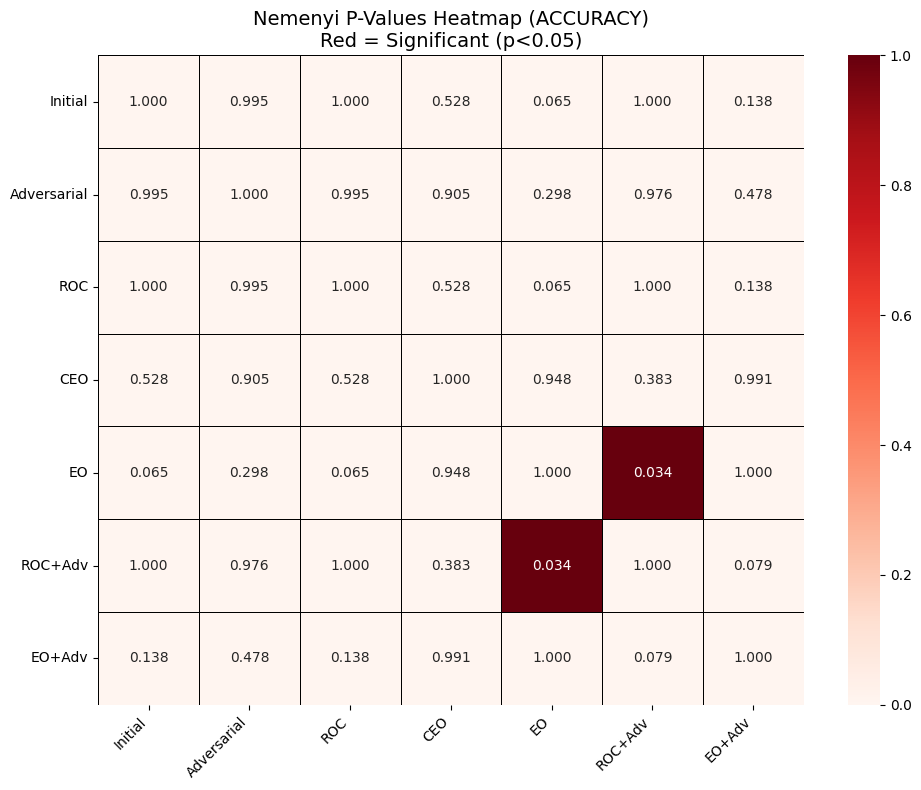


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(29.127272727272732), pvalue=np.float64(5.755386316475225e-05))


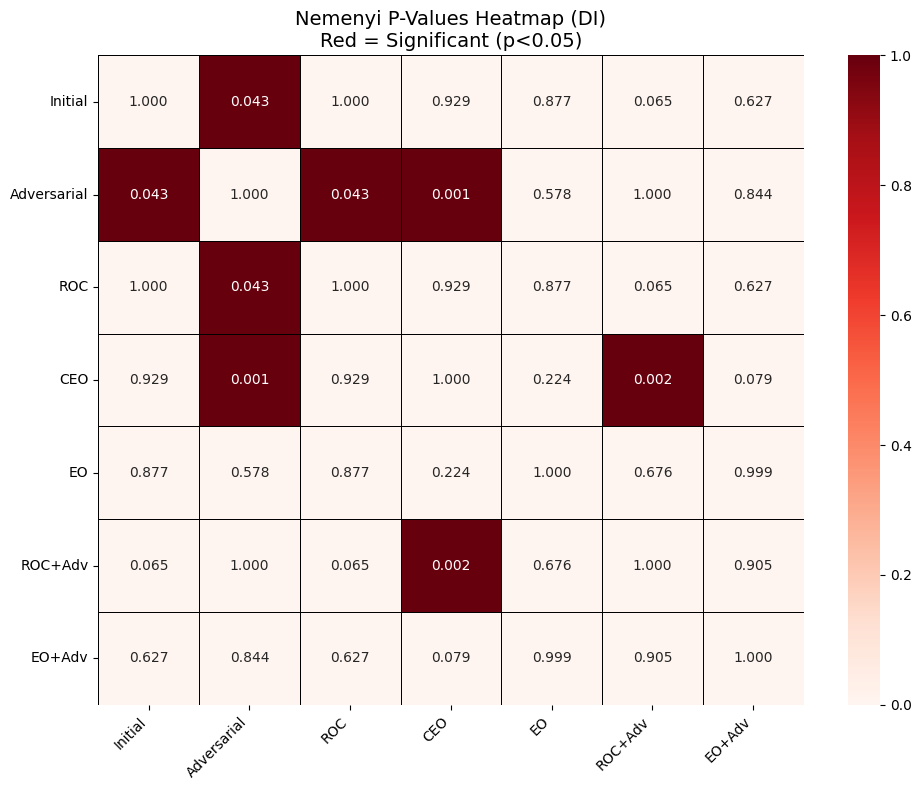


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(29.476363636363626), pvalue=np.float64(4.942172849842745e-05))


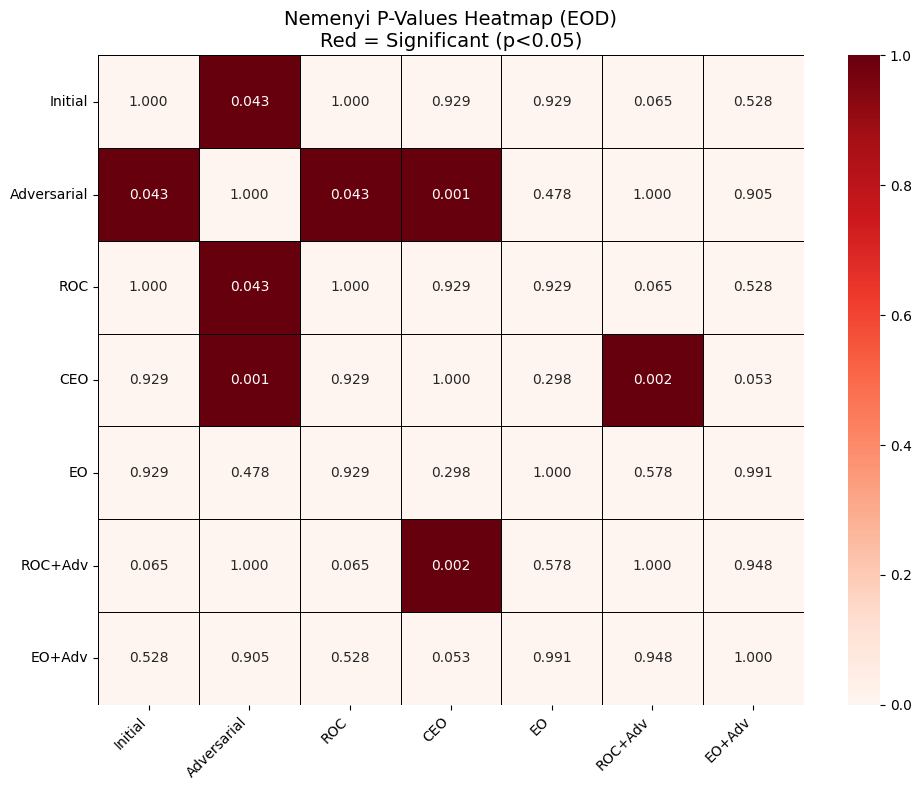


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(27.941605839416074), pvalue=np.float64(9.637202813573717e-05))


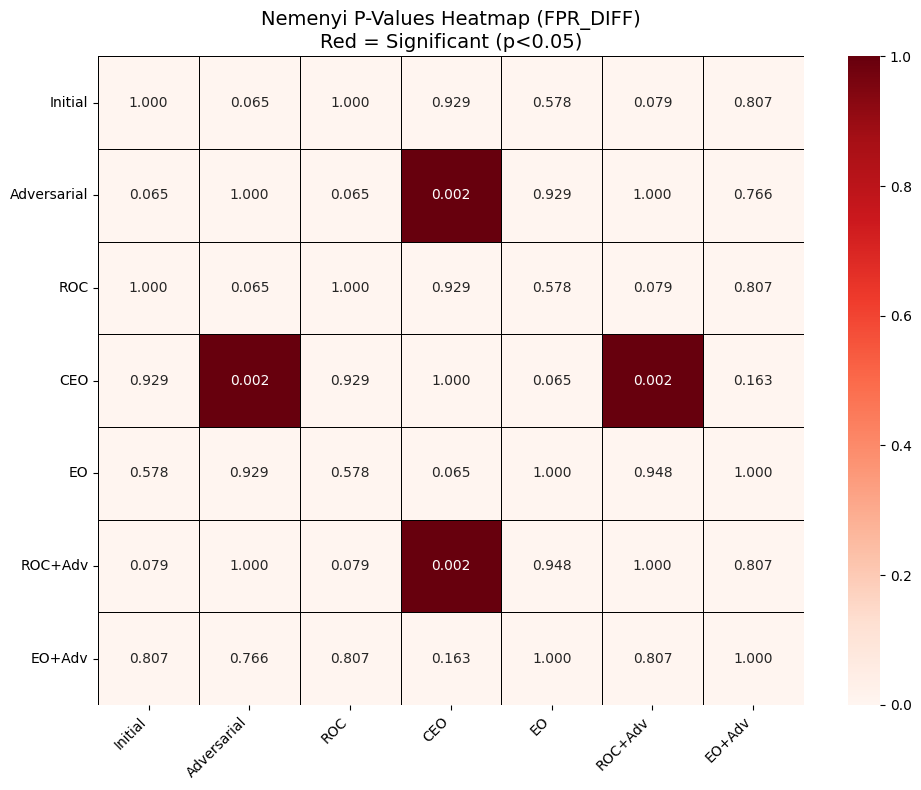

In [ ]:
res_gbc_sex = run_fairness_pipeline("gbc", X, y, "sex_Male")

In [ ]:
res_gbc_sex

{'Initial': {'accuracy': [0.7006237006237006,
   0.6701316701316701,
   0.6534996534996536,
   0.6618156618156619,
   0.6816920943134536],
  'di': [np.float64(0.6625107953207191),
   np.float64(0.5353130543328296),
   np.float64(0.5076842105263157),
   np.float64(0.5387348969438521),
   np.float64(0.5418122525040764)],
  'eod': [np.float64(-0.10432616728935712),
   np.float64(-0.25396394715867654),
   np.float64(-0.15753475303164743),
   np.float64(-0.19696533179679243),
   np.float64(-0.1307649905065229)],
  'fpr_diff': [np.float64(-0.06078210894552724),
   np.float64(-0.11778868850911148),
   np.float64(-0.1831601807830017),
   np.float64(-0.1433309642264866),
   np.float64(-0.13187499999999996)]},
 'Adversarial': {'accuracy': [0.665973665973666,
   0.6742896742896742,
   0.647955647955648,
   0.6638946638946639,
   0.673370319001387],
  'di': [np.float64(1.1878573185731858),
   np.float64(1.1662483344178984),
   np.float64(1.2213157894736841),
   np.float64(1.0721880792117842),
   n

### RFC

epoch 0; iter: 0; batch classifier loss: 0.747481; batch adversarial loss: 0.801656
epoch 1; iter: 0; batch classifier loss: 0.631718; batch adversarial loss: 0.887494
epoch 2; iter: 0; batch classifier loss: 0.716496; batch adversarial loss: 0.831624
epoch 3; iter: 0; batch classifier loss: 0.684718; batch adversarial loss: 0.769852
epoch 4; iter: 0; batch classifier loss: 0.608889; batch adversarial loss: 0.770925
epoch 5; iter: 0; batch classifier loss: 0.570931; batch adversarial loss: 0.727530
epoch 6; iter: 0; batch classifier loss: 0.621275; batch adversarial loss: 0.704208
epoch 7; iter: 0; batch classifier loss: 0.637249; batch adversarial loss: 0.650868
epoch 8; iter: 0; batch classifier loss: 0.656508; batch adversarial loss: 0.634277
epoch 9; iter: 0; batch classifier loss: 0.585381; batch adversarial loss: 0.633504
epoch 10; iter: 0; batch classifier loss: 0.639050; batch adversarial loss: 0.630054
epoch 11; iter: 0; batch classifier loss: 0.575421; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.731668; batch adversarial loss: 0.782727
epoch 1; iter: 0; batch classifier loss: 0.633669; batch adversarial loss: 0.817998
epoch 2; iter: 0; batch classifier loss: 0.589919; batch adversarial loss: 0.776641
epoch 3; iter: 0; batch classifier loss: 0.617244; batch adversarial loss: 0.772382
epoch 4; iter: 0; batch classifier loss: 0.628826; batch adversarial loss: 0.719893
epoch 5; iter: 0; batch classifier loss: 0.626198; batch adversarial loss: 0.679742
epoch 6; iter: 0; batch classifier loss: 0.598905; batch adversarial loss: 0.669459
epoch 7; iter: 0; batch classifier loss: 0.643881; batch adversarial loss: 0.671377
epoch 8; iter: 0; batch classifier loss: 0.608625; batch adversarial loss: 0.635465
epoch 9; iter: 0; batch classifier loss: 0.612908; batch adversarial loss: 0.627306
epoch 10; iter: 0; batch classifier loss: 0.639974; batch adversarial loss: 0.581525
epoch 11; iter: 0; batch classifier loss: 0.578141; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.706438; batch adversarial loss: 1.046900
epoch 1; iter: 0; batch classifier loss: 0.785084; batch adversarial loss: 1.213809
epoch 2; iter: 0; batch classifier loss: 0.912427; batch adversarial loss: 1.119121
epoch 3; iter: 0; batch classifier loss: 0.816868; batch adversarial loss: 1.083454
epoch 4; iter: 0; batch classifier loss: 0.855798; batch adversarial loss: 1.024848
epoch 5; iter: 0; batch classifier loss: 0.743453; batch adversarial loss: 0.963592
epoch 6; iter: 0; batch classifier loss: 0.802264; batch adversarial loss: 0.909919
epoch 7; iter: 0; batch classifier loss: 0.806365; batch adversarial loss: 0.859771
epoch 8; iter: 0; batch classifier loss: 0.768571; batch adversarial loss: 0.811141
epoch 9; iter: 0; batch classifier loss: 0.827677; batch adversarial loss: 0.771152
epoch 10; iter: 0; batch classifier loss: 0.691836; batch adversarial loss: 0.735820
epoch 11; iter: 0; batch classifier loss: 0.651963; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.757010; batch adversarial loss: 0.602354
epoch 1; iter: 0; batch classifier loss: 0.635618; batch adversarial loss: 0.655714
epoch 2; iter: 0; batch classifier loss: 0.691444; batch adversarial loss: 0.652248
epoch 3; iter: 0; batch classifier loss: 0.708830; batch adversarial loss: 0.658024
epoch 4; iter: 0; batch classifier loss: 0.898788; batch adversarial loss: 0.661786
epoch 5; iter: 0; batch classifier loss: 0.853121; batch adversarial loss: 0.697291
epoch 6; iter: 0; batch classifier loss: 0.899150; batch adversarial loss: 0.627620
epoch 7; iter: 0; batch classifier loss: 0.942164; batch adversarial loss: 0.648629
epoch 8; iter: 0; batch classifier loss: 0.906727; batch adversarial loss: 0.625806
epoch 9; iter: 0; batch classifier loss: 0.860503; batch adversarial loss: 0.612284
epoch 10; iter: 0; batch classifier loss: 0.824770; batch adversarial loss: 0.566394
epoch 11; iter: 0; batch classifier loss: 0.814262; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.722306; batch adversarial loss: 0.612850
epoch 1; iter: 0; batch classifier loss: 0.611124; batch adversarial loss: 0.602866
epoch 2; iter: 0; batch classifier loss: 0.599158; batch adversarial loss: 0.602301
epoch 3; iter: 0; batch classifier loss: 0.595539; batch adversarial loss: 0.584665
epoch 4; iter: 0; batch classifier loss: 0.614957; batch adversarial loss: 0.610186
epoch 5; iter: 0; batch classifier loss: 0.643595; batch adversarial loss: 0.644005
epoch 6; iter: 0; batch classifier loss: 0.559516; batch adversarial loss: 0.613861
epoch 7; iter: 0; batch classifier loss: 0.551761; batch adversarial loss: 0.580985
epoch 8; iter: 0; batch classifier loss: 0.668102; batch adversarial loss: 0.603093
epoch 9; iter: 0; batch classifier loss: 0.566958; batch adversarial loss: 0.601840
epoch 10; iter: 0; batch classifier loss: 0.585687; batch adversarial loss: 0.518791
epoch 11; iter: 0; batch classifier loss: 0.584797; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.669 (95% CI: 0.655-0.684)
  DI:       0.568 (95% CI: 0.522-0.617)
  EOD:      -0.155 (95% CI: -0.187--0.122)
  FPR Diff: -0.129 (95% CI: -0.162--0.096)

Adversarial:
  Accuracy: 0.654 (95% CI: 0.630-0.669)
  DI:       1.525 (95% CI: 0.800-2.517)
  EOD:      0.146 (95% CI: -0.017-0.347)
  FPR Diff: 0.193 (95% CI: -0.040-0.510)

ROC:
  Accuracy: 0.669 (95% CI: 0.655-0.686)
  DI:       0.568 (95% CI: 0.525-0.623)
  EOD:      -0.155 (95% CI: -0.186--0.123)
  FPR Diff: -0.129 (95% CI: -0.166--0.089)

CEO:
  Accuracy: 0.662 (95% CI: 0.650-0.678)
  DI:       0.271 (95% CI: 0.103-0.429)
  EOD:      -0.385 (95% CI: -0.496--0.272)
  FPR Diff: -0.193 (95% CI: -0.225--0.158)

EO:
  Accuracy: 0.644 (95% CI: 0.632-0.661)
  DI:       0.901 (95% CI: 0.867-0.931)
  EOD:      0.000 (95% CI: -0.017-0.012)
  FPR Diff: -0.004 (95% CI: -0.014-0.009)

ROC+Adv:
  Accuracy: 0.613 (95% CI: 0.546-0.667)
  DI:       1.167 (95% CI: 0.983-1

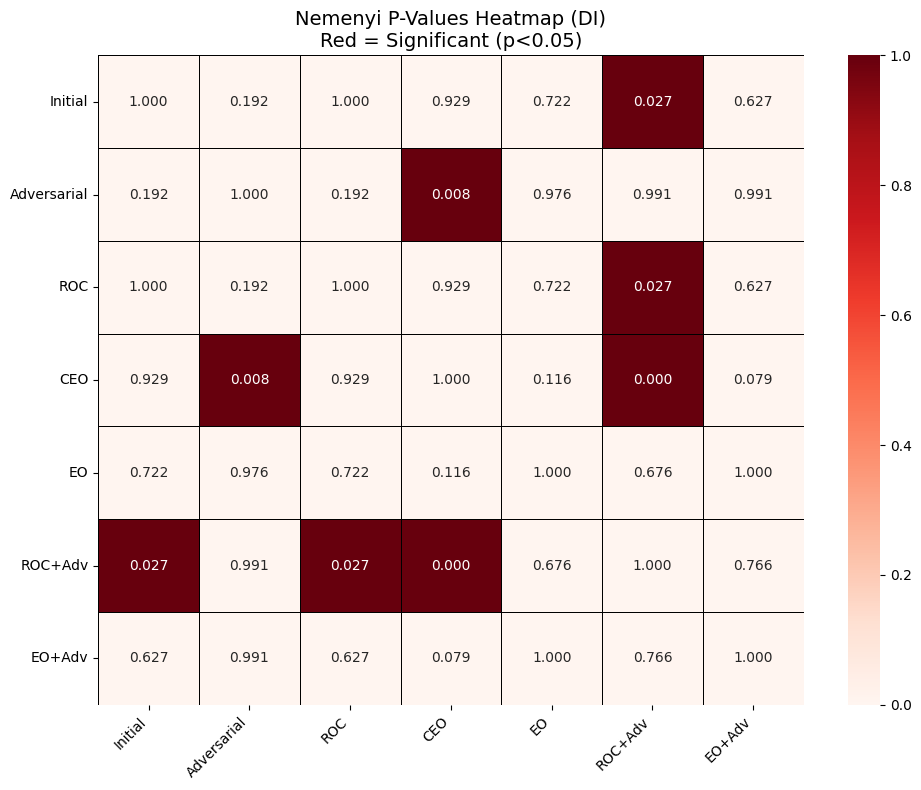


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(26.160000000000007), pvalue=np.float64(0.0002078684914616926))


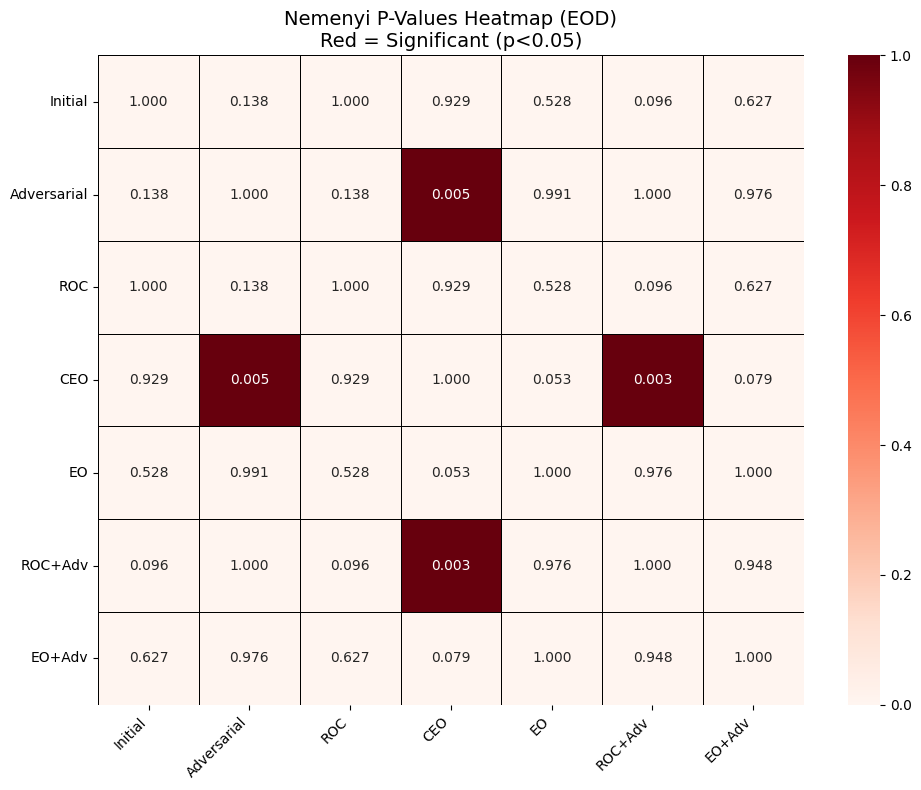


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(27.556363636363642), pvalue=np.float64(0.00011386957993938112))


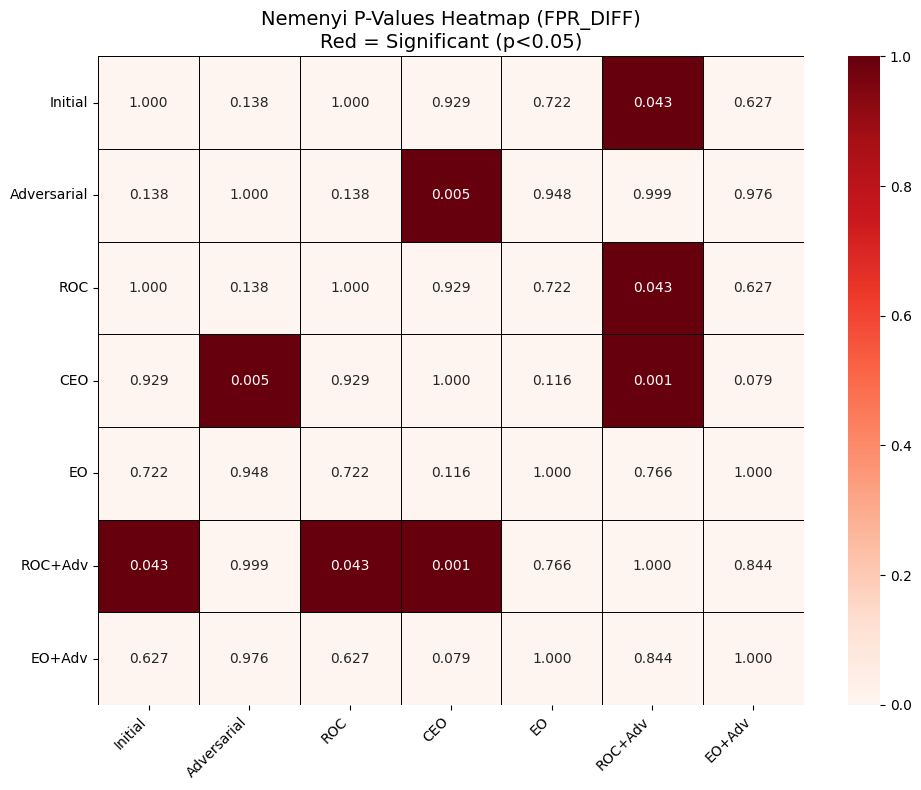

In [ ]:
res_rfc_sex = run_fairness_pipeline("rfc", X, y, "sex_Male")

In [ ]:
res_rfc_sex

{'Initial': {'accuracy': [0.6985446985446986,
   0.6666666666666666,
   0.6458766458766458,
   0.659043659043659,
   0.673370319001387],
  'di': [np.float64(0.6688660954406155),
   np.float64(0.592217969746674),
   np.float64(0.5309859154929578),
   np.float64(0.54549436795995),
   np.float64(0.500579111298931)],
  'eod': [np.float64(-0.10432616728935712),
   np.float64(-0.19138869575539685),
   np.float64(-0.16001183081928427),
   np.float64(-0.19509267262076246),
   np.float64(-0.12355811437087855)],
  'fpr_diff': [np.float64(-0.05863139858642108),
   np.float64(-0.10976300632612593),
   np.float64(-0.18224061356655122),
   np.float64(-0.1413567085208876),
   np.float64(-0.15458333333333332)]},
 'Adversarial': {'accuracy': [0.6077616077616078,
   0.6645876645876646,
   0.6611226611226612,
   0.6638946638946639,
   0.673370319001387],
  'di': [np.float64(3.47045692679149),
   np.float64(1.5658849095475966),
   np.float64(0.6092872570194385),
   np.float64(1.0721880792117842),
   np.fl

### NN (MLPClassifier)

epoch 0; iter: 0; batch classifier loss: 0.645437; batch adversarial loss: 0.879133
epoch 1; iter: 0; batch classifier loss: 0.640194; batch adversarial loss: 0.901767
epoch 2; iter: 0; batch classifier loss: 0.624603; batch adversarial loss: 0.820736
epoch 3; iter: 0; batch classifier loss: 0.614719; batch adversarial loss: 0.820484
epoch 4; iter: 0; batch classifier loss: 0.599964; batch adversarial loss: 0.750756
epoch 5; iter: 0; batch classifier loss: 0.605864; batch adversarial loss: 0.736105
epoch 6; iter: 0; batch classifier loss: 0.652399; batch adversarial loss: 0.699083
epoch 7; iter: 0; batch classifier loss: 0.589587; batch adversarial loss: 0.692556
epoch 8; iter: 0; batch classifier loss: 0.622420; batch adversarial loss: 0.681400
epoch 9; iter: 0; batch classifier loss: 0.628470; batch adversarial loss: 0.625354
epoch 10; iter: 0; batch classifier loss: 0.630000; batch adversarial loss: 0.619495
epoch 11; iter: 0; batch classifier loss: 0.599324; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.693150; batch adversarial loss: 0.751908
epoch 1; iter: 0; batch classifier loss: 0.700907; batch adversarial loss: 0.720198
epoch 2; iter: 0; batch classifier loss: 0.691118; batch adversarial loss: 0.717036
epoch 3; iter: 0; batch classifier loss: 0.610168; batch adversarial loss: 0.632894
epoch 4; iter: 0; batch classifier loss: 0.692330; batch adversarial loss: 0.641704
epoch 5; iter: 0; batch classifier loss: 0.629917; batch adversarial loss: 0.600715
epoch 6; iter: 0; batch classifier loss: 0.608600; batch adversarial loss: 0.604164
epoch 7; iter: 0; batch classifier loss: 0.633671; batch adversarial loss: 0.615507
epoch 8; iter: 0; batch classifier loss: 0.613284; batch adversarial loss: 0.556488
epoch 9; iter: 0; batch classifier loss: 0.615137; batch adversarial loss: 0.609947
epoch 10; iter: 0; batch classifier loss: 0.643849; batch adversarial loss: 0.596704
epoch 11; iter: 0; batch classifier loss: 0.608142; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.706356; batch adversarial loss: 0.972615
epoch 1; iter: 0; batch classifier loss: 0.699103; batch adversarial loss: 1.256769
epoch 2; iter: 0; batch classifier loss: 0.799306; batch adversarial loss: 1.249969
epoch 3; iter: 0; batch classifier loss: 0.895927; batch adversarial loss: 1.181491
epoch 4; iter: 0; batch classifier loss: 0.823023; batch adversarial loss: 1.144286
epoch 5; iter: 0; batch classifier loss: 0.750817; batch adversarial loss: 1.080909
epoch 6; iter: 0; batch classifier loss: 0.867783; batch adversarial loss: 1.019192
epoch 7; iter: 0; batch classifier loss: 0.909843; batch adversarial loss: 0.962768
epoch 8; iter: 0; batch classifier loss: 0.931225; batch adversarial loss: 0.902721
epoch 9; iter: 0; batch classifier loss: 0.832065; batch adversarial loss: 0.852087
epoch 10; iter: 0; batch classifier loss: 0.759686; batch adversarial loss: 0.809971
epoch 11; iter: 0; batch classifier loss: 0.880636; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.707252; batch adversarial loss: 0.675198
epoch 1; iter: 0; batch classifier loss: 0.661701; batch adversarial loss: 0.663037
epoch 2; iter: 0; batch classifier loss: 0.635620; batch adversarial loss: 0.612140
epoch 3; iter: 0; batch classifier loss: 0.570596; batch adversarial loss: 0.629506
epoch 4; iter: 0; batch classifier loss: 0.619631; batch adversarial loss: 0.602082
epoch 5; iter: 0; batch classifier loss: 0.568410; batch adversarial loss: 0.588479
epoch 6; iter: 0; batch classifier loss: 0.555189; batch adversarial loss: 0.571327
epoch 7; iter: 0; batch classifier loss: 0.595414; batch adversarial loss: 0.564806
epoch 8; iter: 0; batch classifier loss: 0.655733; batch adversarial loss: 0.529449
epoch 9; iter: 0; batch classifier loss: 0.615512; batch adversarial loss: 0.538052
epoch 10; iter: 0; batch classifier loss: 0.598453; batch adversarial loss: 0.572426
epoch 11; iter: 0; batch classifier loss: 0.568812; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.836512; batch adversarial loss: 0.791965
epoch 1; iter: 0; batch classifier loss: 0.619231; batch adversarial loss: 0.811766
epoch 2; iter: 0; batch classifier loss: 0.699205; batch adversarial loss: 0.941761
epoch 3; iter: 0; batch classifier loss: 0.823804; batch adversarial loss: 0.946800
epoch 4; iter: 0; batch classifier loss: 0.757835; batch adversarial loss: 0.871590
epoch 5; iter: 0; batch classifier loss: 0.701798; batch adversarial loss: 0.817571
epoch 6; iter: 0; batch classifier loss: 0.891851; batch adversarial loss: 0.813566
epoch 7; iter: 0; batch classifier loss: 0.788254; batch adversarial loss: 0.735287
epoch 8; iter: 0; batch classifier loss: 0.851569; batch adversarial loss: 0.725737
epoch 9; iter: 0; batch classifier loss: 0.701885; batch adversarial loss: 0.669730
epoch 10; iter: 0; batch classifier loss: 0.786216; batch adversarial loss: 0.625688
epoch 11; iter: 0; batch classifier loss: 0.678526; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.674 (95% CI: 0.664-0.685)
  DI:       0.510 (95% CI: 0.466-0.589)
  EOD:      -0.200 (95% CI: -0.255--0.143)
  FPR Diff: -0.139 (95% CI: -0.177--0.096)

Adversarial:
  Accuracy: 0.659 (95% CI: 0.641-0.671)
  DI:       1.525 (95% CI: 1.102-1.995)
  EOD:      0.183 (95% CI: 0.075-0.289)
  FPR Diff: 0.176 (95% CI: 0.057-0.281)

ROC:
  Accuracy: 0.674 (95% CI: 0.664-0.685)
  DI:       0.510 (95% CI: 0.465-0.590)
  EOD:      -0.200 (95% CI: -0.255--0.145)
  FPR Diff: -0.139 (95% CI: -0.177--0.097)

CEO:
  Accuracy: 0.669 (95% CI: 0.660-0.678)
  DI:       0.262 (95% CI: 0.168-0.356)
  EOD:      -0.391 (95% CI: -0.465--0.326)
  FPR Diff: -0.193 (95% CI: -0.234--0.151)

EO:
  Accuracy: 0.642 (95% CI: 0.624-0.663)
  DI:       0.895 (95% CI: 0.861-0.926)
  EOD:      -0.009 (95% CI: -0.021-0.003)
  FPR Diff: 0.003 (95% CI: -0.006-0.009)

ROC+Adv:
  Accuracy: 0.627 (95% CI: 0.576-0.672)
  DI:       1.199 (95% CI: 1.011-1.5

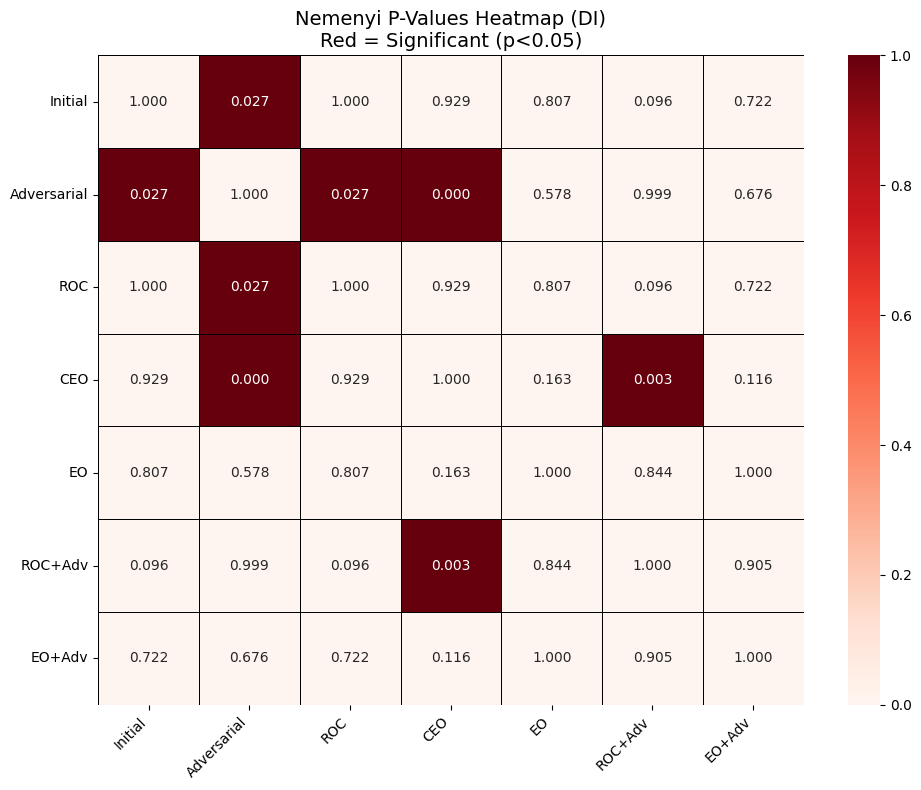


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(27.81818181818183), pvalue=np.float64(0.00010166707447890724))


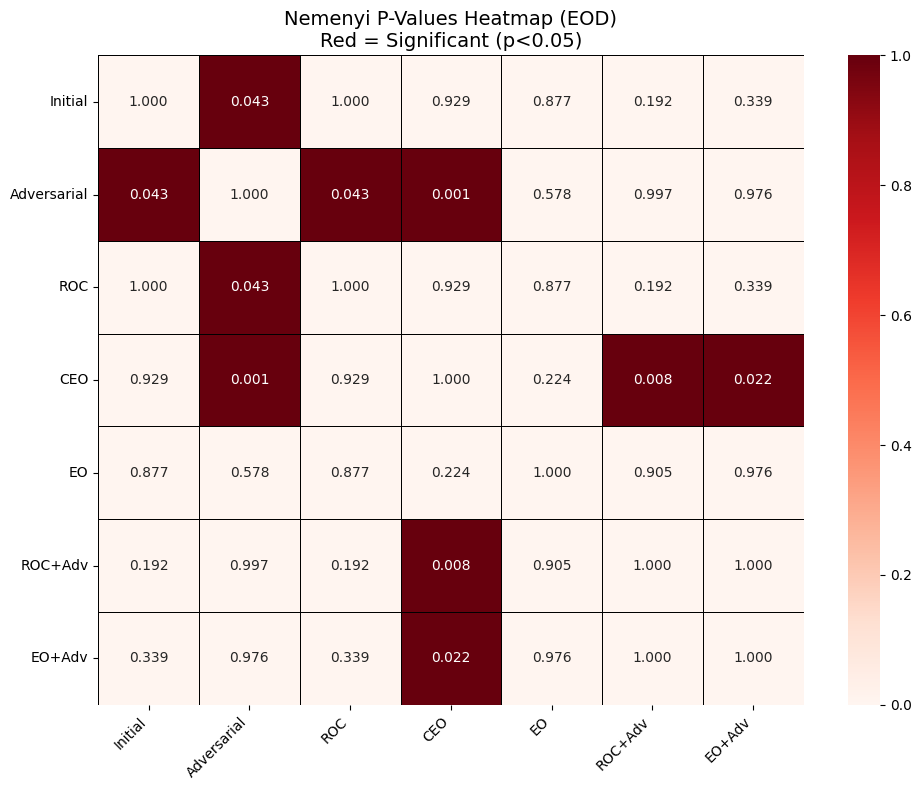


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(29.65090909090909), pvalue=np.float64(4.579308768016771e-05))


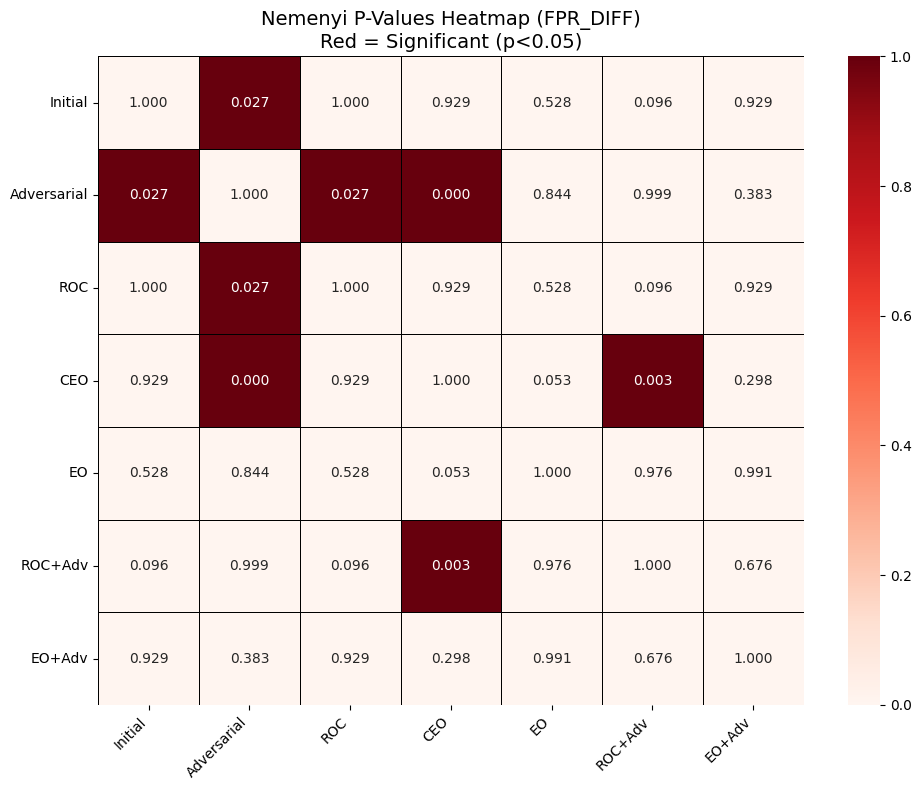

In [ ]:
res_nn_sex = run_fairness_pipeline("nn", X, y, "sex_Male")

In [ ]:
res_nn_sex

{'Initial': {'accuracy': [0.6943866943866944,
   0.6784476784476784,
   0.659043659043659,
   0.6611226611226612,
   0.6775312066574203],
  'di': [np.float64(0.6668507501401545),
   np.float64(0.4813895781637717),
   np.float64(0.4775247524752475),
   np.float64(0.4574386990217253),
   np.float64(0.4678882305610416)],
  'eod': [np.float64(-0.09356689328515144),
   np.float64(-0.27957062185215964),
   np.float64(-0.19195504288671994),
   np.float64(-0.25304907327379234),
   np.float64(-0.18384679773789842)],
  'fpr_diff': [np.float64(-0.055231312914971076),
   np.float64(-0.11991313379284299),
   np.float64(-0.20059282737571169),
   np.float64(-0.1578614862196952),
   np.float64(-0.16249999999999998)]},
 'Adversarial': {'accuracy': [0.6604296604296604,
   0.6805266805266805,
   0.6257796257796258,
   0.6652806652806653,
   0.6622746185852982],
  'di': [np.float64(1.866703600011871),
   np.float64(1.0150956230541819),
   np.float64(2.343939393939394),
   np.float64(1.0787476280834913),
 

## For race

### XGB

epoch 0; iter: 0; batch classifier loss: 0.747481; batch adversarial loss: 0.729684
epoch 1; iter: 0; batch classifier loss: 0.587915; batch adversarial loss: 0.737738
epoch 2; iter: 0; batch classifier loss: 0.640067; batch adversarial loss: 0.738627
epoch 3; iter: 0; batch classifier loss: 0.623173; batch adversarial loss: 0.754897
epoch 4; iter: 0; batch classifier loss: 0.628618; batch adversarial loss: 0.731704
epoch 5; iter: 0; batch classifier loss: 0.555129; batch adversarial loss: 0.738679
epoch 6; iter: 0; batch classifier loss: 0.627959; batch adversarial loss: 0.739668
epoch 7; iter: 0; batch classifier loss: 0.628357; batch adversarial loss: 0.710046
epoch 8; iter: 0; batch classifier loss: 0.649102; batch adversarial loss: 0.711733
epoch 9; iter: 0; batch classifier loss: 0.587975; batch adversarial loss: 0.715188
epoch 10; iter: 0; batch classifier loss: 0.632750; batch adversarial loss: 0.705168
epoch 11; iter: 0; batch classifier loss: 0.562111; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.690208; batch adversarial loss: 0.669525
epoch 1; iter: 0; batch classifier loss: 0.708399; batch adversarial loss: 0.786699
epoch 2; iter: 0; batch classifier loss: 0.622063; batch adversarial loss: 0.767300
epoch 3; iter: 0; batch classifier loss: 0.783064; batch adversarial loss: 0.782400
epoch 4; iter: 0; batch classifier loss: 0.677495; batch adversarial loss: 0.745454
epoch 5; iter: 0; batch classifier loss: 0.677862; batch adversarial loss: 0.751921
epoch 6; iter: 0; batch classifier loss: 0.610199; batch adversarial loss: 0.732776
epoch 7; iter: 0; batch classifier loss: 0.658100; batch adversarial loss: 0.719155
epoch 8; iter: 0; batch classifier loss: 0.613542; batch adversarial loss: 0.719832
epoch 9; iter: 0; batch classifier loss: 0.683601; batch adversarial loss: 0.735451
epoch 10; iter: 0; batch classifier loss: 0.649501; batch adversarial loss: 0.711809
epoch 11; iter: 0; batch classifier loss: 0.579988; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.781863; batch adversarial loss: 0.707310
epoch 1; iter: 0; batch classifier loss: 0.622832; batch adversarial loss: 0.725281
epoch 2; iter: 0; batch classifier loss: 0.689052; batch adversarial loss: 0.726948
epoch 3; iter: 0; batch classifier loss: 0.601917; batch adversarial loss: 0.723488
epoch 4; iter: 0; batch classifier loss: 0.610314; batch adversarial loss: 0.690984
epoch 5; iter: 0; batch classifier loss: 0.689953; batch adversarial loss: 0.716161
epoch 6; iter: 0; batch classifier loss: 0.693250; batch adversarial loss: 0.714255
epoch 7; iter: 0; batch classifier loss: 0.687609; batch adversarial loss: 0.715415
epoch 8; iter: 0; batch classifier loss: 0.658113; batch adversarial loss: 0.711389
epoch 9; iter: 0; batch classifier loss: 0.700787; batch adversarial loss: 0.700523
epoch 10; iter: 0; batch classifier loss: 0.647447; batch adversarial loss: 0.697549
epoch 11; iter: 0; batch classifier loss: 0.589549; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.770888; batch adversarial loss: 0.697676
epoch 1; iter: 0; batch classifier loss: 0.655877; batch adversarial loss: 0.696818
epoch 2; iter: 0; batch classifier loss: 0.631308; batch adversarial loss: 0.690572
epoch 3; iter: 0; batch classifier loss: 0.573918; batch adversarial loss: 0.689247
epoch 4; iter: 0; batch classifier loss: 0.640518; batch adversarial loss: 0.689224
epoch 5; iter: 0; batch classifier loss: 0.576021; batch adversarial loss: 0.691173
epoch 6; iter: 0; batch classifier loss: 0.553580; batch adversarial loss: 0.693325
epoch 7; iter: 0; batch classifier loss: 0.580359; batch adversarial loss: 0.695140
epoch 8; iter: 0; batch classifier loss: 0.650441; batch adversarial loss: 0.693651
epoch 9; iter: 0; batch classifier loss: 0.655937; batch adversarial loss: 0.688720
epoch 10; iter: 0; batch classifier loss: 0.626186; batch adversarial loss: 0.689578
epoch 11; iter: 0; batch classifier loss: 0.581579; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.722306; batch adversarial loss: 0.792129
epoch 1; iter: 0; batch classifier loss: 0.680917; batch adversarial loss: 0.823807
epoch 2; iter: 0; batch classifier loss: 0.663318; batch adversarial loss: 0.874726
epoch 3; iter: 0; batch classifier loss: 0.677757; batch adversarial loss: 0.845944
epoch 4; iter: 0; batch classifier loss: 0.677966; batch adversarial loss: 0.821982
epoch 5; iter: 0; batch classifier loss: 0.653138; batch adversarial loss: 0.820633
epoch 6; iter: 0; batch classifier loss: 0.652474; batch adversarial loss: 0.820852
epoch 7; iter: 0; batch classifier loss: 0.574922; batch adversarial loss: 0.774992
epoch 8; iter: 0; batch classifier loss: 0.648348; batch adversarial loss: 0.706030
epoch 9; iter: 0; batch classifier loss: 0.551143; batch adversarial loss: 0.725308
epoch 10; iter: 0; batch classifier loss: 0.614882; batch adversarial loss: 0.727082
epoch 11; iter: 0; batch classifier loss: 0.595637; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.673 (95% CI: 0.661-0.688)
  DI:       0.464 (95% CI: 0.452-0.480)
  EOD:      -0.299 (95% CI: -0.318--0.280)
  FPR Diff: -0.196 (95% CI: -0.214--0.176)

Adversarial:
  Accuracy: 0.662 (95% CI: 0.654-0.672)
  DI:       0.994 (95% CI: 0.943-1.055)
  EOD:      0.019 (95% CI: -0.020-0.042)
  FPR Diff: 0.051 (95% CI: 0.031-0.072)

ROC:
  Accuracy: 0.673 (95% CI: 0.661-0.688)
  DI:       0.464 (95% CI: 0.452-0.479)
  EOD:      -0.299 (95% CI: -0.318--0.280)
  FPR Diff: -0.196 (95% CI: -0.214--0.174)

CEO:
  Accuracy: 0.664 (95% CI: 0.650-0.680)
  DI:       0.348 (95% CI: 0.273-0.415)
  EOD:      -0.392 (95% CI: -0.446--0.347)
  FPR Diff: -0.255 (95% CI: -0.284--0.228)

EO:
  Accuracy: 0.635 (95% CI: 0.623-0.647)
  DI:       0.910 (95% CI: 0.894-0.927)
  EOD:      0.004 (95% CI: -0.005-0.013)
  FPR Diff: -0.003 (95% CI: -0.008-0.003)

ROC+Adv:
  Accuracy: 0.662 (95% CI: 0.656-0.674)
  DI:       0.955 (95% CI: 0.924-0.

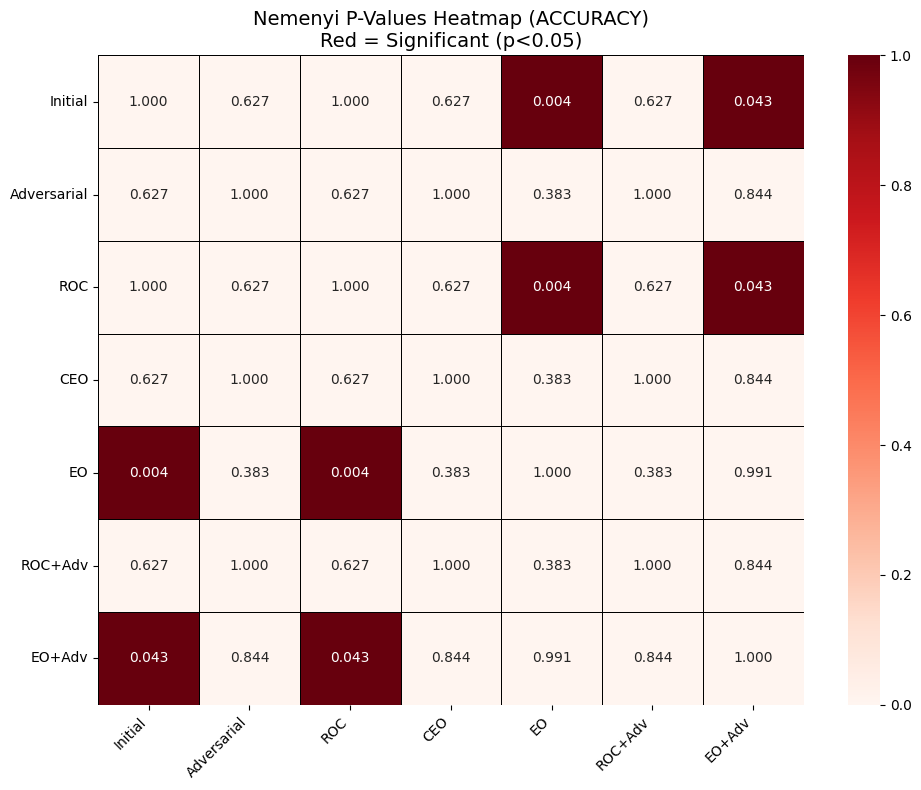


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(29.127272727272732), pvalue=np.float64(5.755386316475225e-05))


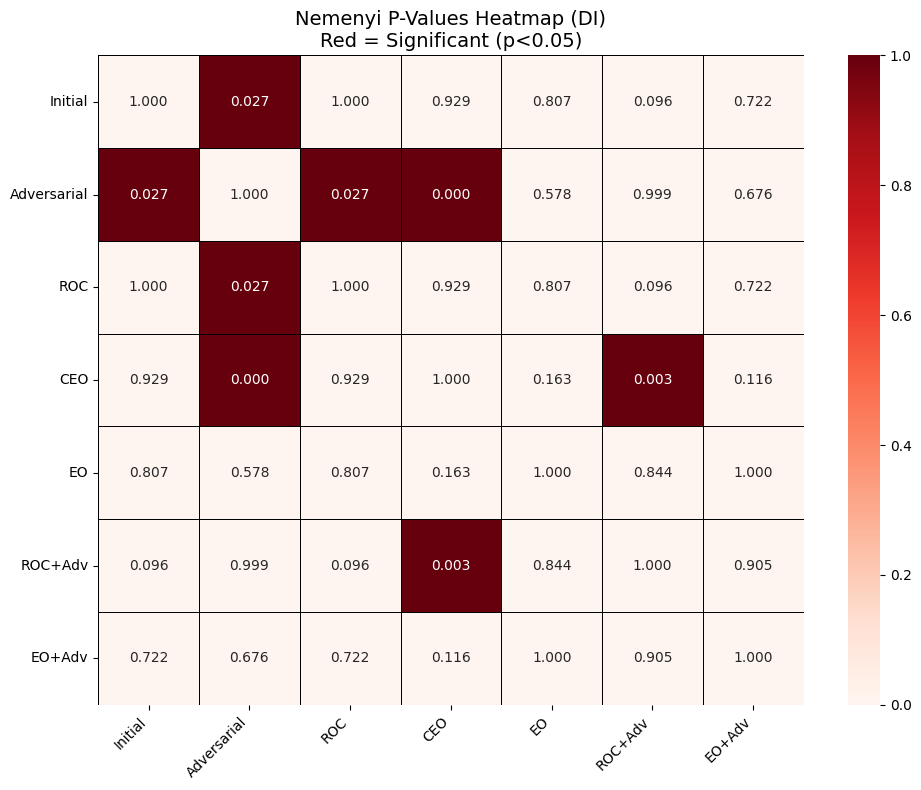


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(25.810909090909085), pvalue=np.float64(0.00024144205677553913))


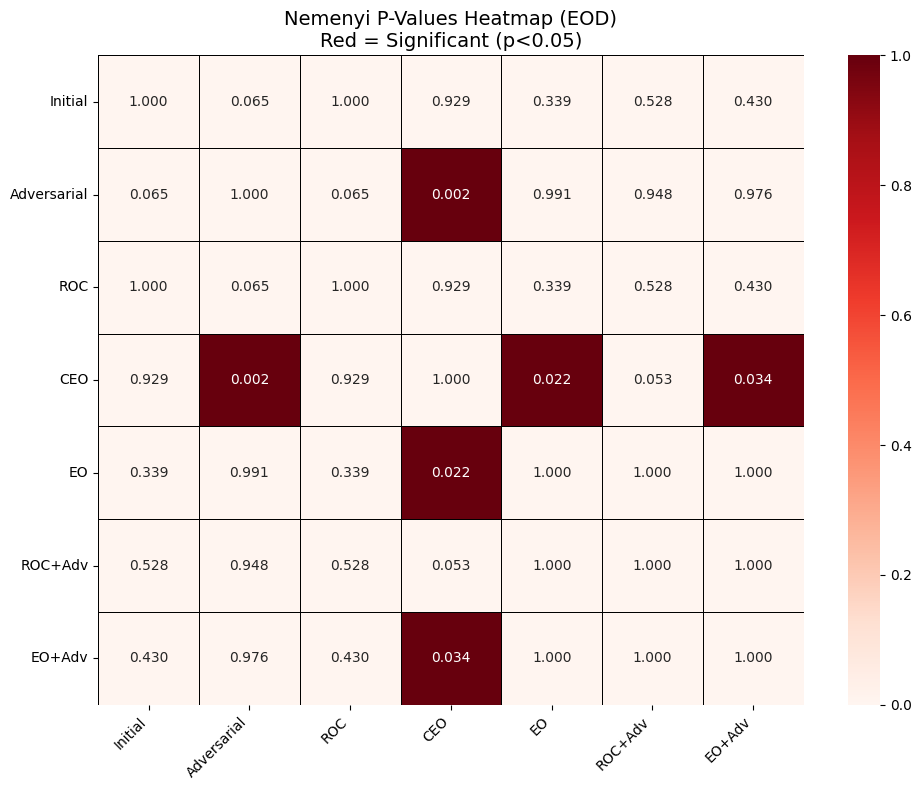


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(28.516363636363646), pvalue=np.float64(7.509090254705034e-05))


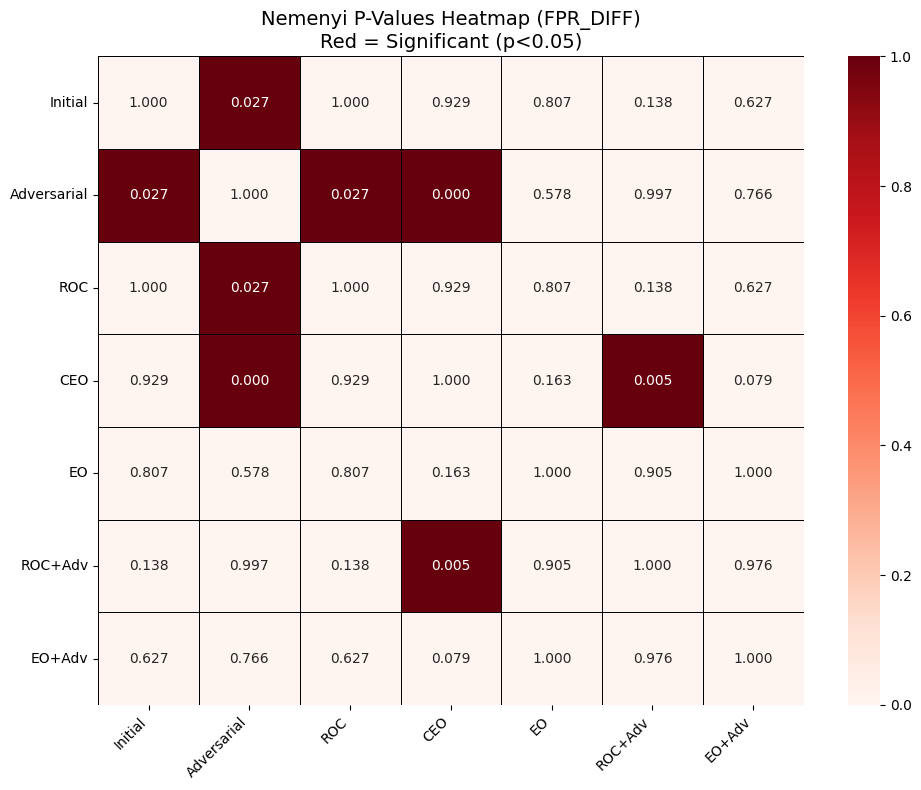

In [ ]:
res_xgb_race = run_fairness_pipeline("xgb", X, y, "race_African-American")

In [ ]:
res_xgb_race

{'Initial': {'accuracy': [0.6999306999306999,
   0.6701316701316701,
   0.6548856548856549,
   0.6618156618156619,
   0.6775312066574203],
  'di': [np.float64(0.4514573070607554),
   np.float64(0.4662818012587536),
   np.float64(0.4940852702428826),
   np.float64(0.46179823666734665),
   np.float64(0.44745835418602986)],
  'eod': [np.float64(-0.29225286975824905),
   np.float64(-0.32372316515539024),
   np.float64(-0.2752159035359296),
   np.float64(-0.3259790402647545),
   np.float64(-0.27823281211218664)],
  'fpr_diff': [np.float64(-0.1914066496163683),
   np.float64(-0.1857206689646368),
   np.float64(-0.2222507477247346),
   np.float64(-0.1614061735705275),
   np.float64(-0.21773241595200052)]},
 'Adversarial': {'accuracy': [0.6812196812196812,
   0.6576576576576577,
   0.65003465003465,
   0.656964656964657,
   0.6643550624133149],
  'di': [np.float64(0.9652279564915528),
   np.float64(1.1083216045038704),
   np.float64(1.0245376773730852),
   np.float64(0.9270603610226251),
   np

### SVC

epoch 0; iter: 0; batch classifier loss: 0.723611; batch adversarial loss: 0.757135
epoch 1; iter: 0; batch classifier loss: 0.665297; batch adversarial loss: 0.841502
epoch 2; iter: 0; batch classifier loss: 0.706221; batch adversarial loss: 0.821271
epoch 3; iter: 0; batch classifier loss: 0.643227; batch adversarial loss: 0.864831
epoch 4; iter: 0; batch classifier loss: 0.756153; batch adversarial loss: 0.833498
epoch 5; iter: 0; batch classifier loss: 0.630279; batch adversarial loss: 0.829269
epoch 6; iter: 0; batch classifier loss: 0.602855; batch adversarial loss: 0.793796
epoch 7; iter: 0; batch classifier loss: 0.595448; batch adversarial loss: 0.780531
epoch 8; iter: 0; batch classifier loss: 0.715551; batch adversarial loss: 0.775420
epoch 9; iter: 0; batch classifier loss: 0.645781; batch adversarial loss: 0.747616
epoch 10; iter: 0; batch classifier loss: 0.630679; batch adversarial loss: 0.737437
epoch 11; iter: 0; batch classifier loss: 0.658065; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.698837; batch adversarial loss: 0.690130
epoch 1; iter: 0; batch classifier loss: 0.633583; batch adversarial loss: 0.681231
epoch 2; iter: 0; batch classifier loss: 0.582467; batch adversarial loss: 0.680858
epoch 3; iter: 0; batch classifier loss: 0.613304; batch adversarial loss: 0.674736
epoch 4; iter: 0; batch classifier loss: 0.628375; batch adversarial loss: 0.704137
epoch 5; iter: 0; batch classifier loss: 0.650491; batch adversarial loss: 0.705550
epoch 6; iter: 0; batch classifier loss: 0.613258; batch adversarial loss: 0.690585
epoch 7; iter: 0; batch classifier loss: 0.623434; batch adversarial loss: 0.681753
epoch 8; iter: 0; batch classifier loss: 0.584962; batch adversarial loss: 0.689166
epoch 9; iter: 0; batch classifier loss: 0.634887; batch adversarial loss: 0.672456
epoch 10; iter: 0; batch classifier loss: 0.608617; batch adversarial loss: 0.700685
epoch 11; iter: 0; batch classifier loss: 0.574614; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.958446; batch adversarial loss: 0.715332
epoch 1; iter: 0; batch classifier loss: 0.648386; batch adversarial loss: 0.707500
epoch 2; iter: 0; batch classifier loss: 0.668857; batch adversarial loss: 0.716689
epoch 3; iter: 0; batch classifier loss: 0.592021; batch adversarial loss: 0.720148
epoch 4; iter: 0; batch classifier loss: 0.632699; batch adversarial loss: 0.693130
epoch 5; iter: 0; batch classifier loss: 0.648811; batch adversarial loss: 0.698306
epoch 6; iter: 0; batch classifier loss: 0.610677; batch adversarial loss: 0.712407
epoch 7; iter: 0; batch classifier loss: 0.601761; batch adversarial loss: 0.700621
epoch 8; iter: 0; batch classifier loss: 0.606274; batch adversarial loss: 0.681368
epoch 9; iter: 0; batch classifier loss: 0.658831; batch adversarial loss: 0.703076
epoch 10; iter: 0; batch classifier loss: 0.618011; batch adversarial loss: 0.714912
epoch 11; iter: 0; batch classifier loss: 0.617750; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.679839; batch adversarial loss: 0.728910
epoch 1; iter: 0; batch classifier loss: 0.642060; batch adversarial loss: 0.694207
epoch 2; iter: 0; batch classifier loss: 0.623439; batch adversarial loss: 0.685129
epoch 3; iter: 0; batch classifier loss: 0.643340; batch adversarial loss: 0.742166
epoch 4; iter: 0; batch classifier loss: 0.662916; batch adversarial loss: 0.700753
epoch 5; iter: 0; batch classifier loss: 0.645413; batch adversarial loss: 0.721762
epoch 6; iter: 0; batch classifier loss: 0.566246; batch adversarial loss: 0.648509
epoch 7; iter: 0; batch classifier loss: 0.607902; batch adversarial loss: 0.706754
epoch 8; iter: 0; batch classifier loss: 0.550618; batch adversarial loss: 0.656766
epoch 9; iter: 0; batch classifier loss: 0.579861; batch adversarial loss: 0.715477
epoch 10; iter: 0; batch classifier loss: 0.636214; batch adversarial loss: 0.720560
epoch 11; iter: 0; batch classifier loss: 0.588887; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.708262; batch adversarial loss: 0.698653
epoch 1; iter: 0; batch classifier loss: 0.630238; batch adversarial loss: 0.746064
epoch 2; iter: 0; batch classifier loss: 0.593600; batch adversarial loss: 0.689643
epoch 3; iter: 0; batch classifier loss: 0.588444; batch adversarial loss: 0.703318
epoch 4; iter: 0; batch classifier loss: 0.554593; batch adversarial loss: 0.720342
epoch 5; iter: 0; batch classifier loss: 0.625790; batch adversarial loss: 0.701357
epoch 6; iter: 0; batch classifier loss: 0.605596; batch adversarial loss: 0.706263
epoch 7; iter: 0; batch classifier loss: 0.669057; batch adversarial loss: 0.701915
epoch 8; iter: 0; batch classifier loss: 0.625302; batch adversarial loss: 0.700686
epoch 9; iter: 0; batch classifier loss: 0.643421; batch adversarial loss: 0.695902
epoch 10; iter: 0; batch classifier loss: 0.617297; batch adversarial loss: 0.730114
epoch 11; iter: 0; batch classifier loss: 0.616297; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.670 (95% CI: 0.660-0.682)
  DI:       0.447 (95% CI: 0.416-0.475)
  EOD:      -0.275 (95% CI: -0.325--0.224)
  FPR Diff: -0.178 (95% CI: -0.187--0.168)

Adversarial:
  Accuracy: 0.662 (95% CI: 0.652-0.675)
  DI:       1.027 (95% CI: 0.942-1.124)
  EOD:      0.031 (95% CI: -0.021-0.087)
  FPR Diff: 0.059 (95% CI: 0.027-0.083)

ROC:
  Accuracy: 0.670 (95% CI: 0.661-0.683)
  DI:       0.447 (95% CI: 0.418-0.475)
  EOD:      -0.275 (95% CI: -0.327--0.224)
  FPR Diff: -0.178 (95% CI: -0.187--0.168)

CEO:
  Accuracy: 0.660 (95% CI: 0.647-0.676)
  DI:       0.353 (95% CI: 0.289-0.409)
  EOD:      -0.365 (95% CI: -0.407--0.323)
  FPR Diff: -0.267 (95% CI: -0.305--0.232)

EO:
  Accuracy: 0.623 (95% CI: 0.614-0.630)
  DI:       0.907 (95% CI: 0.891-0.922)
  EOD:      -0.001 (95% CI: -0.012-0.011)
  FPR Diff: -0.002 (95% CI: -0.011-0.008)

ROC+Adv:
  Accuracy: 0.663 (95% CI: 0.654-0.673)
  DI:       0.973 (95% CI: 0.950-1

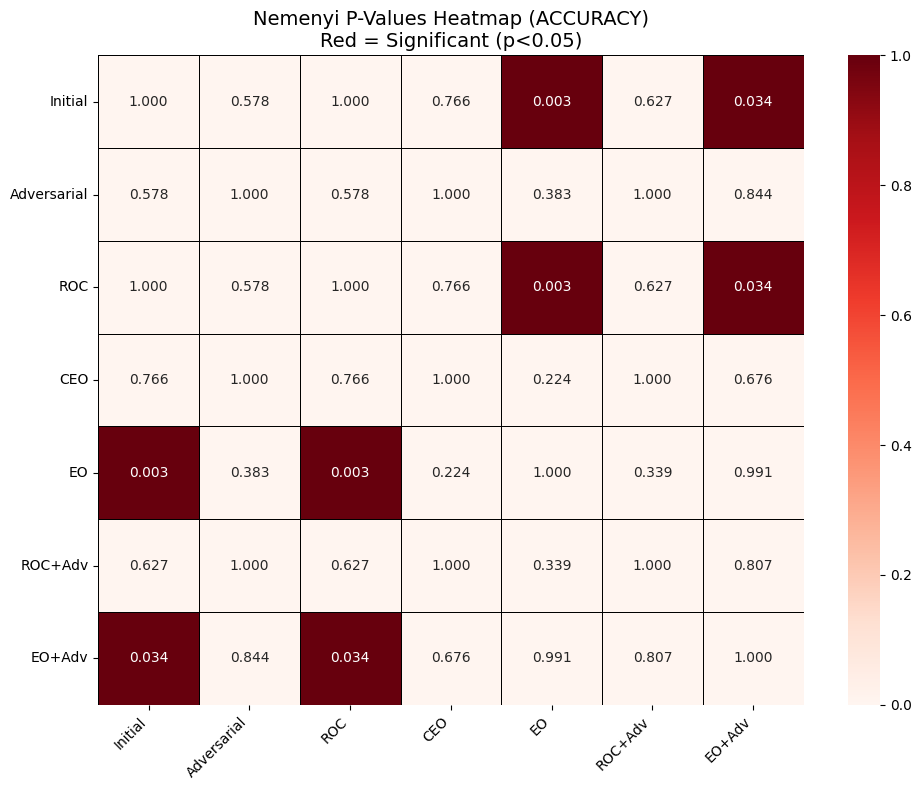


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(28.167272727272724), pvalue=np.float64(8.738587179542868e-05))


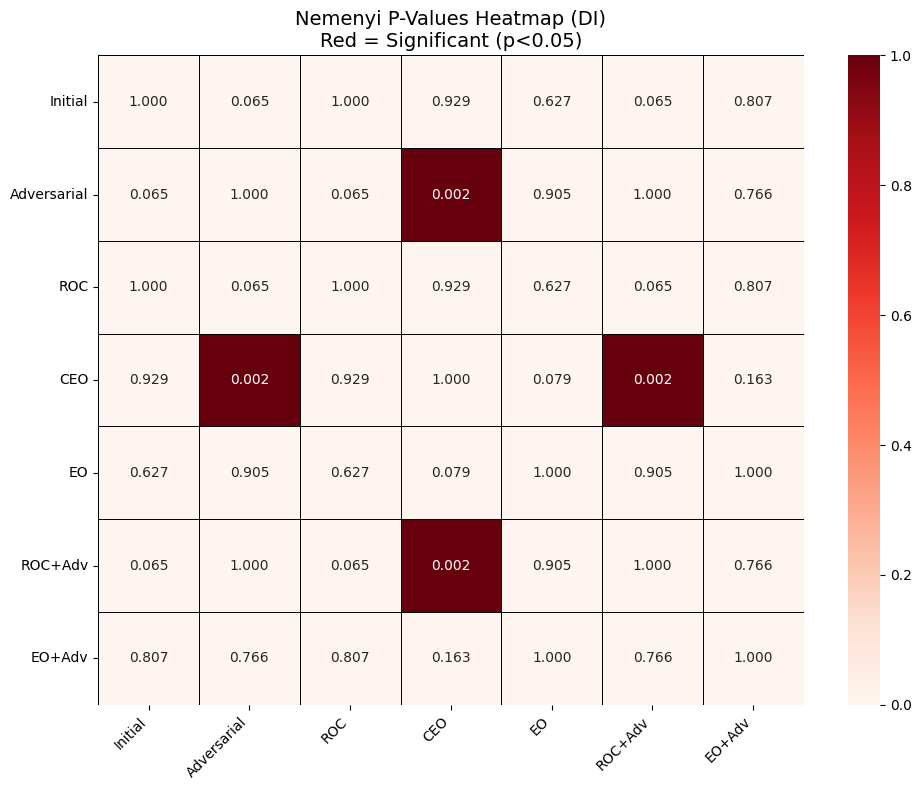


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(25.11272727272727), pvalue=np.float64(0.0003254271356159952))


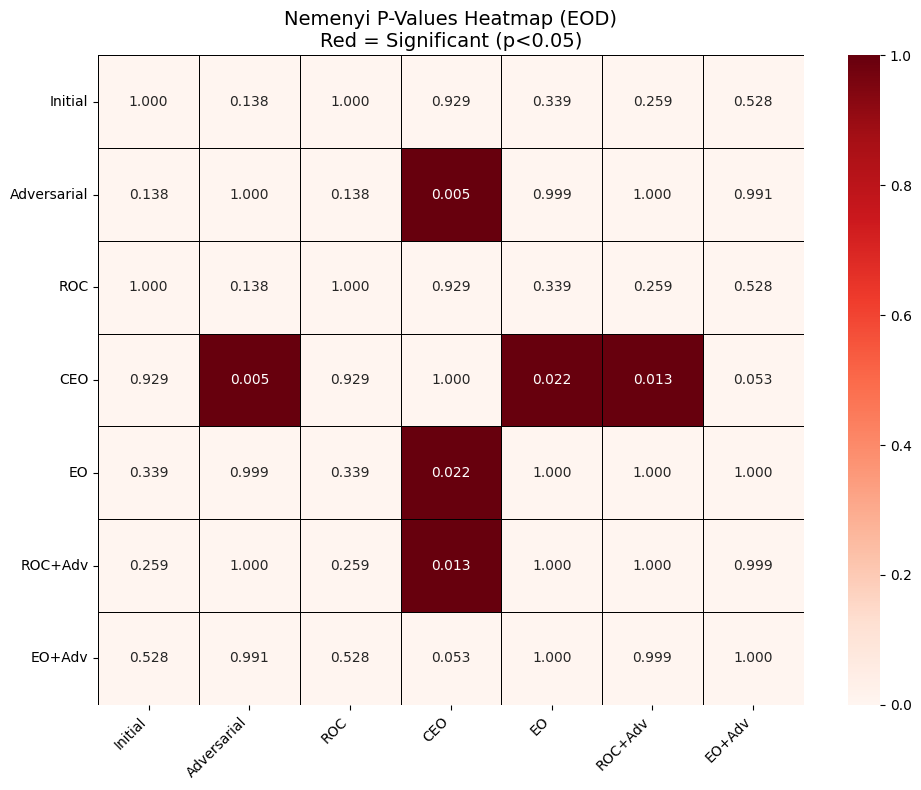


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(28.773722627737243), pvalue=np.float64(6.71376441846229e-05))


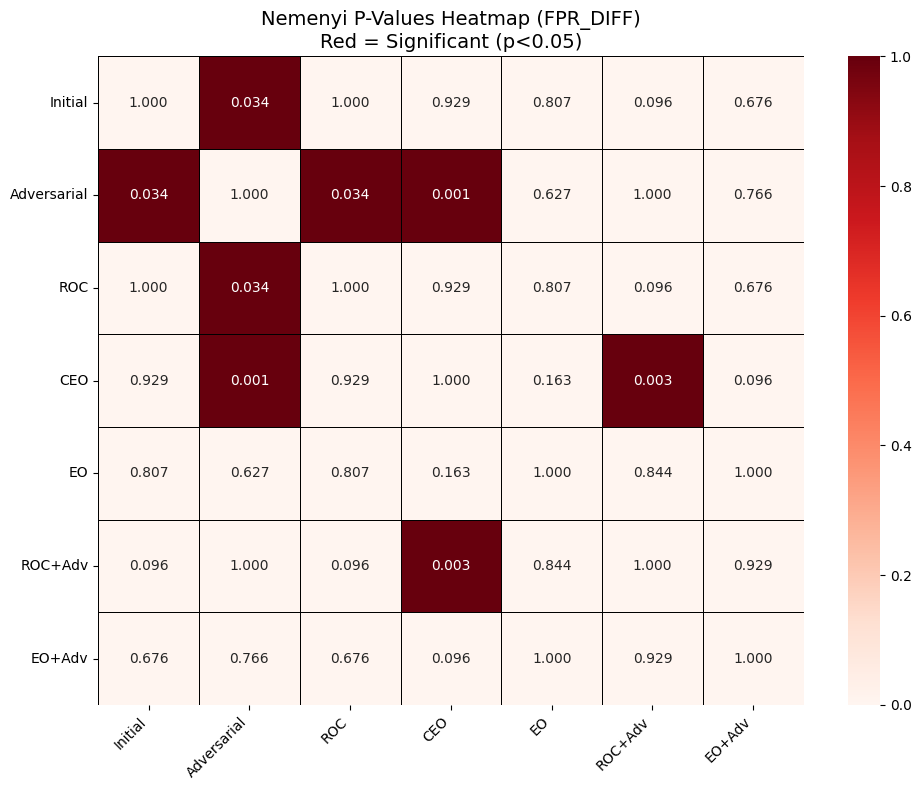

In [ ]:
res_svc_race = run_fairness_pipeline("svc", X, y, "race_African-American")

In [ ]:
res_svc_race

{'Initial': {'accuracy': [0.6909216909216909,
   0.6777546777546778,
   0.6548856548856549,
   0.6604296604296604,
   0.6678224687933426],
  'di': [np.float64(0.4608416130917592),
   np.float64(0.43221109040074557),
   np.float64(0.49332907756144273),
   np.float64(0.3904712711530893),
   np.float64(0.4560747663551402)],
  'eod': [np.float64(-0.26584817299360336),
   np.float64(-0.32407192125862205),
   np.float64(-0.21701540319565993),
   np.float64(-0.36107280750137893),
   np.float64(-0.2088359394390668)],
  'fpr_diff': [np.float64(-0.1770907928388747),
   np.float64(-0.18956338567598618),
   np.float64(-0.19033926806413104),
   np.float64(-0.1586772391421878),
   np.float64(-0.1749763589526201)]},
 'Adversarial': {'accuracy': [0.6853776853776854,
   0.659043659043659,
   0.6465696465696466,
   0.6534996534996536,
   0.6636615811373093],
  'di': [np.float64(0.9009773959174259),
   np.float64(1.0644058136221146),
   np.float64(1.1702392106621795),
   np.float64(0.940527726242012),
  

### Logistic Regression

epoch 0; iter: 0; batch classifier loss: 0.727828; batch adversarial loss: 0.700450
epoch 1; iter: 0; batch classifier loss: 0.621778; batch adversarial loss: 0.689734
epoch 2; iter: 0; batch classifier loss: 0.649876; batch adversarial loss: 0.685396
epoch 3; iter: 0; batch classifier loss: 0.655288; batch adversarial loss: 0.689952
epoch 4; iter: 0; batch classifier loss: 0.628891; batch adversarial loss: 0.696576
epoch 5; iter: 0; batch classifier loss: 0.560995; batch adversarial loss: 0.692071
epoch 6; iter: 0; batch classifier loss: 0.635246; batch adversarial loss: 0.675843
epoch 7; iter: 0; batch classifier loss: 0.638122; batch adversarial loss: 0.690597
epoch 8; iter: 0; batch classifier loss: 0.649104; batch adversarial loss: 0.689244
epoch 9; iter: 0; batch classifier loss: 0.603109; batch adversarial loss: 0.686876
epoch 10; iter: 0; batch classifier loss: 0.639920; batch adversarial loss: 0.688100
epoch 11; iter: 0; batch classifier loss: 0.581471; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.698837; batch adversarial loss: 0.690130
epoch 1; iter: 0; batch classifier loss: 0.633583; batch adversarial loss: 0.681231
epoch 2; iter: 0; batch classifier loss: 0.582467; batch adversarial loss: 0.680858
epoch 3; iter: 0; batch classifier loss: 0.613304; batch adversarial loss: 0.674736
epoch 4; iter: 0; batch classifier loss: 0.628375; batch adversarial loss: 0.704137
epoch 5; iter: 0; batch classifier loss: 0.650491; batch adversarial loss: 0.705550
epoch 6; iter: 0; batch classifier loss: 0.613258; batch adversarial loss: 0.690585
epoch 7; iter: 0; batch classifier loss: 0.623434; batch adversarial loss: 0.681753
epoch 8; iter: 0; batch classifier loss: 0.584962; batch adversarial loss: 0.689166
epoch 9; iter: 0; batch classifier loss: 0.634887; batch adversarial loss: 0.672456
epoch 10; iter: 0; batch classifier loss: 0.608617; batch adversarial loss: 0.700685
epoch 11; iter: 0; batch classifier loss: 0.574614; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.829017; batch adversarial loss: 0.702037
epoch 1; iter: 0; batch classifier loss: 0.663808; batch adversarial loss: 0.749202
epoch 2; iter: 0; batch classifier loss: 0.577330; batch adversarial loss: 0.727008
epoch 3; iter: 0; batch classifier loss: 0.589909; batch adversarial loss: 0.754806
epoch 4; iter: 0; batch classifier loss: 0.646681; batch adversarial loss: 0.755559
epoch 5; iter: 0; batch classifier loss: 0.612740; batch adversarial loss: 0.736418
epoch 6; iter: 0; batch classifier loss: 0.627420; batch adversarial loss: 0.741134
epoch 7; iter: 0; batch classifier loss: 0.574839; batch adversarial loss: 0.720397
epoch 8; iter: 0; batch classifier loss: 0.609071; batch adversarial loss: 0.720720
epoch 9; iter: 0; batch classifier loss: 0.582011; batch adversarial loss: 0.701699
epoch 10; iter: 0; batch classifier loss: 0.552637; batch adversarial loss: 0.704255
epoch 11; iter: 0; batch classifier loss: 0.563921; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.686533; batch adversarial loss: 0.664770
epoch 1; iter: 0; batch classifier loss: 0.623803; batch adversarial loss: 0.711528
epoch 2; iter: 0; batch classifier loss: 0.621077; batch adversarial loss: 0.725471
epoch 3; iter: 0; batch classifier loss: 0.555666; batch adversarial loss: 0.687602
epoch 4; iter: 0; batch classifier loss: 0.631129; batch adversarial loss: 0.692788
epoch 5; iter: 0; batch classifier loss: 0.598105; batch adversarial loss: 0.679293
epoch 6; iter: 0; batch classifier loss: 0.624723; batch adversarial loss: 0.658054
epoch 7; iter: 0; batch classifier loss: 0.525042; batch adversarial loss: 0.677206
epoch 8; iter: 0; batch classifier loss: 0.589602; batch adversarial loss: 0.641370
epoch 9; iter: 0; batch classifier loss: 0.621202; batch adversarial loss: 0.683022
epoch 10; iter: 0; batch classifier loss: 0.572200; batch adversarial loss: 0.686915
epoch 11; iter: 0; batch classifier loss: 0.563108; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.721570; batch adversarial loss: 0.721247
epoch 1; iter: 0; batch classifier loss: 0.645450; batch adversarial loss: 0.676143
epoch 2; iter: 0; batch classifier loss: 0.631600; batch adversarial loss: 0.728846
epoch 3; iter: 0; batch classifier loss: 0.651297; batch adversarial loss: 0.701778
epoch 4; iter: 0; batch classifier loss: 0.657512; batch adversarial loss: 0.711901
epoch 5; iter: 0; batch classifier loss: 0.633851; batch adversarial loss: 0.718565
epoch 6; iter: 0; batch classifier loss: 0.667749; batch adversarial loss: 0.717662
epoch 7; iter: 0; batch classifier loss: 0.643665; batch adversarial loss: 0.713718
epoch 8; iter: 0; batch classifier loss: 0.667515; batch adversarial loss: 0.701179
epoch 9; iter: 0; batch classifier loss: 0.606921; batch adversarial loss: 0.696990
epoch 10; iter: 0; batch classifier loss: 0.638434; batch adversarial loss: 0.698809
epoch 11; iter: 0; batch classifier loss: 0.636483; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.675 (95% CI: 0.665-0.685)
  DI:       0.408 (95% CI: 0.396-0.421)
  EOD:      -0.304 (95% CI: -0.334--0.281)
  FPR Diff: -0.194 (95% CI: -0.211--0.170)

Adversarial:
  Accuracy: 0.664 (95% CI: 0.652-0.677)
  DI:       1.034 (95% CI: 0.933-1.145)
  EOD:      0.032 (95% CI: -0.029-0.094)
  FPR Diff: 0.058 (95% CI: 0.039-0.077)

ROC:
  Accuracy: 0.675 (95% CI: 0.665-0.685)
  DI:       0.408 (95% CI: 0.397-0.422)
  EOD:      -0.304 (95% CI: -0.333--0.280)
  FPR Diff: -0.194 (95% CI: -0.211--0.171)

CEO:
  Accuracy: 0.661 (95% CI: 0.650-0.672)
  DI:       0.273 (95% CI: 0.207-0.336)
  EOD:      -0.416 (95% CI: -0.467--0.367)
  FPR Diff: -0.257 (95% CI: -0.273--0.240)

EO:
  Accuracy: 0.621 (95% CI: 0.608-0.639)
  DI:       0.905 (95% CI: 0.890-0.920)
  EOD:      -0.006 (95% CI: -0.011-0.001)
  FPR Diff: 0.001 (95% CI: -0.007-0.008)

ROC+Adv:
  Accuracy: 0.664 (95% CI: 0.657-0.670)
  DI:       0.955 (95% CI: 0.916-0.

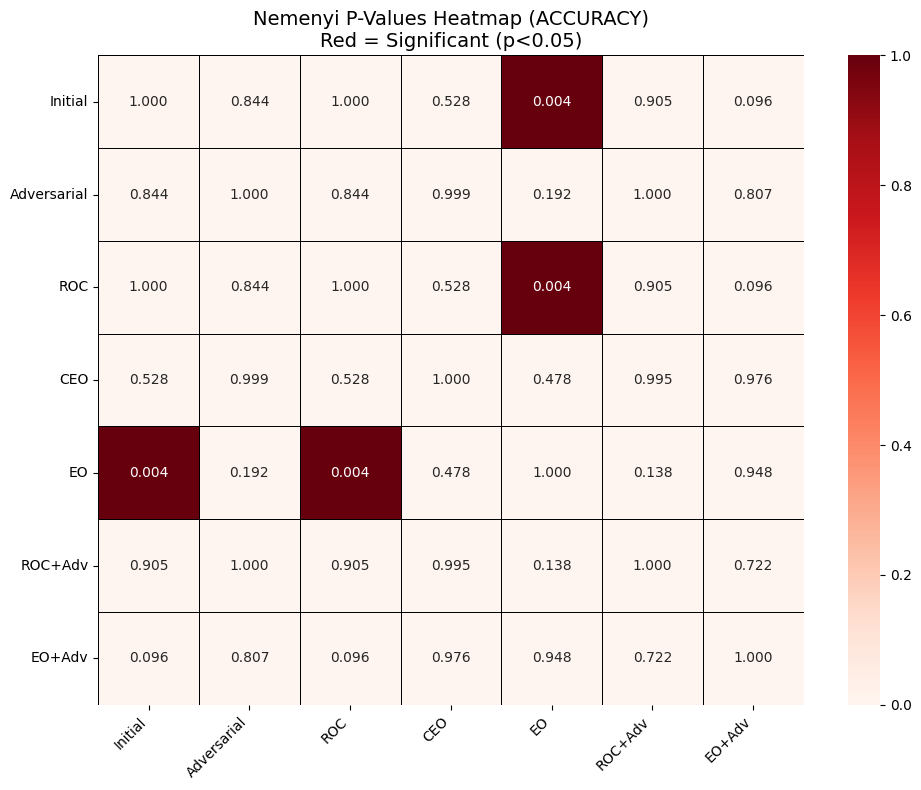


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(26.160000000000007), pvalue=np.float64(0.0002078684914616926))


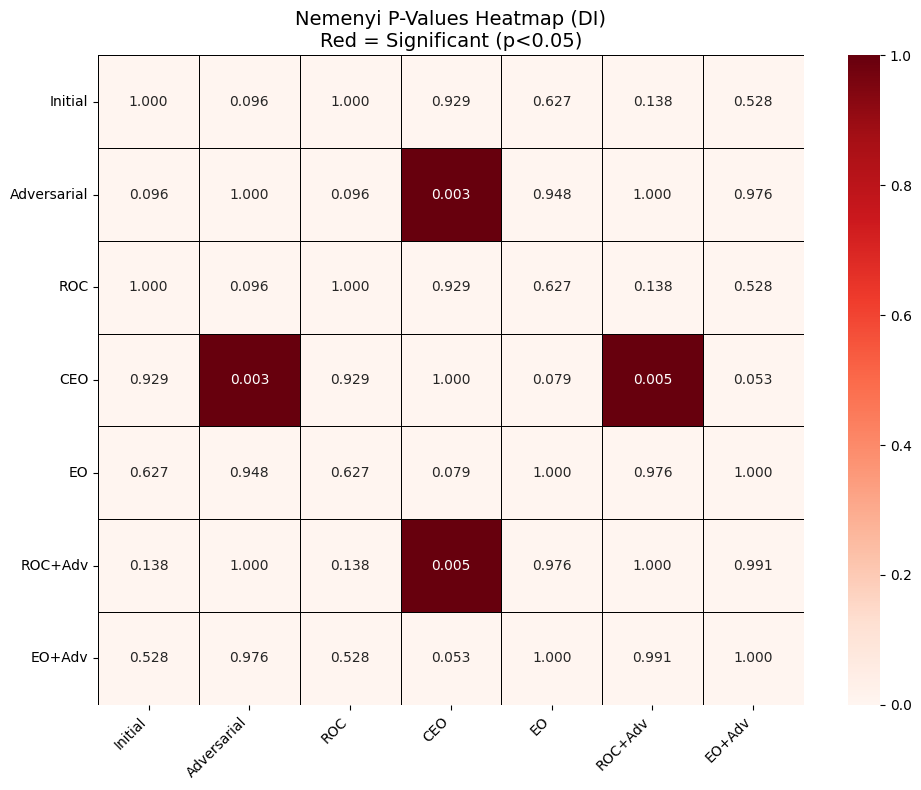


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(25.636363636363626), pvalue=np.float64(0.00026018048865346697))


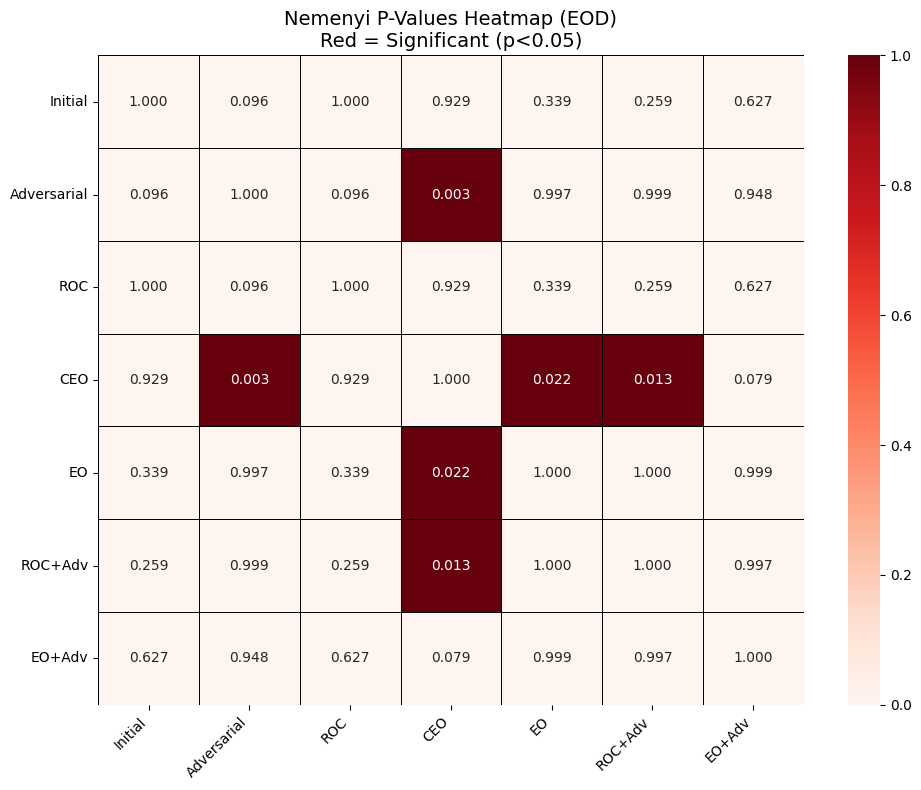


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(28.516363636363646), pvalue=np.float64(7.509090254705034e-05))


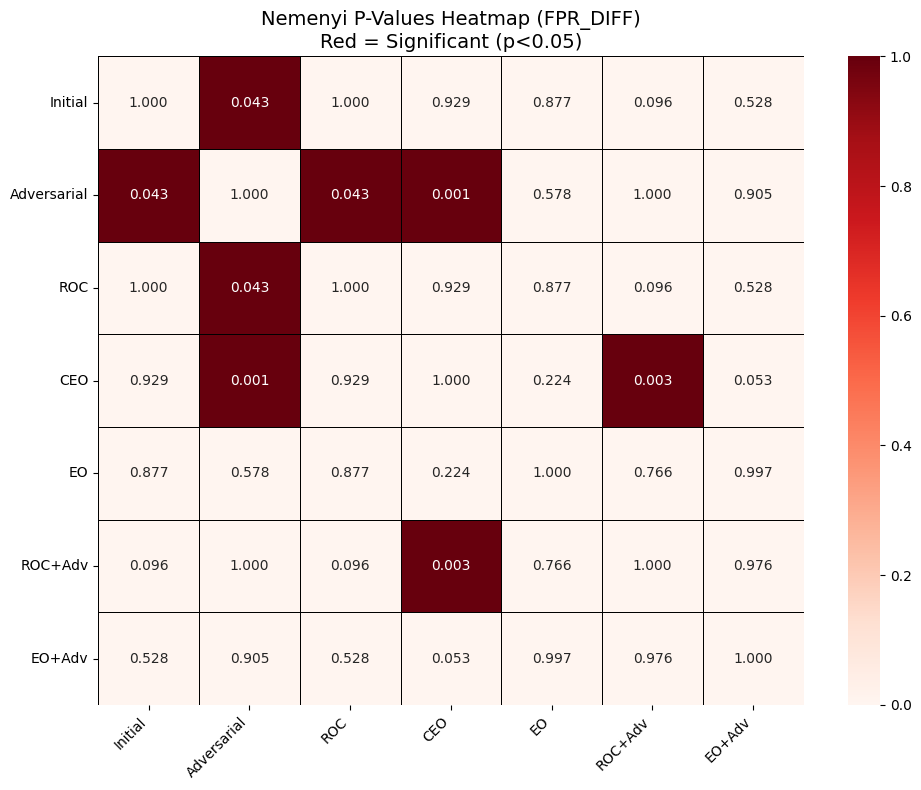

In [ ]:
res_lr_race = run_fairness_pipeline("lr", X, y, "race_African-American")

In [ ]:
res_lr_race

{'Initial': {'accuracy': [0.6916146916146916,
   0.6812196812196812,
   0.6618156618156619,
   0.6611226611226612,
   0.680998613037448],
  'di': [np.float64(0.41721709567751336),
   np.float64(0.39705002989834565),
   np.float64(0.43172714844218457),
   np.float64(0.39184952978056425),
   np.float64(0.4014202864244289)],
  'eod': [np.float64(-0.29431695372362693),
   np.float64(-0.30837789661319076),
   np.float64(-0.28832826922523946),
   np.float64(-0.36238279095421955),
   np.float64(-0.2682055100521222)],
  'fpr_diff': [np.float64(-0.1935613810741688),
   np.float64(-0.19846801991574112),
   np.float64(-0.21069791920721925),
   np.float64(-0.15029735087403134),
   np.float64(-0.21640851729872504)]},
 'Adversarial': {'accuracy': [0.6874566874566874,
   0.659043659043659,
   0.6424116424116424,
   0.6632016632016632,
   0.665742024965326],
  'di': [np.float64(0.9386616014026885),
   np.float64(1.0644058136221146),
   np.float64(1.241134026940294),
   np.float64(0.8614573831965135),


### GBDT

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


epoch 0; iter: 0; batch classifier loss: 0.736035; batch adversarial loss: 0.768729
epoch 1; iter: 0; batch classifier loss: 0.654460; batch adversarial loss: 0.989878
epoch 2; iter: 0; batch classifier loss: 0.608278; batch adversarial loss: 0.954541
epoch 3; iter: 0; batch classifier loss: 0.664836; batch adversarial loss: 0.898703
epoch 4; iter: 0; batch classifier loss: 0.704388; batch adversarial loss: 0.842829
epoch 5; iter: 0; batch classifier loss: 0.664006; batch adversarial loss: 0.850258
epoch 6; iter: 0; batch classifier loss: 0.755152; batch adversarial loss: 0.788481
epoch 7; iter: 0; batch classifier loss: 0.637251; batch adversarial loss: 0.818495
epoch 8; iter: 0; batch classifier loss: 0.644587; batch adversarial loss: 0.807898
epoch 9; iter: 0; batch classifier loss: 0.635357; batch adversarial loss: 0.823954
epoch 10; iter: 0; batch classifier loss: 0.639356; batch adversarial loss: 0.774864
epoch 11; iter: 0; batch classifier loss: 0.578391; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.690208; batch adversarial loss: 0.669525
epoch 1; iter: 0; batch classifier loss: 0.708399; batch adversarial loss: 0.786699
epoch 2; iter: 0; batch classifier loss: 0.622063; batch adversarial loss: 0.767300
epoch 3; iter: 0; batch classifier loss: 0.783064; batch adversarial loss: 0.782400
epoch 4; iter: 0; batch classifier loss: 0.677495; batch adversarial loss: 0.745454
epoch 5; iter: 0; batch classifier loss: 0.677862; batch adversarial loss: 0.751921
epoch 6; iter: 0; batch classifier loss: 0.610199; batch adversarial loss: 0.732776
epoch 7; iter: 0; batch classifier loss: 0.658100; batch adversarial loss: 0.719155
epoch 8; iter: 0; batch classifier loss: 0.613542; batch adversarial loss: 0.719832
epoch 9; iter: 0; batch classifier loss: 0.683601; batch adversarial loss: 0.735451
epoch 10; iter: 0; batch classifier loss: 0.649501; batch adversarial loss: 0.711809
epoch 11; iter: 0; batch classifier loss: 0.579988; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


...

epoch 0; iter: 0; batch classifier loss: 0.723701; batch adversarial loss: 0.808273
epoch 1; iter: 0; batch classifier loss: 0.702311; batch adversarial loss: 0.916825
epoch 2; iter: 0; batch classifier loss: 0.658913; batch adversarial loss: 0.891371
epoch 3; iter: 0; batch classifier loss: 0.626744; batch adversarial loss: 0.802355
epoch 4; iter: 0; batch classifier loss: 0.648235; batch adversarial loss: 0.824524
epoch 5; iter: 0; batch classifier loss: 0.591613; batch adversarial loss: 0.756502
epoch 6; iter: 0; batch classifier loss: 0.635106; batch adversarial loss: 0.733481
epoch 7; iter: 0; batch classifier loss: 0.580451; batch adversarial loss: 0.739947
epoch 8; iter: 0; batch classifier loss: 0.585547; batch adversarial loss: 0.743096
epoch 9; iter: 0; batch classifier loss: 0.614767; batch adversarial loss: 0.730182
epoch 10; iter: 0; batch classifier loss: 0.576897; batch adversarial loss: 0.687604
epoch 11; iter: 0; batch classifier loss: 0.552529; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.776053; batch adversarial loss: 0.683530
epoch 1; iter: 0; batch classifier loss: 0.631894; batch adversarial loss: 0.690488
epoch 2; iter: 0; batch classifier loss: 0.602463; batch adversarial loss: 0.689872
epoch 3; iter: 0; batch classifier loss: 0.608121; batch adversarial loss: 0.691359
epoch 4; iter: 0; batch classifier loss: 0.652715; batch adversarial loss: 0.657296
epoch 5; iter: 0; batch classifier loss: 0.563036; batch adversarial loss: 0.668837
epoch 6; iter: 0; batch classifier loss: 0.606392; batch adversarial loss: 0.694487
epoch 7; iter: 0; batch classifier loss: 0.601426; batch adversarial loss: 0.690057
epoch 8; iter: 0; batch classifier loss: 0.636271; batch adversarial loss: 0.689558
epoch 9; iter: 0; batch classifier loss: 0.567443; batch adversarial loss: 0.693003
epoch 10; iter: 0; batch classifier loss: 0.615529; batch adversarial loss: 0.693464
epoch 11; iter: 0; batch classifier loss: 0.625000; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.674 (95% CI: 0.661-0.687)
  DI:       0.476 (95% CI: 0.443-0.514)
  EOD:      -0.280 (95% CI: -0.337--0.222)
  FPR Diff: -0.183 (95% CI: -0.191--0.174)

Adversarial:
  Accuracy: 0.661 (95% CI: 0.652-0.673)
  DI:       0.979 (95% CI: 0.873-1.060)
  EOD:      0.015 (95% CI: -0.035-0.066)
  FPR Diff: 0.041 (95% CI: -0.001-0.077)

ROC:
  Accuracy: 0.674 (95% CI: 0.660-0.689)
  DI:       0.476 (95% CI: 0.443-0.519)
  EOD:      -0.280 (95% CI: -0.337--0.224)
  FPR Diff: -0.183 (95% CI: -0.192--0.173)

CEO:
  Accuracy: 0.664 (95% CI: 0.651-0.681)
  DI:       0.333 (95% CI: 0.256-0.401)
  EOD:      -0.389 (95% CI: -0.431--0.354)
  FPR Diff: -0.245 (95% CI: -0.264--0.228)

EO:
  Accuracy: 0.632 (95% CI: 0.617-0.648)
  DI:       0.911 (95% CI: 0.895-0.927)
  EOD:      -0.010 (95% CI: -0.023-0.002)
  FPR Diff: 0.008 (95% CI: -0.001-0.016)

ROC+Adv:
  Accuracy: 0.659 (95% CI: 0.648-0.670)
  DI:       0.954 (95% CI: 0.923-0

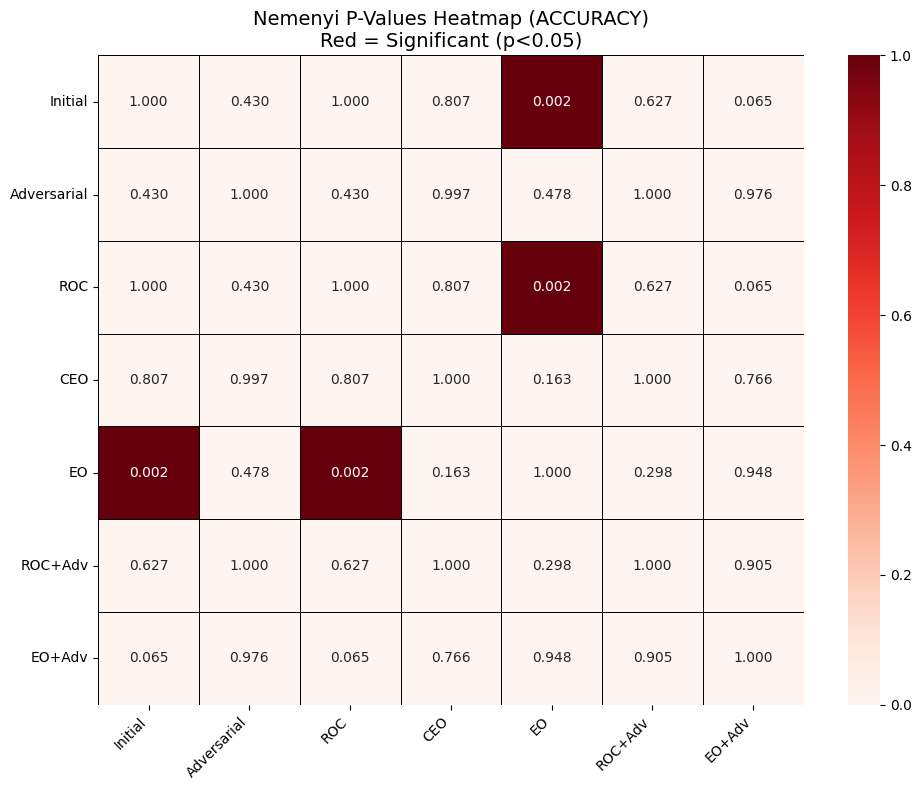


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(26.770909090909093), pvalue=np.float64(0.000159838618557839))


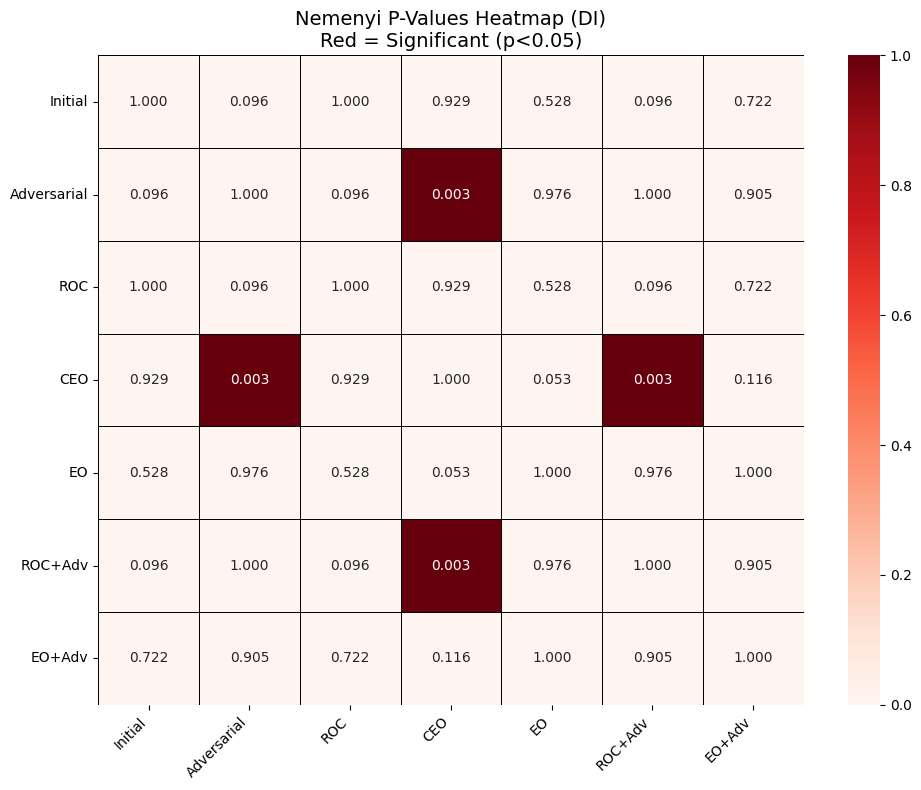


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(25.11272727272727), pvalue=np.float64(0.0003254271356159952))


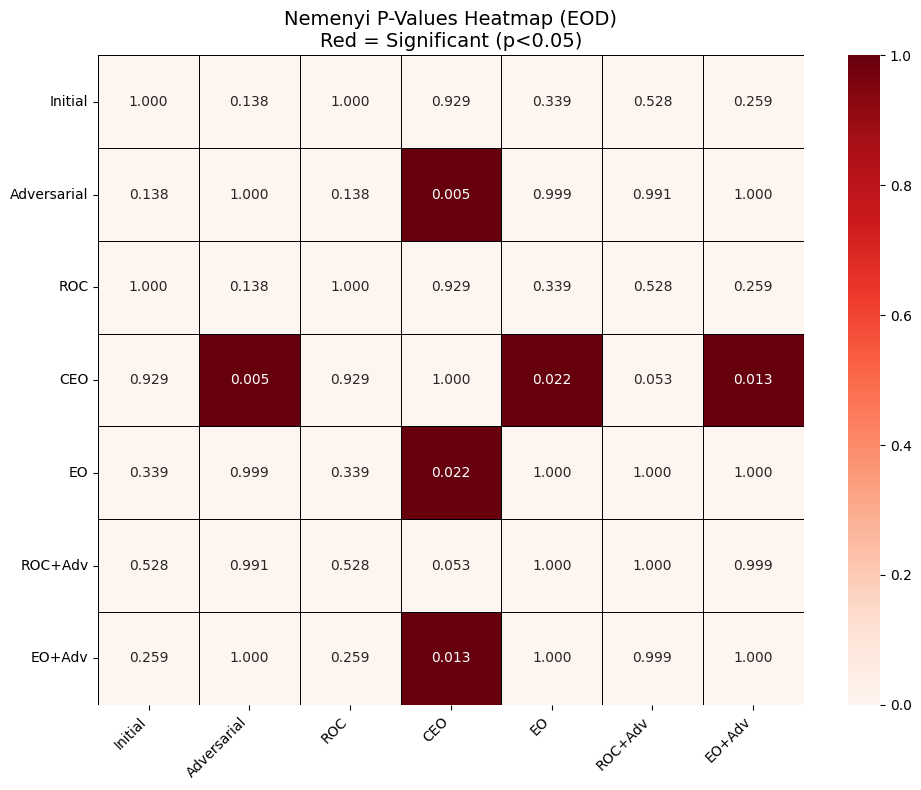


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(25.723636363636356), pvalue=np.float64(0.0002506386603752944))


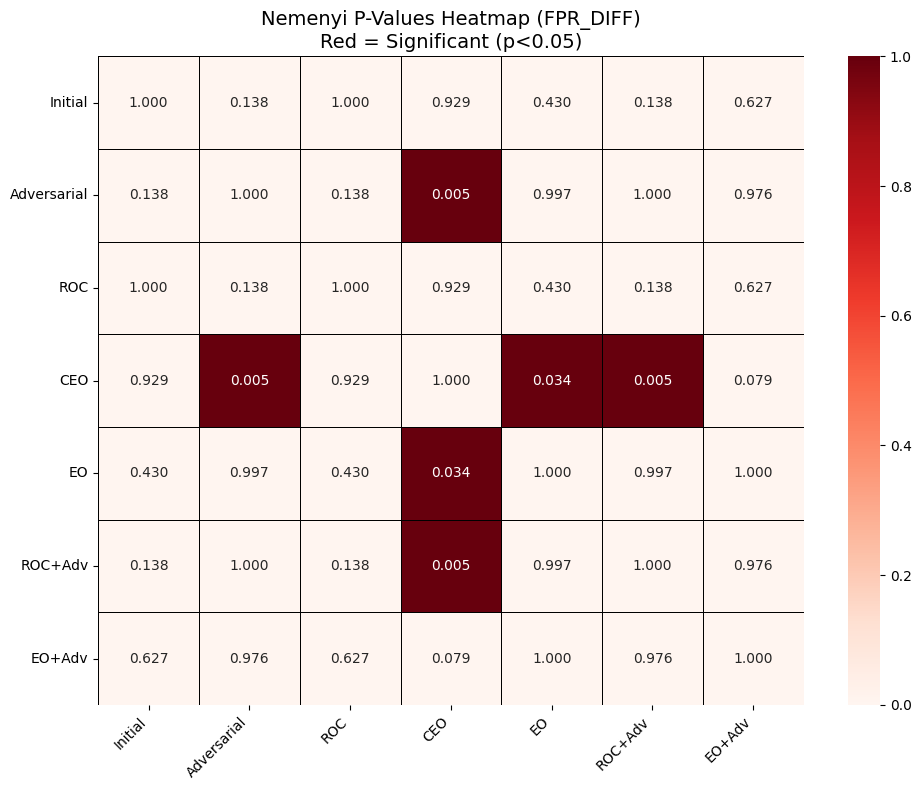

In [ ]:
res_gbc_race = run_fairness_pipeline("gbc", X, y, "race_African-American")

In [ ]:
res_gbc_race

{'Initial': {'accuracy': [0.7006237006237006,
   0.6701316701316701,
   0.6534996534996536,
   0.6618156618156619,
   0.6816920943134536],
  'di': [np.float64(0.4535365191420038),
   np.float64(0.4591850337717739),
   np.float64(0.5506468147424946),
   np.float64(0.4233676513469259),
   np.float64(0.4914836967007525)],
  'eod': [np.float64(-0.2875113183849517),
   np.float64(-0.3246725567697435),
   np.float64(-0.1914232859511737),
   np.float64(-0.3734831770546056),
   np.float64(-0.22065028543062798)],
  'fpr_diff': [np.float64(-0.19684143222506392),
   np.float64(-0.19048257372654157),
   np.float64(-0.18036532611067613),
   np.float64(-0.16552531987745542),
   np.float64(-0.18058499364137348)]},
 'Adversarial': {'accuracy': [0.683991683991684,
   0.6576576576576577,
   0.6514206514206514,
   0.6493416493416494,
   0.6622746185852982],
  'di': [np.float64(0.7707417264522101),
   np.float64(1.1083216045038704),
   np.float64(1.031701244813278),
   np.float64(0.9637006103437199),
   n

### RFC

epoch 0; iter: 0; batch classifier loss: 0.685393; batch adversarial loss: 0.713537
epoch 1; iter: 0; batch classifier loss: 0.649439; batch adversarial loss: 0.706416
epoch 2; iter: 0; batch classifier loss: 0.583522; batch adversarial loss: 0.709473
epoch 3; iter: 0; batch classifier loss: 0.602596; batch adversarial loss: 0.706535
epoch 4; iter: 0; batch classifier loss: 0.616161; batch adversarial loss: 0.702261
epoch 5; iter: 0; batch classifier loss: 0.622654; batch adversarial loss: 0.691573
epoch 6; iter: 0; batch classifier loss: 0.636627; batch adversarial loss: 0.699368
epoch 7; iter: 0; batch classifier loss: 0.555722; batch adversarial loss: 0.687850
epoch 8; iter: 0; batch classifier loss: 0.579533; batch adversarial loss: 0.690362
epoch 9; iter: 0; batch classifier loss: 0.607829; batch adversarial loss: 0.676419
epoch 10; iter: 0; batch classifier loss: 0.600447; batch adversarial loss: 0.679622
epoch 11; iter: 0; batch classifier loss: 0.587354; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.701454; batch adversarial loss: 0.863977
epoch 1; iter: 0; batch classifier loss: 0.689191; batch adversarial loss: 0.833830
epoch 2; iter: 0; batch classifier loss: 0.646573; batch adversarial loss: 0.881069
epoch 3; iter: 0; batch classifier loss: 0.615046; batch adversarial loss: 0.842642
epoch 4; iter: 0; batch classifier loss: 0.707248; batch adversarial loss: 0.751790
epoch 5; iter: 0; batch classifier loss: 0.653838; batch adversarial loss: 0.808285
epoch 6; iter: 0; batch classifier loss: 0.648206; batch adversarial loss: 0.765623
epoch 7; iter: 0; batch classifier loss: 0.601944; batch adversarial loss: 0.811841
epoch 8; iter: 0; batch classifier loss: 0.544467; batch adversarial loss: 0.824848
epoch 9; iter: 0; batch classifier loss: 0.577345; batch adversarial loss: 0.793269
epoch 10; iter: 0; batch classifier loss: 0.633827; batch adversarial loss: 0.735526
epoch 11; iter: 0; batch classifier loss: 0.609212; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.767014; batch adversarial loss: 0.692489
epoch 1; iter: 0; batch classifier loss: 0.689190; batch adversarial loss: 0.673840
epoch 2; iter: 0; batch classifier loss: 0.638145; batch adversarial loss: 0.704275
epoch 3; iter: 0; batch classifier loss: 0.590569; batch adversarial loss: 0.664534
epoch 4; iter: 0; batch classifier loss: 0.644206; batch adversarial loss: 0.669727
epoch 5; iter: 0; batch classifier loss: 0.658188; batch adversarial loss: 0.652086
epoch 6; iter: 0; batch classifier loss: 0.625356; batch adversarial loss: 0.653982
epoch 7; iter: 0; batch classifier loss: 0.580916; batch adversarial loss: 0.649911
epoch 8; iter: 0; batch classifier loss: 0.584721; batch adversarial loss: 0.658395
epoch 9; iter: 0; batch classifier loss: 0.585716; batch adversarial loss: 0.656882
epoch 10; iter: 0; batch classifier loss: 0.562507; batch adversarial loss: 0.688741
epoch 11; iter: 0; batch classifier loss: 0.537237; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.847489; batch adversarial loss: 0.696290
epoch 1; iter: 0; batch classifier loss: 0.596125; batch adversarial loss: 0.690433
epoch 2; iter: 0; batch classifier loss: 0.649324; batch adversarial loss: 0.682063
epoch 3; iter: 0; batch classifier loss: 0.624984; batch adversarial loss: 0.686672
epoch 4; iter: 0; batch classifier loss: 0.589108; batch adversarial loss: 0.686736
epoch 5; iter: 0; batch classifier loss: 0.595642; batch adversarial loss: 0.686997
epoch 6; iter: 0; batch classifier loss: 0.551208; batch adversarial loss: 0.698070
epoch 7; iter: 0; batch classifier loss: 0.607250; batch adversarial loss: 0.701185
epoch 8; iter: 0; batch classifier loss: 0.656560; batch adversarial loss: 0.691420
epoch 9; iter: 0; batch classifier loss: 0.648876; batch adversarial loss: 0.677833
epoch 10; iter: 0; batch classifier loss: 0.620865; batch adversarial loss: 0.690130
epoch 11; iter: 0; batch classifier loss: 0.587755; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.779876; batch adversarial loss: 0.710826
epoch 1; iter: 0; batch classifier loss: 0.615951; batch adversarial loss: 0.737846
epoch 2; iter: 0; batch classifier loss: 0.655159; batch adversarial loss: 0.755680
epoch 3; iter: 0; batch classifier loss: 0.606279; batch adversarial loss: 0.727418
epoch 4; iter: 0; batch classifier loss: 0.575186; batch adversarial loss: 0.713563
epoch 5; iter: 0; batch classifier loss: 0.623672; batch adversarial loss: 0.747498
epoch 6; iter: 0; batch classifier loss: 0.602250; batch adversarial loss: 0.711774
epoch 7; iter: 0; batch classifier loss: 0.615292; batch adversarial loss: 0.723073
epoch 8; iter: 0; batch classifier loss: 0.634308; batch adversarial loss: 0.715549
epoch 9; iter: 0; batch classifier loss: 0.586687; batch adversarial loss: 0.703043
epoch 10; iter: 0; batch classifier loss: 0.605748; batch adversarial loss: 0.710638
epoch 11; iter: 0; batch classifier loss: 0.619170; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.669 (95% CI: 0.654-0.686)
  DI:       0.450 (95% CI: 0.415-0.499)
  EOD:      -0.303 (95% CI: -0.358--0.248)
  FPR Diff: -0.197 (95% CI: -0.209--0.184)

Adversarial:
  Accuracy: 0.661 (95% CI: 0.650-0.676)
  DI:       1.080 (95% CI: 0.935-1.271)
  EOD:      0.046 (95% CI: -0.018-0.103)
  FPR Diff: 0.072 (95% CI: 0.031-0.121)

ROC:
  Accuracy: 0.669 (95% CI: 0.654-0.686)
  DI:       0.450 (95% CI: 0.415-0.499)
  EOD:      -0.303 (95% CI: -0.357--0.248)
  FPR Diff: -0.197 (95% CI: -0.209--0.185)

CEO:
  Accuracy: 0.659 (95% CI: 0.646-0.678)
  DI:       0.325 (95% CI: 0.253-0.388)
  EOD:      -0.399 (95% CI: -0.434--0.363)
  FPR Diff: -0.255 (95% CI: -0.273--0.237)

EO:
  Accuracy: 0.619 (95% CI: 0.605-0.637)
  DI:       0.915 (95% CI: 0.898-0.931)
  EOD:      0.002 (95% CI: -0.017-0.020)
  FPR Diff: -0.005 (95% CI: -0.018-0.007)

ROC+Adv:
  Accuracy: 0.661 (95% CI: 0.651-0.673)
  DI:       0.994 (95% CI: 0.918-1.

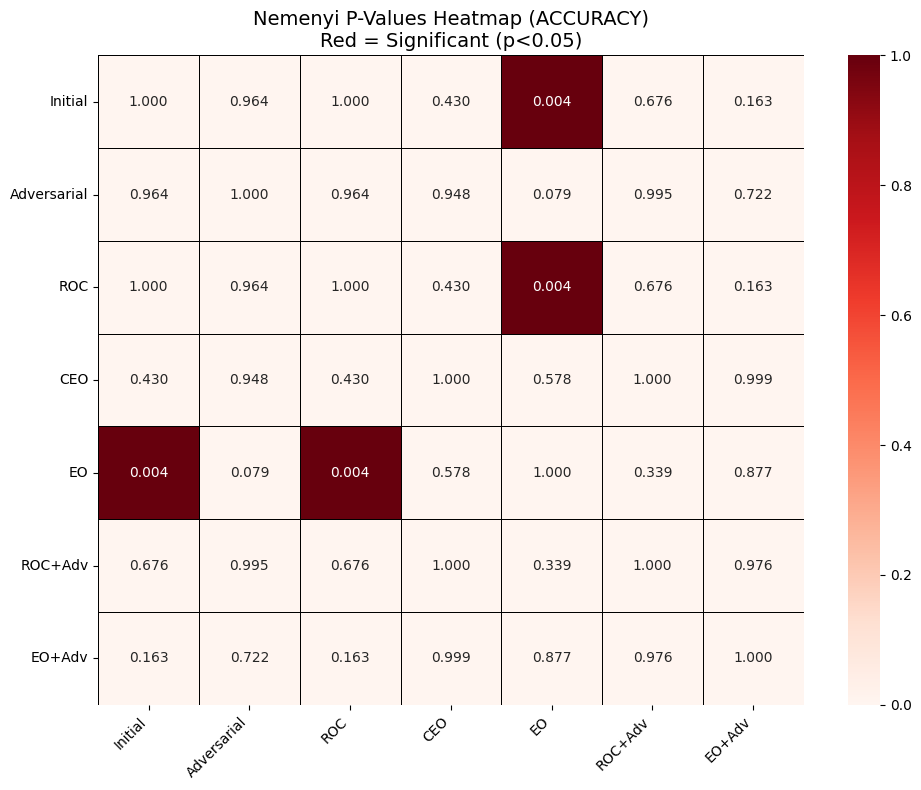


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(27.556363636363642), pvalue=np.float64(0.00011386957993938112))


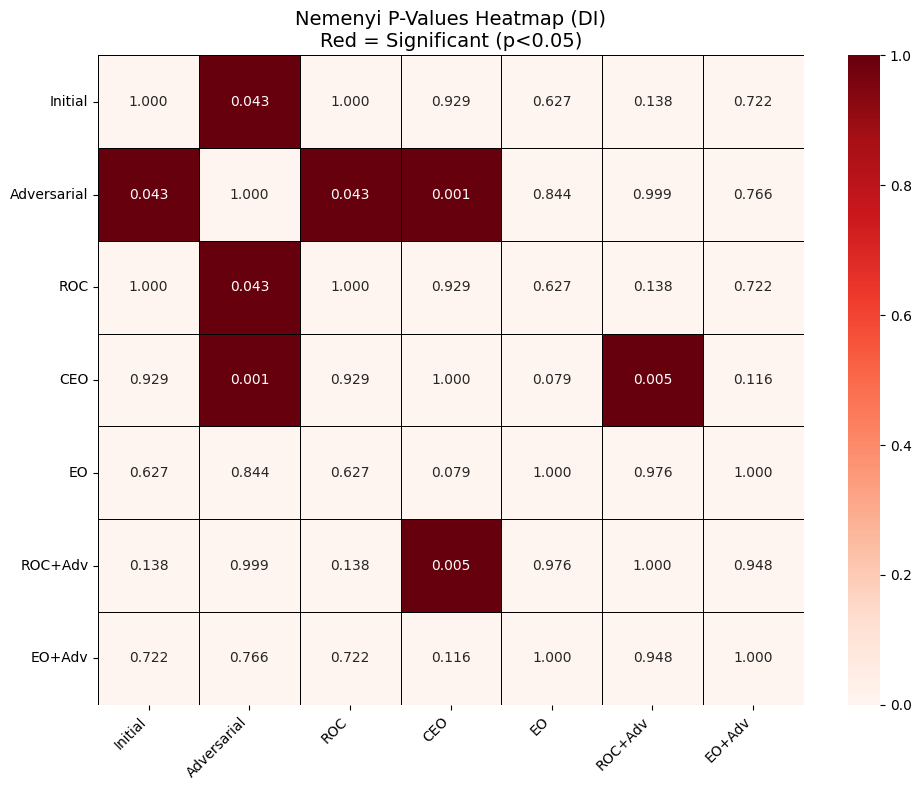


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(25.46181818181819), pvalue=np.float64(0.0002803512001688173))


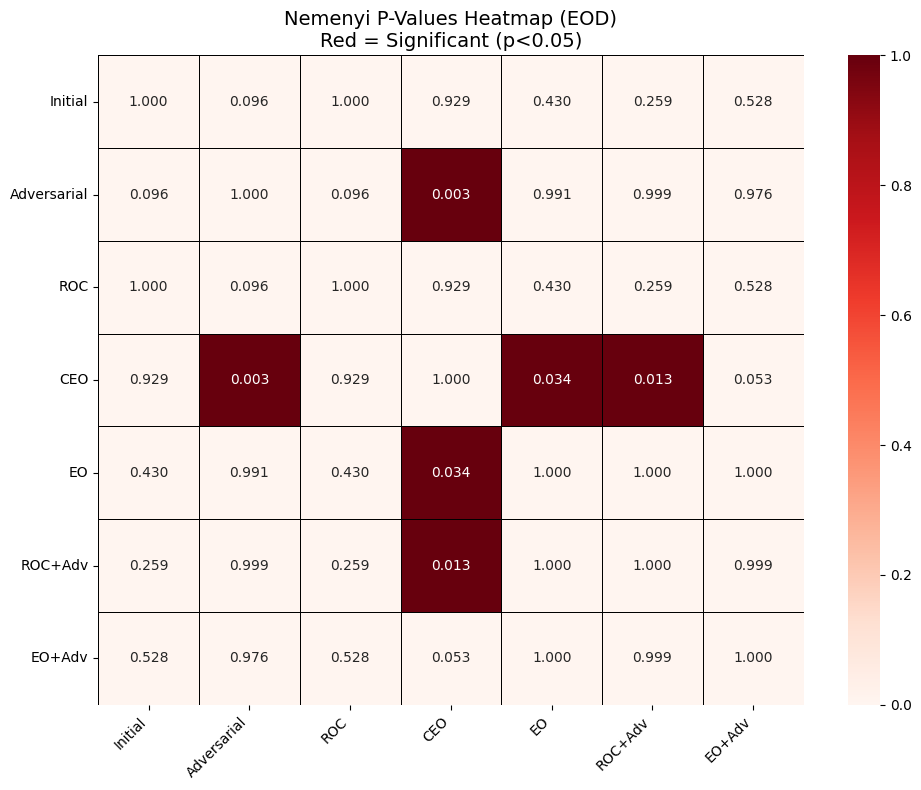


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(26.683636363636364), pvalue=np.float64(0.00016596126037480535))


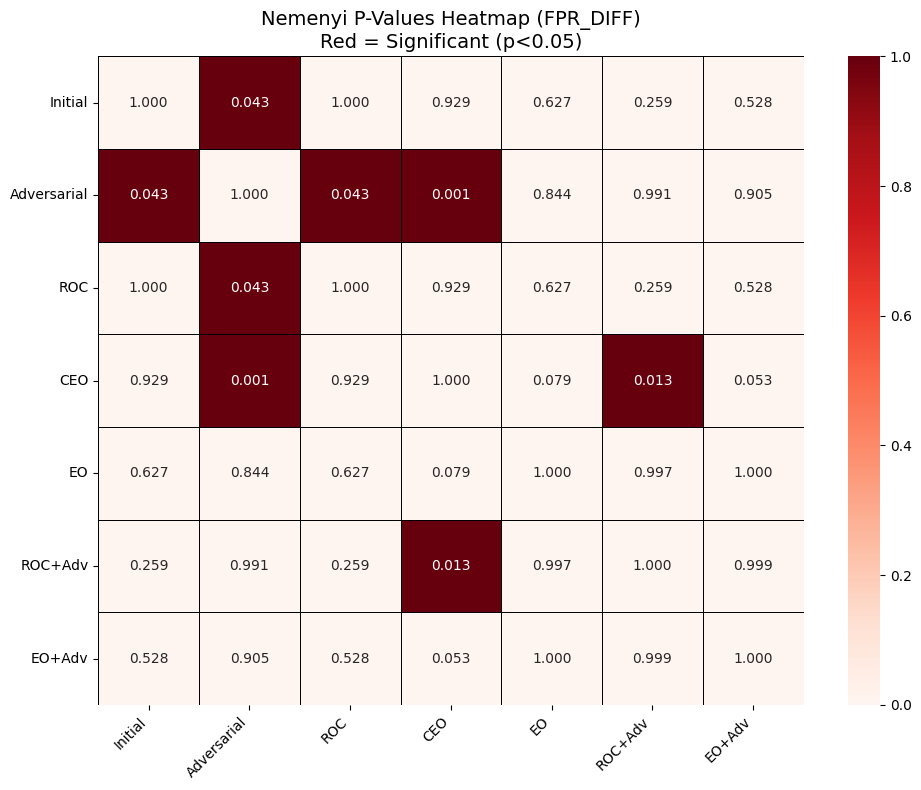

In [ ]:
res_rfc_race = run_fairness_pipeline("rfc", X, y, "race_African-American")

In [ ]:
res_rfc_race

{'Initial': {'accuracy': [0.6985446985446986,
   0.6666666666666666,
   0.6458766458766458,
   0.659043659043659,
   0.673370319001387],
  'di': [np.float64(0.4075731121780881),
   np.float64(0.4411107600649936),
   np.float64(0.5479960128885695),
   np.float64(0.40965002601831246),
   np.float64(0.44226136764878965)],
  'eod': [np.float64(-0.33813979300742875),
   np.float64(-0.3420134852359916),
   np.float64(-0.2073536600561685),
   np.float64(-0.38375620518477666),
   np.float64(-0.2435343757756267)],
  'fpr_diff': [np.float64(-0.22020460358056265),
   np.float64(-0.18720158304608706),
   np.float64(-0.19257281491085068),
   np.float64(-0.17900265170043508),
   np.float64(-0.20629993152248344)]},
 'Adversarial': {'accuracy': [0.6860706860706861,
   0.6528066528066528,
   0.6465696465696466,
   0.6521136521136521,
   0.6699029126213593],
  'di': [np.float64(0.924612651444548),
   np.float64(1.4161278735632186),
   np.float64(1.1811251568078742),
   np.float64(0.9348628025670827),
  

### NN (MLPClassifier)

epoch 0; iter: 0; batch classifier loss: 0.842620; batch adversarial loss: 0.718556
epoch 1; iter: 0; batch classifier loss: 0.615601; batch adversarial loss: 0.755518
epoch 2; iter: 0; batch classifier loss: 0.630778; batch adversarial loss: 0.756696
epoch 3; iter: 0; batch classifier loss: 0.627977; batch adversarial loss: 0.799941
epoch 4; iter: 0; batch classifier loss: 0.655469; batch adversarial loss: 0.765133
epoch 5; iter: 0; batch classifier loss: 0.557409; batch adversarial loss: 0.783818
epoch 6; iter: 0; batch classifier loss: 0.658098; batch adversarial loss: 0.775614
epoch 7; iter: 0; batch classifier loss: 0.620055; batch adversarial loss: 0.730290
epoch 8; iter: 0; batch classifier loss: 0.669596; batch adversarial loss: 0.733597
epoch 9; iter: 0; batch classifier loss: 0.580475; batch adversarial loss: 0.726317
epoch 10; iter: 0; batch classifier loss: 0.646011; batch adversarial loss: 0.714679
epoch 11; iter: 0; batch classifier loss: 0.572194; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.788482; batch adversarial loss: 0.758474
epoch 1; iter: 0; batch classifier loss: 0.692028; batch adversarial loss: 0.739464
epoch 2; iter: 0; batch classifier loss: 0.622746; batch adversarial loss: 0.647754
epoch 3; iter: 0; batch classifier loss: 0.643943; batch adversarial loss: 0.727228
epoch 4; iter: 0; batch classifier loss: 0.692398; batch adversarial loss: 0.732864
epoch 5; iter: 0; batch classifier loss: 0.638551; batch adversarial loss: 0.715996
epoch 6; iter: 0; batch classifier loss: 0.627242; batch adversarial loss: 0.734665
epoch 7; iter: 0; batch classifier loss: 0.592839; batch adversarial loss: 0.718745
epoch 8; iter: 0; batch classifier loss: 0.614931; batch adversarial loss: 0.634664
epoch 9; iter: 0; batch classifier loss: 0.634898; batch adversarial loss: 0.712766
epoch 10; iter: 0; batch classifier loss: 0.641870; batch adversarial loss: 0.691869
epoch 11; iter: 0; batch classifier loss: 0.587215; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.719004; batch adversarial loss: 0.802911
epoch 1; iter: 0; batch classifier loss: 0.711666; batch adversarial loss: 0.774259
epoch 2; iter: 0; batch classifier loss: 0.701730; batch adversarial loss: 0.840292
epoch 3; iter: 0; batch classifier loss: 0.683285; batch adversarial loss: 0.860638
epoch 4; iter: 0; batch classifier loss: 0.698837; batch adversarial loss: 0.808131
epoch 5; iter: 0; batch classifier loss: 0.725476; batch adversarial loss: 0.834052
epoch 6; iter: 0; batch classifier loss: 0.688271; batch adversarial loss: 0.789268
epoch 7; iter: 0; batch classifier loss: 0.607905; batch adversarial loss: 0.784650
epoch 8; iter: 0; batch classifier loss: 0.589977; batch adversarial loss: 0.730435
epoch 9; iter: 0; batch classifier loss: 0.620094; batch adversarial loss: 0.769828
epoch 10; iter: 0; batch classifier loss: 0.599954; batch adversarial loss: 0.765890
epoch 11; iter: 0; batch classifier loss: 0.542865; batch adversarial loss:

...

epoch 0; iter: 0; batch classifier loss: 0.679839; batch adversarial loss: 0.728910
epoch 1; iter: 0; batch classifier loss: 0.642060; batch adversarial loss: 0.694207
epoch 2; iter: 0; batch classifier loss: 0.623439; batch adversarial loss: 0.685129
epoch 3; iter: 0; batch classifier loss: 0.643340; batch adversarial loss: 0.742166
epoch 4; iter: 0; batch classifier loss: 0.662916; batch adversarial loss: 0.700753
epoch 5; iter: 0; batch classifier loss: 0.645413; batch adversarial loss: 0.721762
epoch 6; iter: 0; batch classifier loss: 0.566246; batch adversarial loss: 0.648509
epoch 7; iter: 0; batch classifier loss: 0.607902; batch adversarial loss: 0.706754
epoch 8; iter: 0; batch classifier loss: 0.550618; batch adversarial loss: 0.656766
epoch 9; iter: 0; batch classifier loss: 0.579861; batch adversarial loss: 0.715477
epoch 10; iter: 0; batch classifier loss: 0.636214; batch adversarial loss: 0.720560
epoch 11; iter: 0; batch classifier loss: 0.588887; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")


epoch 0; iter: 0; batch classifier loss: 0.708262; batch adversarial loss: 0.698653
epoch 1; iter: 0; batch classifier loss: 0.630238; batch adversarial loss: 0.746064
epoch 2; iter: 0; batch classifier loss: 0.593600; batch adversarial loss: 0.689643
epoch 3; iter: 0; batch classifier loss: 0.588444; batch adversarial loss: 0.703318
epoch 4; iter: 0; batch classifier loss: 0.554593; batch adversarial loss: 0.720342
epoch 5; iter: 0; batch classifier loss: 0.625790; batch adversarial loss: 0.701357
epoch 6; iter: 0; batch classifier loss: 0.605596; batch adversarial loss: 0.706263
epoch 7; iter: 0; batch classifier loss: 0.669057; batch adversarial loss: 0.701915
epoch 8; iter: 0; batch classifier loss: 0.625302; batch adversarial loss: 0.700686
epoch 9; iter: 0; batch classifier loss: 0.643421; batch adversarial loss: 0.695902
epoch 10; iter: 0; batch classifier loss: 0.617297; batch adversarial loss: 0.730114
epoch 11; iter: 0; batch classifier loss: 0.616297; batch adversarial loss:

/usr/local/lib/python3.12/dist-packages/aif360/algorithms/postprocessing/reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



--- Mean Metrics with 95% Confidence Intervals ---

Initial:
  Accuracy: 0.674 (95% CI: 0.664-0.685)
  DI:       0.460 (95% CI: 0.443-0.485)
  EOD:      -0.291 (95% CI: -0.322--0.258)
  FPR Diff: -0.183 (95% CI: -0.204--0.155)

Adversarial:
  Accuracy: 0.660 (95% CI: 0.651-0.673)
  DI:       1.080 (95% CI: 0.964-1.200)
  EOD:      0.051 (95% CI: -0.010-0.101)
  FPR Diff: 0.074 (95% CI: 0.034-0.108)

ROC:
  Accuracy: 0.674 (95% CI: 0.664-0.685)
  DI:       0.460 (95% CI: 0.442-0.486)
  EOD:      -0.291 (95% CI: -0.323--0.258)
  FPR Diff: -0.183 (95% CI: -0.206--0.156)

CEO:
  Accuracy: 0.665 (95% CI: 0.653-0.679)
  DI:       0.361 (95% CI: 0.291-0.409)
  EOD:      -0.370 (95% CI: -0.407--0.341)
  FPR Diff: -0.235 (95% CI: -0.262--0.217)

EO:
  Accuracy: 0.631 (95% CI: 0.619-0.642)
  DI:       0.911 (95% CI: 0.898-0.924)
  EOD:      -0.010 (95% CI: -0.026-0.010)
  FPR Diff: 0.008 (95% CI: -0.009-0.021)

ROC+Adv:
  Accuracy: 0.660 (95% CI: 0.647-0.676)
  DI:       0.955 (95% CI: 0.930-0.

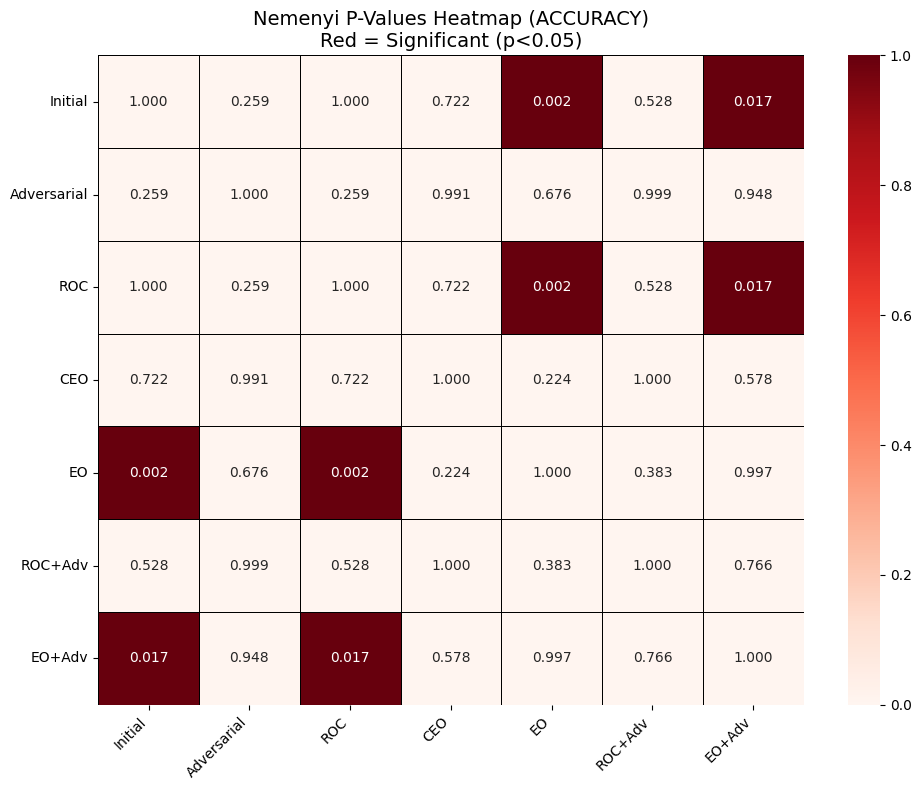


Friedman Test (DI): FriedmanchisquareResult(statistic=np.float64(29.127272727272732), pvalue=np.float64(5.755386316475225e-05))


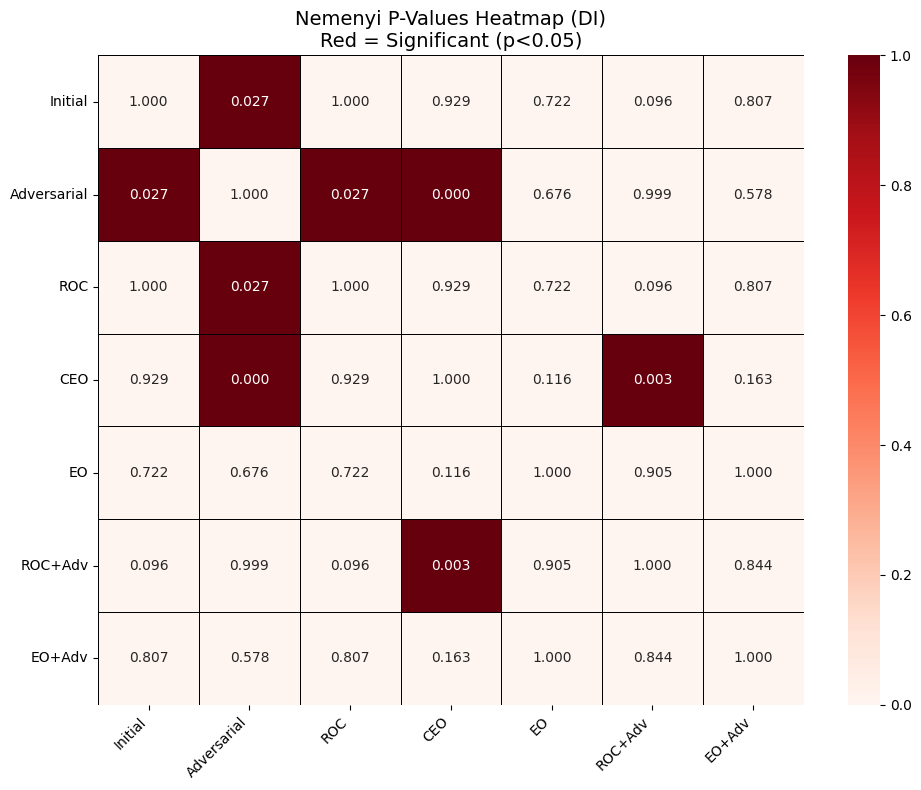


Friedman Test (EOD): FriedmanchisquareResult(statistic=np.float64(26.072727272727278), pvalue=np.float64(0.0002158028528469841))


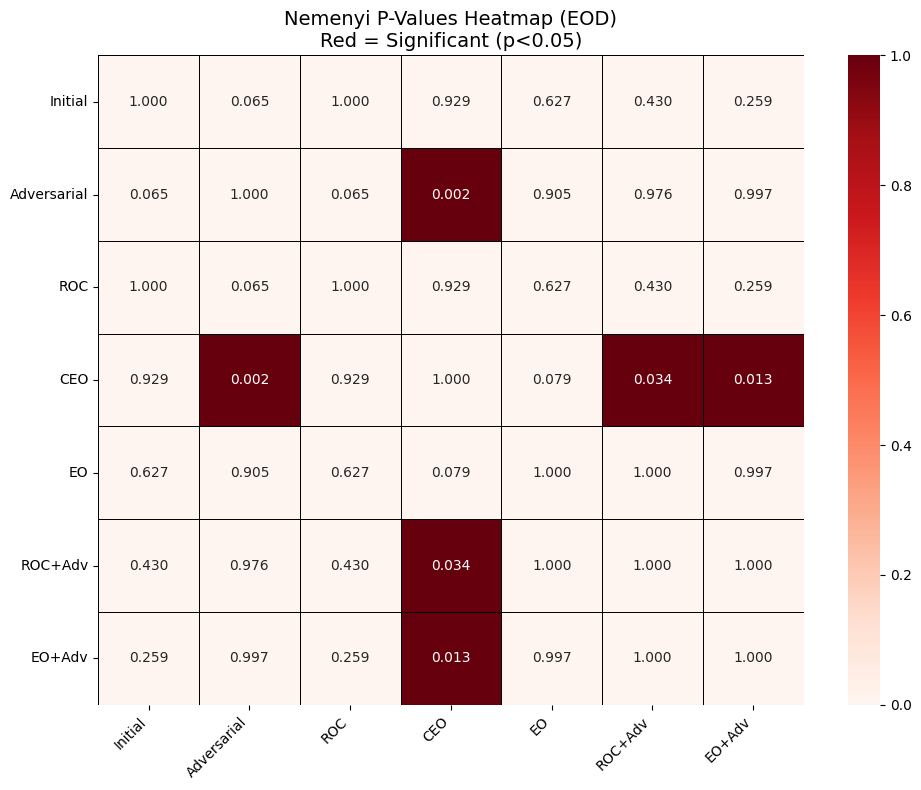


Friedman Test (FPR_DIFF): FriedmanchisquareResult(statistic=np.float64(28.079999999999995), pvalue=np.float64(9.075840686453154e-05))


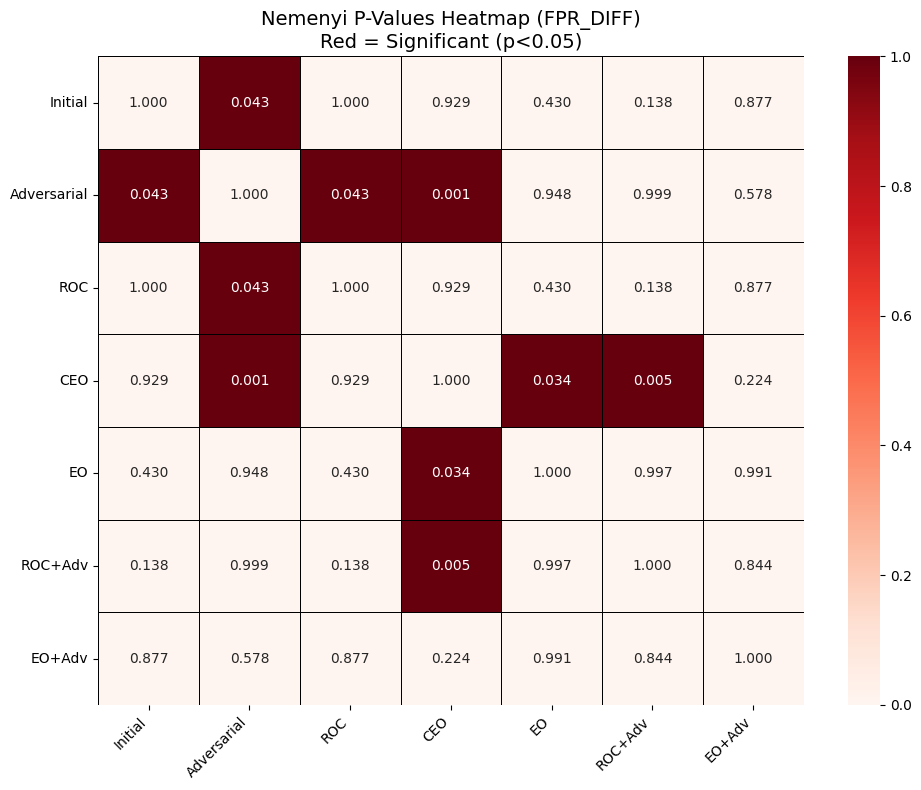

In [ ]:
res_nn_race = run_fairness_pipeline("nn", X, y, "race_African-American")

In [ ]:
res_nn_race

{'Initial': {'accuracy': [0.6943866943866944,
   0.6784476784476784,
   0.659043659043659,
   0.6611226611226612,
   0.6775312066574203],
  'di': [np.float64(0.4316756910800798),
   np.float64(0.44914261619190404),
   np.float64(0.5059997757093193),
   np.float64(0.4553734061930783),
   np.float64(0.4594313893973923)],
  'eod': [np.float64(-0.2953879406867947),
   np.float64(-0.3168255444470279),
   np.float64(-0.25651544632844175),
   np.float64(-0.3441119691119691),
   np.float64(-0.24000992802184168)],
  'fpr_diff': [np.float64(-0.1895843989769821),
   np.float64(-0.1770585982382229),
   np.float64(-0.20082666906280885),
   np.float64(-0.13298406405272506),
   np.float64(-0.213884631688786)]},
 'Adversarial': {'accuracy': [0.6853776853776854,
   0.6528066528066528,
   0.6465696465696466,
   0.6534996534996536,
   0.6636615811373093],
  'di': [np.float64(0.9292119879657487),
   np.float64(1.280560899807607),
   np.float64(1.1897330444681087),
   np.float64(0.940527726242012),
   np.f